# **Explainable and Imbalance-Aware Fine-Grained Bangla Hate Speech Type Classification Using Machine Learning**

### **Phase 3: Data Transformation, Feature Engineering, and Exploratory Data Analysis**





# **1. Module Import and Environment Setup**

In [1]:
# Install the libraries required for loading, preprocessing, EDA, feature engineering, and artifact export
%pip install -q pandas numpy matplotlib seaborn scikit-learn scipy wordcloud fsspec huggingface_hub datasets joblib pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import all required libraries for reproducible data transformation and exploratory analysis
import os
import re
import html
import json
import math
import random
import hashlib
import platform
import warnings
import unicodedata
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from scipy import sparse
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy
from wordcloud import WordCloud

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics.pairwise import cosine_similarity
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)
print('Libraries imported successfully.')

Libraries imported successfully.


In [3]:
# Configure plotting defaults and select a Bengali-capable font when one is available
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 110

available_fonts = {font.name for font in __import__('matplotlib').font_manager.fontManager.ttflist}
font_candidates = ['Noto Sans Bengali', 'Noto Serif Bengali', 'SolaimanLipi', 'Kalpurush', 'DejaVu Sans']
selected_font = next((font for font in font_candidates if font in available_fonts), 'DejaVu Sans')
plt.rcParams['font.family'] = selected_font
print('Matplotlib font:', selected_font)

Matplotlib font: Kalpurush


In [4]:
# Fix random seeds, define project constants, and create reproducible output directories
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

PROJECT_TITLE = 'Explainable and Imbalance-Aware Fine-Grained Bangla Hate Speech Type Classification Using Machine Learning'
DATASET_REPOSITORY = 'aridhasan/BanglaMultiHate'
SPLIT_FILES = {'train': 'data/train.json', 'dev': 'data/dev.json', 'test': 'data/test.json'}
EXPECTED_COLUMNS = [
    'id', 'comment', 'category', 'subcategory',
    'type_of_hate', 'severity_of_hate', 'target_of_hate'
]
TARGET_COL = 'type_of_hate'
TEXT_COL = 'comment'
SPLIT_COL = 'split'

CLASS_ORDER = ['None', 'Abusive', 'Sexism', 'Religious Hate', 'Political Hate', 'Profane']
MISSING_TEXT_TOKENS = {'', 'nan', 'none', 'null', 'n/a', 'na', 'missing', '-'}

OUTPUT_DIR = Path('phase3_outputs')
CLEAN_DATA_DIR = OUTPUT_DIR / 'cleaned_data'
ARTIFACT_DIR = OUTPUT_DIR / 'artifacts'
FEATURE_DIR = OUTPUT_DIR / 'feature_matrices'
REPORT_DIR = OUTPUT_DIR / 'reports'
for directory in [OUTPUT_DIR, CLEAN_DATA_DIR, ARTIFACT_DIR, FEATURE_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Keep this False for the actual submission. It exists only so the notebook can be tested without internet access.
USE_SYNTHETIC_DATA_FOR_OFFLINE_TEST = False
BUILD_FULL_SPARSE_FEATURES = True
DISPLAY_RAW_TEXT_SAMPLES = False

print('Random seed:', SEED)
print('Output directory:', OUTPUT_DIR.resolve())

Random seed: 42
Output directory: F:\CSE437 Project\Notebook\phase3_outputs


# **2. Dataset Loading and Schema Validation**

In [5]:
# Define robust dataset-loading functions that use the requested pandas Hugging Face path first

def make_synthetic_split(split_name, rows_per_class=18):
    """Create a schema-compatible miniature dataset only for offline notebook testing."""
    categories = ['National', 'Politics', 'Religion', 'Sports', 'Entertainment', 'Technology']
    severities = ['Little to None', 'Mild', 'Severe']
    targets = ['None', 'Individual', 'Community', 'Organization', 'Society']
    class_phrases = {
        'None': ['এটি একটি সাধারণ মন্তব্য', 'খবরটি ভালোভাবে উপস্থাপন করা হয়েছে'],
        'Abusive': ['তুমি খুব খারাপ মানুষ', 'এদের আচরণ একদম বাজে'],
        'Sexism': ['নারীদের নিয়ে অপমানজনক মন্তব্য', 'মেয়েদের ছোট করা ঠিক নয়'],
        'Religious Hate': ['ধর্ম নিয়ে বিদ্বেষপূর্ণ কথা', 'ধর্মীয় গোষ্ঠীকে অপমান করা হয়েছে'],
        'Political Hate': ['রাজনৈতিক দল নিয়ে আক্রমণাত্মক মন্তব্য', 'নেতাকে ঘৃণামূলক ভাষায় আক্রমণ'],
        'Profane': ['অশালীন গালি লেখা হয়েছে', 'খুবই বাজে ভাষা ব্যবহার করা হয়েছে']
    }
    rows = []
    offset = {'train': 0, 'dev': 10000, 'test': 20000}[split_name]
    for class_idx, label in enumerate(CLASS_ORDER):
        for i in range(rows_per_class):
            phrase = class_phrases[label][i % len(class_phrases[label])]
            extras = ['!!!', 'http://example.com', '@user', '#বাংলা', '123', '']
            rows.append({
                'id': str(offset + class_idx * rows_per_class + i),
                'comment': f'{phrase} {extras[i % len(extras)]} নমুনা {i}',
                'category': categories[(class_idx + i) % len(categories)],
                'subcategory': f'উপবিভাগ_{(class_idx + i) % 12}',
                'type_of_hate': label,
                'severity_of_hate': severities[(class_idx + i) % len(severities)],
                'target_of_hate': targets[(class_idx + i) % len(targets)]
            })
    return pd.DataFrame(rows)


def load_huggingface_split(split_name):
    """Load one split with pandas; fall back to the datasets library if required."""
    if USE_SYNTHETIC_DATA_FOR_OFFLINE_TEST:
        return make_synthetic_split(split_name)

    hf_path = 'hf://datasets/' + DATASET_REPOSITORY + '/' + SPLIT_FILES[split_name]
    try:
        return pd.read_json(hf_path)
    except Exception as pandas_error:
        print(f'Pandas loading failed for {split_name}: {type(pandas_error).__name__}')
        try:
            from datasets import load_dataset
            return load_dataset(DATASET_REPOSITORY, split=split_name).to_pandas()
        except Exception as datasets_error:
            raise RuntimeError(
                f'Unable to load the {split_name} split. Check internet access and installed Hugging Face packages.'
            ) from datasets_error

In [6]:
# Load the official train, development, and test splits into separate pandas DataFrames
raw_splits = {split_name: load_huggingface_split(split_name) for split_name in SPLIT_FILES}

for split_name, split_df in raw_splits.items():
    print(f'{split_name:>5}: {split_df.shape[0]:,} rows x {split_df.shape[1]} columns')

train: 35,522 rows x 7 columns
  dev: 5,024 rows x 7 columns
 test: 10,200 rows x 7 columns


In [7]:
# Validate required columns, add split identifiers, and preserve an untouched raw copy
for split_name, split_df in raw_splits.items():
    missing_columns = sorted(set(EXPECTED_COLUMNS) - set(split_df.columns))
    if missing_columns:
        raise ValueError(f'{split_name} is missing required columns: {missing_columns}')
    raw_splits[split_name] = split_df[EXPECTED_COLUMNS].copy()
    raw_splits[split_name][SPLIT_COL] = split_name

raw_all_df = pd.concat(raw_splits.values(), ignore_index=True)
raw_all_df_backup = raw_all_df.copy(deep=True)

print('Combined raw shape:', raw_all_df.shape)
print('Columns:', raw_all_df.columns.tolist())

Combined raw shape: (50746, 8)
Columns: ['id', 'comment', 'category', 'subcategory', 'type_of_hate', 'severity_of_hate', 'target_of_hate', 'split']


In [8]:
# Record dataset fingerprints so later runs can verify that the same data version was used

def dataframe_fingerprint(dataframe, columns):
    stable = dataframe[columns].fillna('<MISSING>').astype(str)
    hashed = pd.util.hash_pandas_object(stable, index=False).values.tobytes()
    return hashlib.sha256(hashed).hexdigest()

fingerprint_records = []
for split_name, split_df in raw_splits.items():
    fingerprint_records.append({
        'split': split_name,
        'rows': int(len(split_df)),
        'columns': int(split_df.shape[1]),
        'fingerprint_sha256': dataframe_fingerprint(split_df, EXPECTED_COLUMNS)
    })

fingerprint_df = pd.DataFrame(fingerprint_records)
display(fingerprint_df)

,split,rows,columns,fingerprint_sha256
0,train,35522,8,2ee0fe4267baf3c85ce6a5fcabc64cf08fba6de1ccbf9c614b932ec13ba0a0c6
1,dev,5024,8,c06ab475c01258c350416da85a1409fc7d816f3620f38cbb3b957ece0c8d21f6
2,test,10200,8,95136b5a298f9c46e6b35b1f9db55a2d9ff60a31dfdbdb411bdbd0050f90494d


In [9]:
# Display a privacy-conscious structural preview of the dataset without exposing raw comments by default
preview_columns = ['id', 'category', 'subcategory', 'type_of_hate', 'severity_of_hate', 'target_of_hate', 'split']
display(raw_all_df[preview_columns].head(10))

if DISPLAY_RAW_TEXT_SAMPLES:
    display(raw_all_df[[TEXT_COL, TARGET_COL, SPLIT_COL]].sample(min(10, len(raw_all_df)), random_state=SEED))

,id,category,subcategory,type_of_hate,severity_of_hate,target_of_hate,split
0,147963,National,বাংলার সময়,None,Little to None,None,train
1,214275,Politics,রাজনীতি (Politics),None,Little to None,None,train
2,849172,Miscellaneous,Youtube Shorts,Abusive,Little to None,Individual,train
3,821985,International,Somoy International News,None,Little to None,None,train
4,477288,National,বাংলার সময়,Abusive,Severe,Individual,train
5,933728,Sports,Somoy Sports(Cricket),None,Little to None,None,train
6,398351,International,আন্তর্জাতিক সময়,None,Little to None,None,train
7,786609,International,Somoy International News,Abusive,Little to None,Society,train
8,917115,Sports,Somoy Sports(Cricket),None,Little to None,None,train
9,415453,International,আন্তর্জাতিক সময়,None,Little to None,None,train


In [10]:
# Inspect data types, memory usage, cardinality, and basic descriptive information
schema_summary = pd.DataFrame({
    'dtype': raw_all_df.dtypes.astype(str),
    'non_null': raw_all_df.notna().sum(),
    'missing': raw_all_df.isna().sum(),
    'unique_values': raw_all_df.nunique(dropna=True),
    'memory_bytes': [raw_all_df[col].memory_usage(deep=True) for col in raw_all_df.columns]
})
schema_summary['memory_mb'] = schema_summary['memory_bytes'] / (1024 ** 2)
display(schema_summary.drop(columns='memory_bytes'))
print(f'Total memory usage: {raw_all_df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB')

,dtype,non_null,missing,unique_values,memory_mb
id,int64,50746,0,50746,0.387287
comment,object,50746,0,50745,20.978556
category,object,50746,0,19,2.827483
subcategory,object,50746,0,120,5.513642
type_of_hate,object,50746,0,6,2.674682
severity_of_hate,object,50746,0,3,2.899914
target_of_hate,object,50746,0,5,2.679975
split,object,50746,0,3,2.594154


Total memory usage: 40.55 MB


# **3. Raw Data Quality Audit**

## **3.1 Missing Values and Missing-Like Strings**

,id,comment,category,subcategory,type_of_hate,severity_of_hate,target_of_hate
split,,,,,,,
dev,0,0,0,0,0,0,0
test,0,0,0,0,0,0,0
train,0,0,0,0,0,0,0


,missing_percent
id,0.0
comment,0.0
category,0.0
subcategory,0.0
type_of_hate,0.0
severity_of_hate,0.0
target_of_hate,0.0


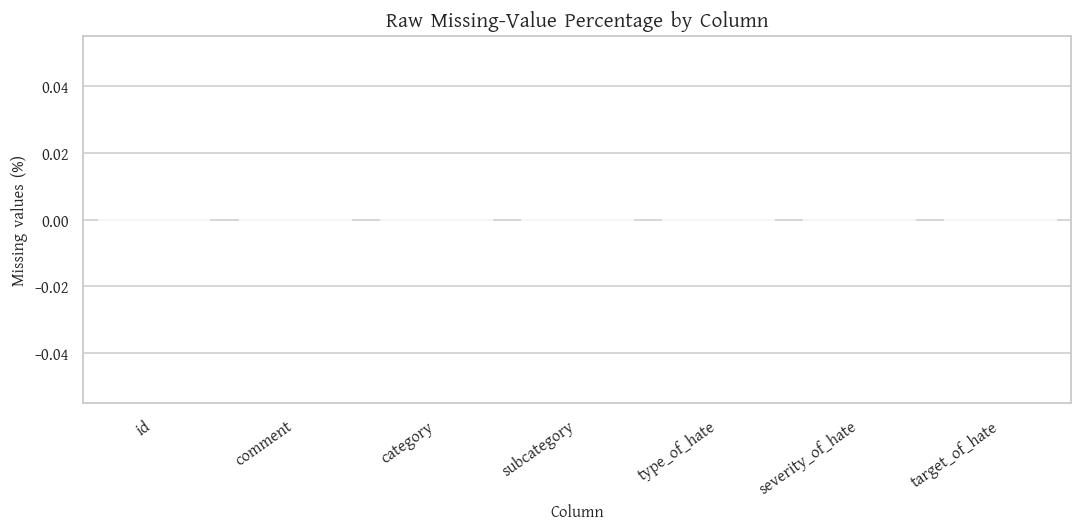

In [11]:
# Summarize true missing values by column and split
missing_by_split = raw_all_df.groupby(SPLIT_COL)[EXPECTED_COLUMNS].apply(lambda frame: frame.isna().sum())
display(missing_by_split)

missing_percent = raw_all_df[EXPECTED_COLUMNS].isna().mean().mul(100).sort_values(ascending=False)
display(missing_percent.rename('missing_percent').to_frame())

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_percent.index, y=missing_percent.values, color=sns.color_palette()[0])
plt.title('Raw Missing-Value Percentage by Column')
plt.xlabel('Column')
plt.ylabel('Missing values (%)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

In [12]:
# Detect blank strings and common text tokens that semantically represent missing values
missing_like_records = []
for column in EXPECTED_COLUMNS:
    normalized = raw_all_df[column].astype('string').str.strip().str.lower()
    missing_like_count = normalized.isin(MISSING_TEXT_TOKENS).sum()
    blank_count = normalized.eq('').sum()
    missing_like_records.append({
        'column': column,
        'blank_strings': int(blank_count),
        'missing_like_tokens': int(missing_like_count)
    })
missing_like_df = pd.DataFrame(missing_like_records)
display(missing_like_df)

,column,blank_strings,missing_like_tokens
0,id,0,0
1,comment,0,0
2,category,0,0
3,subcategory,0,0
4,type_of_hate,0,28603
5,severity_of_hate,0,0
6,target_of_hate,0,30347


## **3.2 Duplicate, Identifier, and Split-Leakage Checks**

In [13]:
# Count exact duplicate rows, duplicate IDs, and duplicate comments inside each official split
quality_records = []
for split_name, split_df in raw_splits.items():
    quality_records.append({
        'split': split_name,
        'rows': len(split_df),
        'exact_duplicate_rows': int(split_df.duplicated().sum()),
        'duplicate_ids': int(split_df['id'].astype(str).duplicated().sum()),
        'duplicate_comments': int(split_df[TEXT_COL].astype(str).duplicated().sum()),
        'duplicate_comment_label_pairs': int(split_df.duplicated(subset=[TEXT_COL, TARGET_COL]).sum())
    })
raw_duplicate_summary = pd.DataFrame(quality_records)
display(raw_duplicate_summary)

,split,rows,exact_duplicate_rows,duplicate_ids,duplicate_comments,duplicate_comment_label_pairs
0,train,35522,0,0,0,0
1,dev,5024,0,0,0,0
2,test,10200,0,0,0,0


In [14]:
# Create a lightweight comparison key for duplicate and leakage analysis without performing final cleaning

def preliminary_text_key(text):
    text = html.unescape(str(text))
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' URLTOKEN ', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

raw_all_df['_preliminary_text_key'] = raw_all_df[TEXT_COL].map(preliminary_text_key)

split_key_sets = {
    split_name: set(raw_all_df.loc[raw_all_df[SPLIT_COL] == split_name, '_preliminary_text_key'])
    for split_name in SPLIT_FILES
}

overlap_records = []
for left, right in [('train', 'dev'), ('train', 'test'), ('dev', 'test')]:
    overlap = split_key_sets[left] & split_key_sets[right]
    overlap_records.append({
        'split_pair': f'{left} vs {right}',
        'overlapping_normalized_comments': len(overlap),
        'left_unique_comments': len(split_key_sets[left]),
        'right_unique_comments': len(split_key_sets[right])
    })
raw_overlap_df = pd.DataFrame(overlap_records)
display(raw_overlap_df)

,split_pair,overlapping_normalized_comments,left_unique_comments,right_unique_comments
0,train vs dev,2,35520,5024
1,train vs test,0,35520,10200
2,dev vs test,0,5024,10200


In [15]:
# Identify normalized comments associated with conflicting hate-type labels
label_counts_per_text = raw_all_df.groupby('_preliminary_text_key')[TARGET_COL].nunique(dropna=True)
conflicting_keys = label_counts_per_text[label_counts_per_text > 1].index
conflicting_label_rows = raw_all_df[raw_all_df['_preliminary_text_key'].isin(conflicting_keys)]

print('Normalized comments with multiple hate-type labels:', len(conflicting_keys))
if len(conflicting_keys) > 0:
    conflict_summary = (
        conflicting_label_rows.groupby('_preliminary_text_key')[TARGET_COL]
        .agg(lambda values: sorted(set(values.dropna().astype(str))))
        .reset_index(name='observed_labels')
    )
    display(conflict_summary.head(20))

Normalized comments with multiple hate-type labels: 0


In [16]:
# Check invalid Unicode replacement characters, control characters, and empty text records

def count_control_characters(text):
    return sum(unicodedata.category(char).startswith('C') and char not in '\n\t\r' for char in str(text))

unicode_quality_df = pd.DataFrame({
    'contains_replacement_character': raw_all_df[TEXT_COL].astype(str).str.contains('\ufffd', regex=False),
    'control_character_count': raw_all_df[TEXT_COL].map(count_control_characters),
    'is_blank_after_strip': raw_all_df[TEXT_COL].astype('string').str.strip().eq('')
})

display(unicode_quality_df.agg(['sum', 'mean']).T)

,sum,mean
contains_replacement_character,0.0,0.0
control_character_count,0.0,0.0
is_blank_after_strip,0.0,0.0


# **4. Raw Exploratory Data Analysis**

## **4.1 Split Size, Class Distribution, and Imbalance**

,rows
split,
train,35522
dev,5024
test,10200


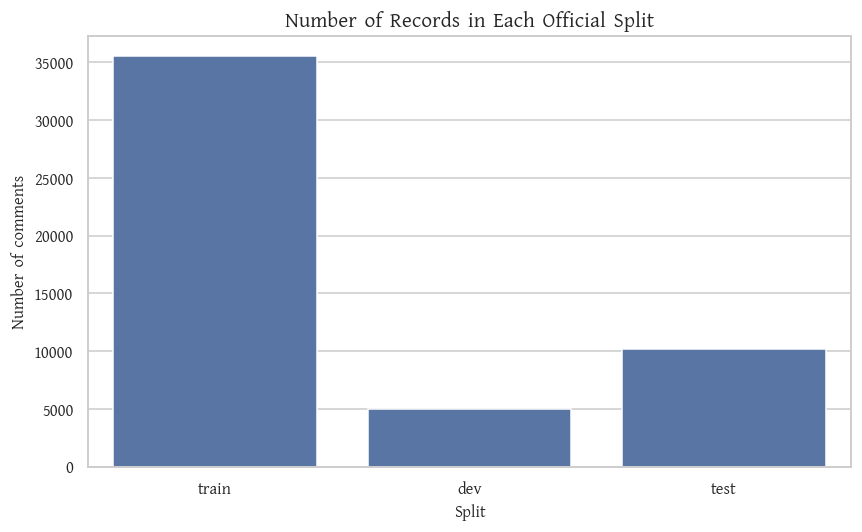

In [17]:
# Compare the number of rows available in the train, development, and test splits
split_sizes = raw_all_df[SPLIT_COL].value_counts().reindex(['train', 'dev', 'test'])
display(split_sizes.rename('rows').to_frame())

plt.figure(figsize=(8, 5))
sns.barplot(x=split_sizes.index, y=split_sizes.values, color=sns.color_palette()[0])
plt.title('Number of Records in Each Official Split')
plt.xlabel('Split')
plt.ylabel('Number of comments')
plt.tight_layout()
plt.show()

In [18]:
# Calculate class counts, percentages, imbalance ratios, entropy, and effective class counts
class_distribution_tables = {}
imbalance_metrics = []

for split_name in ['train', 'dev', 'test']:
    split_labels = raw_all_df.loc[raw_all_df[SPLIT_COL] == split_name, TARGET_COL]
    counts = split_labels.value_counts().reindex(CLASS_ORDER, fill_value=0)
    percentages = counts.div(counts.sum()).mul(100)
    class_distribution_tables[split_name] = pd.DataFrame({'count': counts, 'percentage': percentages})

    nonzero_counts = counts[counts > 0]
    probabilities = counts / counts.sum()
    imbalance_metrics.append({
        'split': split_name,
        'majority_class': counts.idxmax(),
        'minority_class': counts.idxmin(),
        'majority_count': int(counts.max()),
        'minority_count': int(counts.min()),
        'imbalance_ratio_max_to_min': float(counts.max() / max(counts.min(), 1)),
        'normalized_entropy': float(entropy(probabilities[probabilities > 0]) / np.log(len(CLASS_ORDER))),
        'effective_number_of_classes': float(np.exp(entropy(probabilities[probabilities > 0])))
    })

for split_name, table in class_distribution_tables.items():
    print(f'\n{split_name.upper()} CLASS DISTRIBUTION')
    display(table)

display(pd.DataFrame(imbalance_metrics))


TRAIN CLASS DISTRIBUTION


,count,percentage
type_of_hate,,
None,19954,56.173639
Abusive,8212,23.118068
Sexism,122,0.343449
Religious Hate,676,1.903046
Political Hate,4227,11.899668
Profane,2331,6.562131



DEV CLASS DISTRIBUTION


,count,percentage
type_of_hate,,
None,2898,57.683121
Abusive,1113,22.153662
Sexism,19,0.378185
Religious Hate,78,1.552548
Political Hate,574,11.425159
Profane,342,6.807325



TEST CLASS DISTRIBUTION


,count,percentage
type_of_hate,,
None,5751,56.382353
Abusive,2312,22.666667
Sexism,29,0.284314
Religious Hate,179,1.754902
Political Hate,1220,11.960784
Profane,709,6.950980


,split,majority_class,minority_class,majority_count,minority_count,imbalance_ratio_max_to_min,normalized_entropy,effective_number_of_classes
0,train,None,Sexism,19954,122,163.557377,0.663856,3.285338
1,dev,None,Sexism,2898,19,152.526316,0.651765,3.214932
2,test,None,Sexism,5751,29,198.310345,0.662173,3.275447


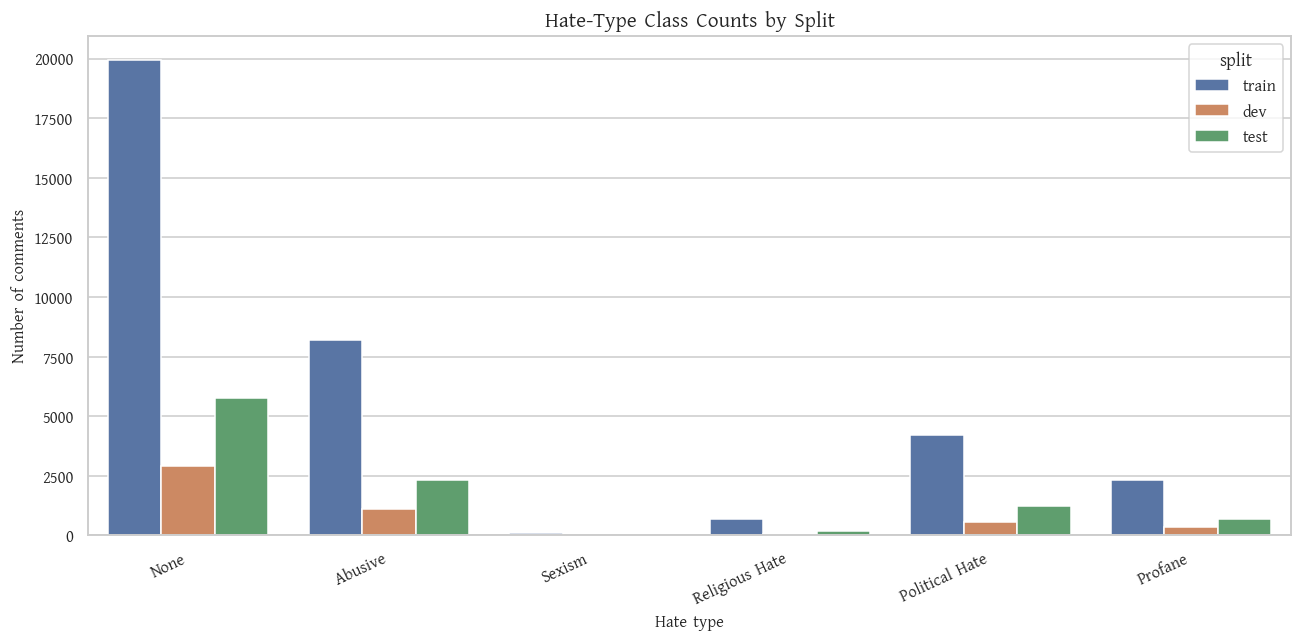

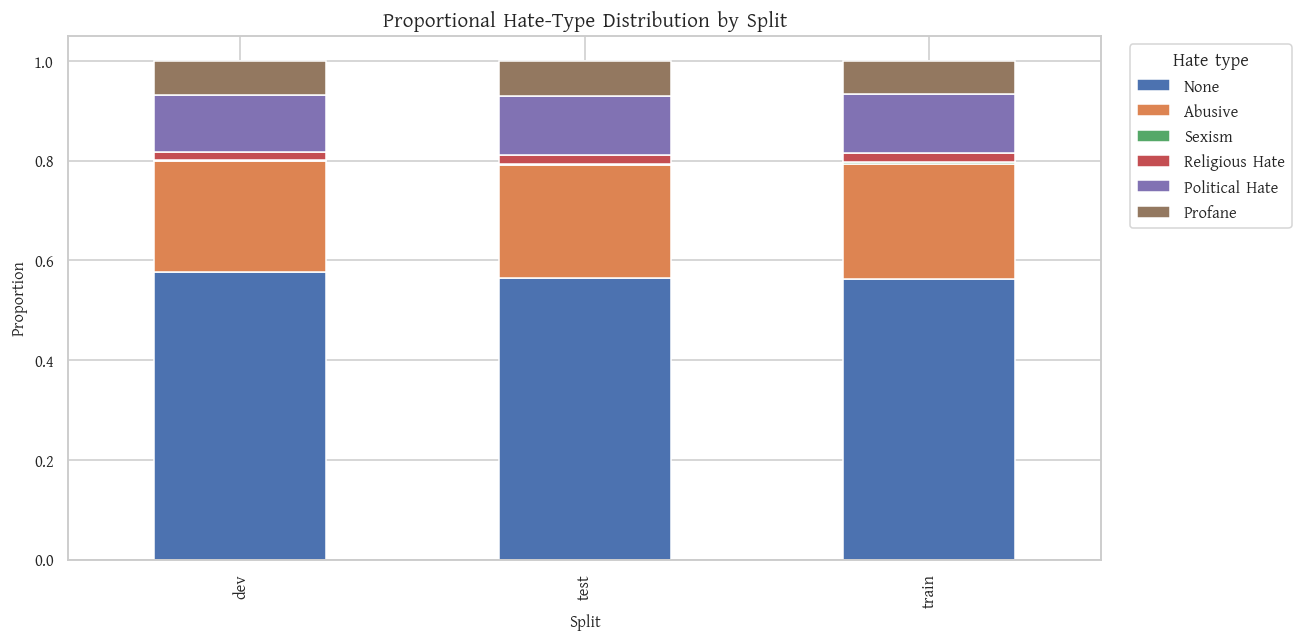

In [19]:
# Visualize absolute and proportional hate-type distributions across all splits
class_count_long = (
    raw_all_df.groupby([SPLIT_COL, TARGET_COL]).size()
    .rename('count').reset_index()
)
class_count_long[TARGET_COL] = pd.Categorical(class_count_long[TARGET_COL], categories=CLASS_ORDER, ordered=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=class_count_long, x=TARGET_COL, y='count', hue=SPLIT_COL, hue_order=['train', 'dev', 'test'])
plt.title('Hate-Type Class Counts by Split')
plt.xlabel('Hate type')
plt.ylabel('Number of comments')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

class_share = pd.crosstab(raw_all_df[SPLIT_COL], raw_all_df[TARGET_COL], normalize='index').reindex(columns=CLASS_ORDER, fill_value=0)
class_share.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Proportional Hate-Type Distribution by Split')
plt.xlabel('Split')
plt.ylabel('Proportion')
plt.legend(title='Hate type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **4.2 Category, Subcategory, Severity, and Target Analysis**

,unique_values,missing_values
category,19,0
subcategory,120,0
severity_of_hate,3,0
target_of_hate,5,0


,count
category,
National,17486
International,10629
Politics,9552
Sports,5650
Miscellaneous,4020
Entertainment,2000
Disaster,526
Religion,300
Opinion,150


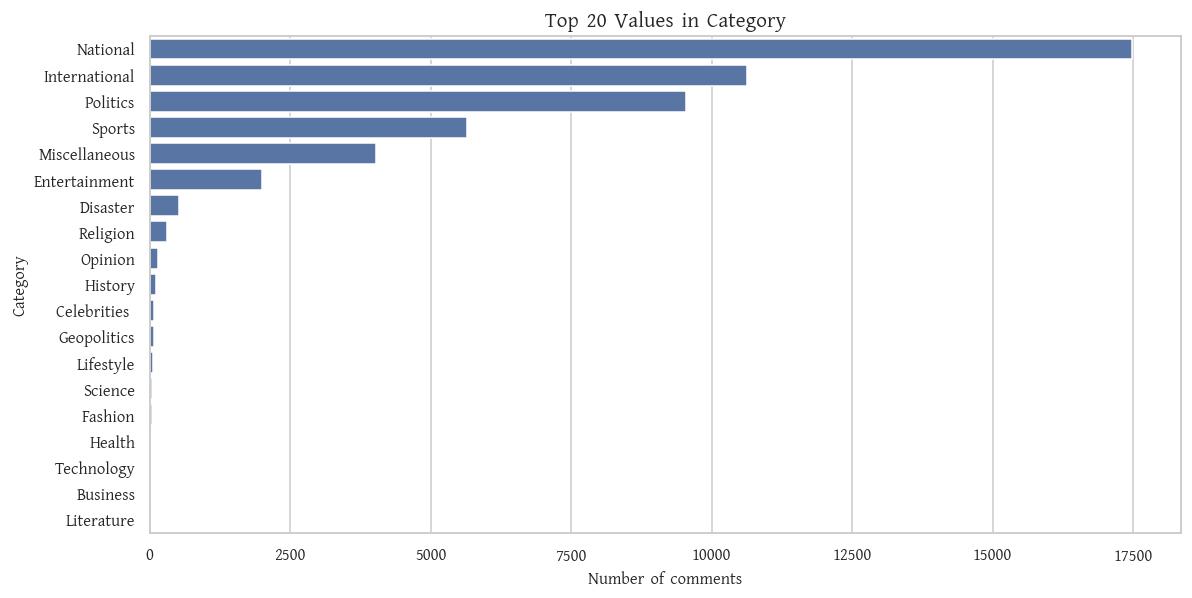

,count
subcategory,
বাংলার সময়,6296
জাতীয় সংবাদ,5893
আন্তর্জাতিক সময়,5727
Somoy International News,4393
রাজনীতি (Politics),4174
বাংলার সময় (Banglar Somoy),3176
Somoy Sports(Cricket),3026
জাতীয় সংসদ,2804
জাতীয় সংসদ নির্বাচন ২০২৪,2032


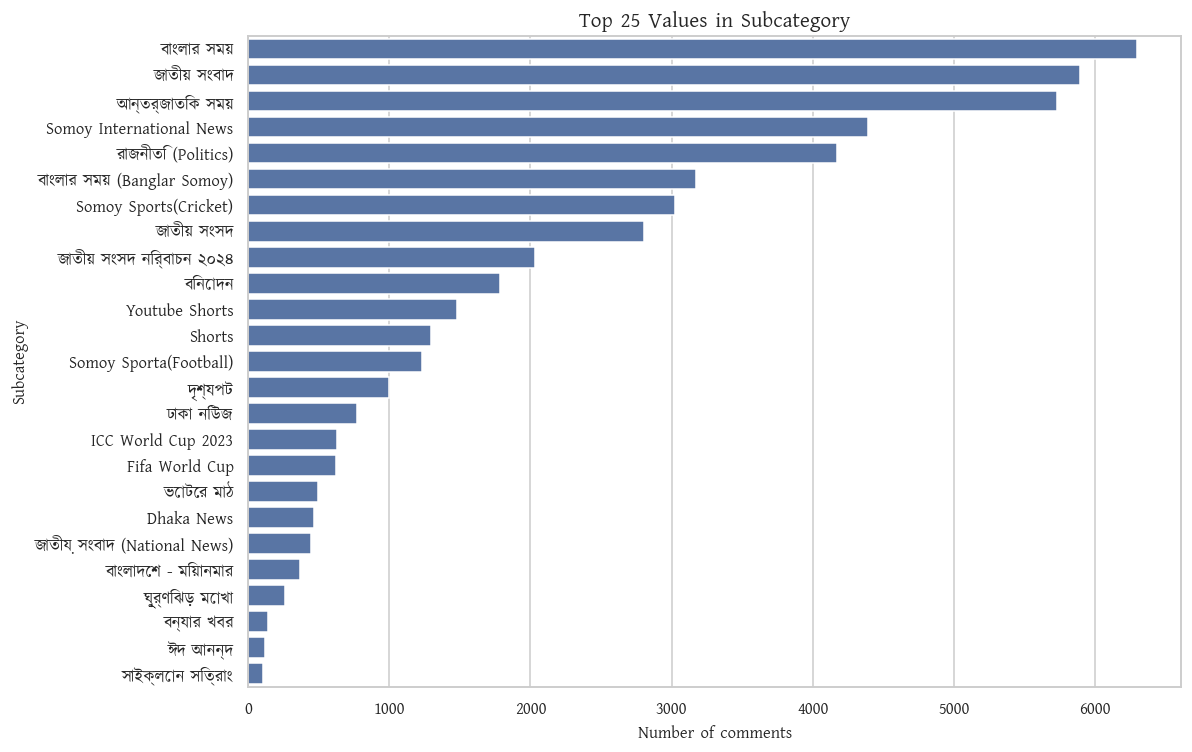

In [20]:
# Summarize metadata cardinality and display the most frequent categories and subcategories
metadata_summary = pd.DataFrame({
    'unique_values': raw_all_df[['category', 'subcategory', 'severity_of_hate', 'target_of_hate']].nunique(),
    'missing_values': raw_all_df[['category', 'subcategory', 'severity_of_hate', 'target_of_hate']].isna().sum()
})
display(metadata_summary)

for column, top_k in [('category', 20), ('subcategory', 25)]:
    counts = raw_all_df[column].value_counts().head(top_k)
    display(counts.rename('count').to_frame())
    plt.figure(figsize=(11, max(5, top_k * 0.28)))
    sns.barplot(x=counts.values, y=counts.index, color=sns.color_palette()[0])
    plt.title(f'Top {top_k} Values in {column.title()}')
    plt.xlabel('Number of comments')
    plt.ylabel(column.title())
    plt.tight_layout()
    plt.show()

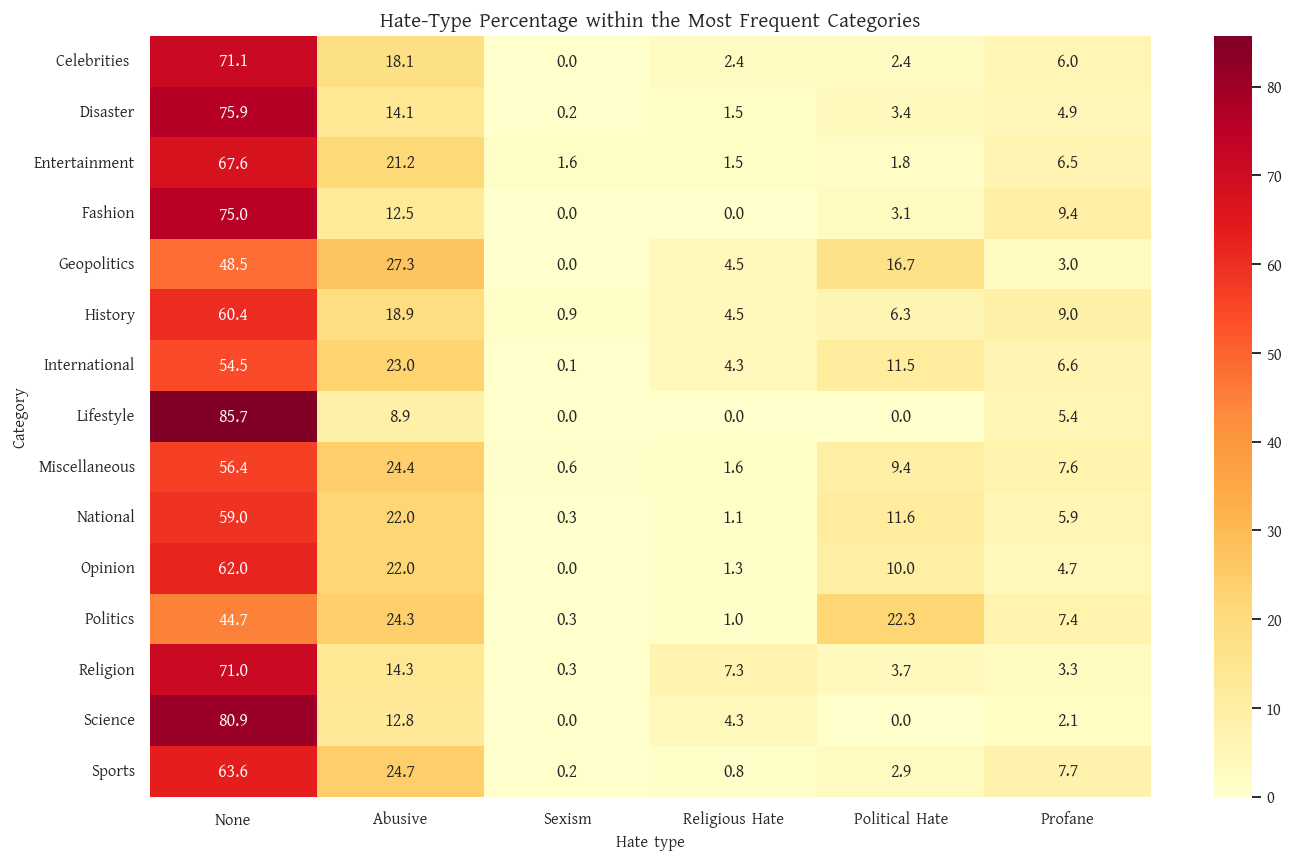

In [21]:
# Plot hate-type composition across the most frequent content categories
TOP_CATEGORY_COUNT = 15
top_categories = raw_all_df['category'].value_counts().head(TOP_CATEGORY_COUNT).index
category_hate_counts = pd.crosstab(
    raw_all_df.loc[raw_all_df['category'].isin(top_categories), 'category'],
    raw_all_df.loc[raw_all_df['category'].isin(top_categories), TARGET_COL]
).reindex(columns=CLASS_ORDER, fill_value=0)

category_hate_percent = category_hate_counts.div(category_hate_counts.sum(axis=1), axis=0).mul(100)

plt.figure(figsize=(13, 8))
sns.heatmap(category_hate_percent, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Hate-Type Percentage within the Most Frequent Categories')
plt.xlabel('Hate type')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

severity_of_hate,Little to None,Mild,Severe
type_of_hate,,,
None,100.00,0.00,0.00
Abusive,27.78,46.82,25.39
Sexism,21.76,45.88,32.35
Religious Hate,20.90,46.09,33.01
Political Hate,22.95,53.66,23.38
Profane,5.71,17.00,77.29


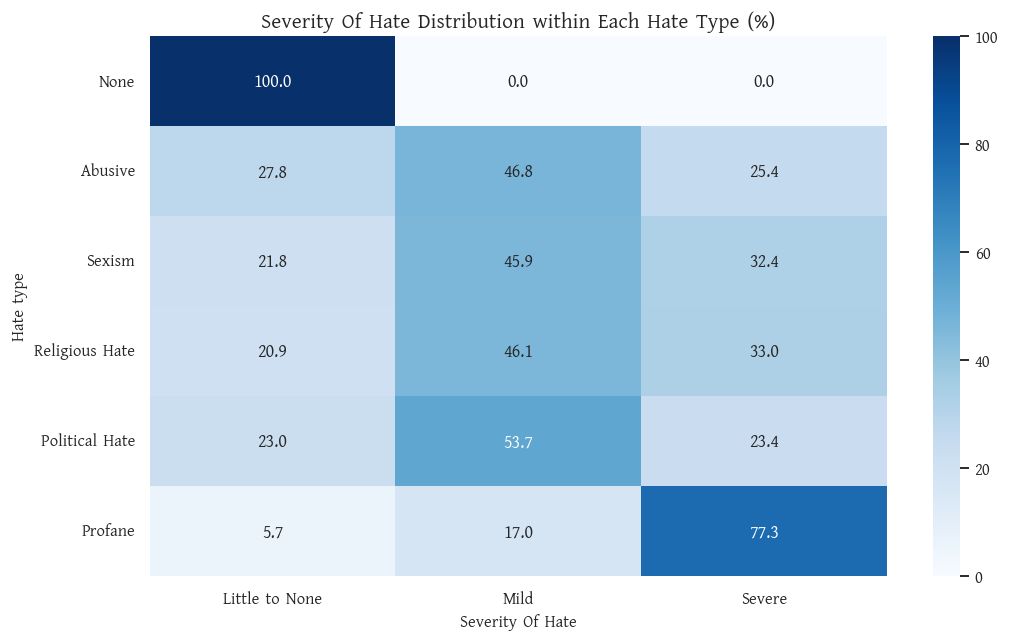

target_of_hate,Community,Individual,None,Organization,Society
type_of_hate,,,,,
None,0.00,0.00,100.00,0.00,0.00
Abusive,18.64,40.03,8.76,19.13,13.45
Sexism,24.12,55.88,6.47,4.12,9.41
Religious Hate,39.98,19.72,11.36,7.72,21.22
Political Hate,9.48,22.06,5.61,44.96,17.89
Profane,17.09,50.47,7.98,16.85,7.60


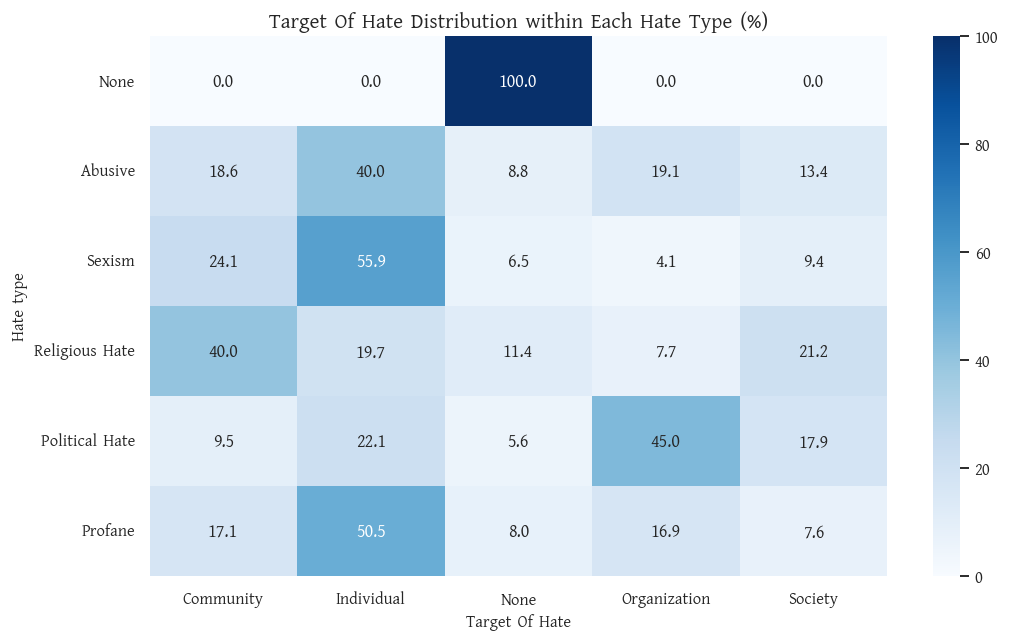

In [22]:
# Examine relationships between hate type, severity, and target using row-normalized heatmaps
for metadata_column in ['severity_of_hate', 'target_of_hate']:
    cross_tab = pd.crosstab(raw_all_df[TARGET_COL], raw_all_df[metadata_column], normalize='index').mul(100)
    cross_tab = cross_tab.reindex(CLASS_ORDER).fillna(0)
    display(cross_tab.round(2))

    plt.figure(figsize=(10, 6))
    sns.heatmap(cross_tab, annot=True, fmt='.1f', cmap='Blues')
    plt.title(f'{metadata_column.replace("_", " ").title()} Distribution within Each Hate Type (%)')
    plt.xlabel(metadata_column.replace('_', ' ').title())
    plt.ylabel('Hate type')
    plt.tight_layout()
    plt.show()

In [23]:
# Measure train-development-test distribution shift with Jensen-Shannon distance

def categorical_js_distance(dataframe, column, reference_split='train'):
    levels = sorted(dataframe[column].fillna('Unknown').astype(str).unique())
    reference = (
        dataframe.loc[dataframe[SPLIT_COL] == reference_split, column]
        .fillna('Unknown').astype(str).value_counts(normalize=True)
        .reindex(levels, fill_value=0).values
    )
    records = []
    for comparison_split in ['dev', 'test']:
        comparison = (
            dataframe.loc[dataframe[SPLIT_COL] == comparison_split, column]
            .fillna('Unknown').astype(str).value_counts(normalize=True)
            .reindex(levels, fill_value=0).values
        )
        records.append({
            'feature': column,
            'comparison': f'{reference_split} vs {comparison_split}',
            'jensen_shannon_distance': float(jensenshannon(reference, comparison, base=2))
        })
    return records

shift_records = []
for column in [TARGET_COL, 'category', 'subcategory', 'severity_of_hate', 'target_of_hate']:
    shift_records.extend(categorical_js_distance(raw_all_df, column))

distribution_shift_df = pd.DataFrame(shift_records)
display(distribution_shift_df.sort_values('jensen_shannon_distance', ascending=False))

,feature,comparison,jensen_shannon_distance
4,subcategory,train vs dev,0.075287
5,subcategory,train vs test,0.058206
2,category,train vs dev,0.037142
3,category,train vs test,0.024468
8,target_of_hate,train vs dev,0.021563
0,type_of_hate,train vs dev,0.018215
6,severity_of_hate,train vs dev,0.017169
1,type_of_hate,train vs test,0.010007
9,target_of_hate,train vs test,0.008106
7,severity_of_hate,train vs test,0.004209


## **4.3 Raw Text Length and Outlier Analysis**

In [24]:
# Derive temporary raw text-length measurements for exploratory analysis
raw_all_df['raw_char_count'] = raw_all_df[TEXT_COL].fillna('').astype(str).str.len()
raw_all_df['raw_whitespace_token_count'] = raw_all_df[TEXT_COL].fillna('').astype(str).str.split().str.len()
raw_all_df['raw_line_count'] = raw_all_df[TEXT_COL].fillna('').astype(str).str.count('\n').add(1)

length_summary = raw_all_df.groupby(SPLIT_COL)[['raw_char_count', 'raw_whitespace_token_count', 'raw_line_count']].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)
display(length_summary)

raw_char_count                                          \
               count       mean median         std min   max   
split                                                          
dev             5024  79.731887   52.0  144.527574   8  3702   
test           10200  78.467451   52.0  122.216854   6  3707   
train          35522  78.213079   51.0  122.840018   7  3710   

      raw_whitespace_token_count                                        \
                           count       mean median        std min  max   
split                                                                    
dev                         5024  14.021099    9.0  24.144440   3  614   
test                       10200  13.791863    9.0  20.606209   3  620   
train                      35522  13.764540    9.0  20.516241   3  629   

      raw_line_count                           
               count mean median  std min max  
split                                          
dev             5024  1.0    1.0  0.0   1   1  
test           10200  1.0    1.0  0.0   1   1  
train          35522  1.0    1.0  0.0   1   1

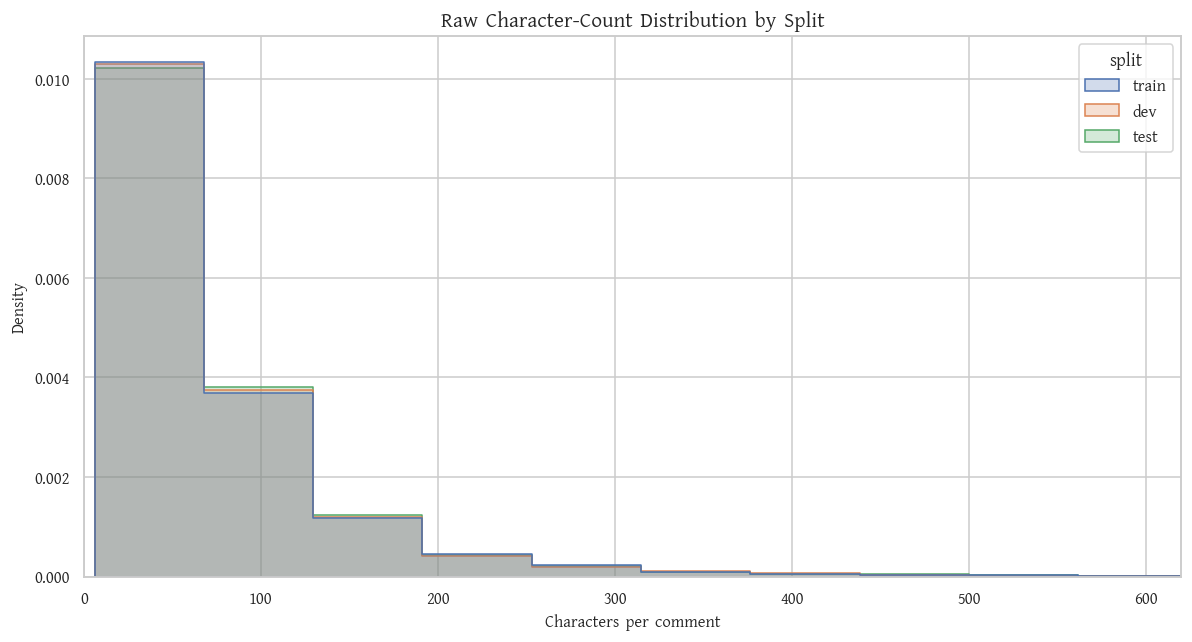

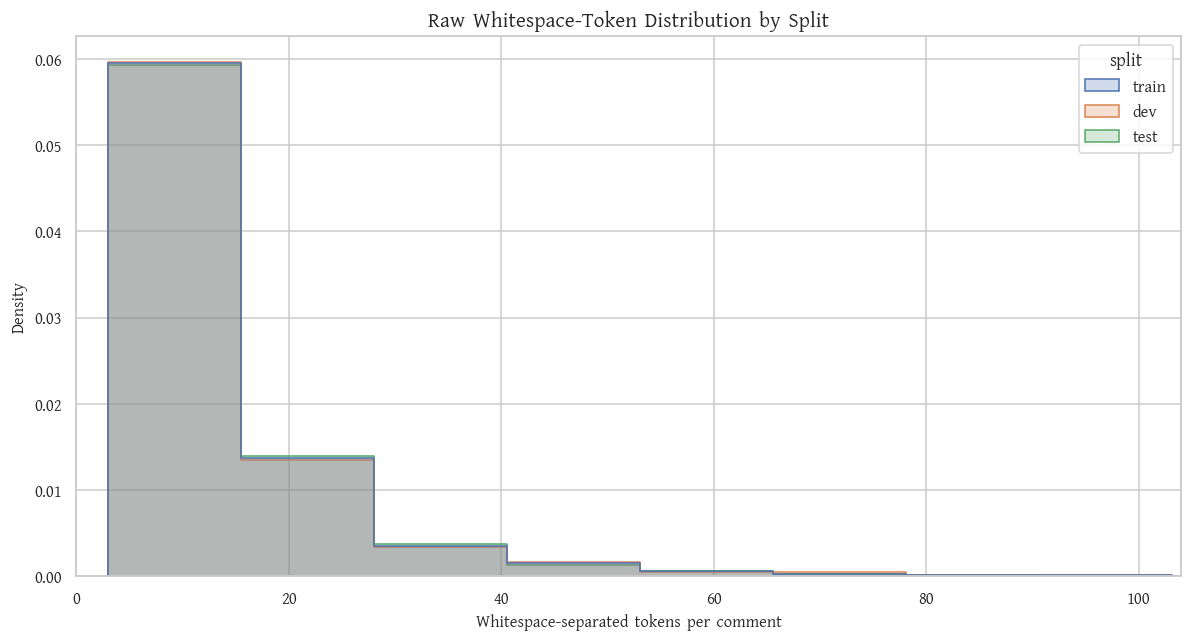

In [25]:
# Plot raw character and token-length distributions with robust percentile limits
char_upper = raw_all_df['raw_char_count'].quantile(0.995)
token_upper = raw_all_df['raw_whitespace_token_count'].quantile(0.995)

plt.figure(figsize=(11, 6))
sns.histplot(data=raw_all_df, x='raw_char_count', hue=SPLIT_COL, bins=60, element='step', stat='density', common_norm=False)
plt.xlim(0, max(char_upper, 1))
plt.title('Raw Character-Count Distribution by Split')
plt.xlabel('Characters per comment')
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
sns.histplot(data=raw_all_df, x='raw_whitespace_token_count', hue=SPLIT_COL, bins=50, element='step', stat='density', common_norm=False)
plt.xlim(0, max(token_upper, 1))
plt.title('Raw Whitespace-Token Distribution by Split')
plt.xlabel('Whitespace-separated tokens per comment')
plt.tight_layout()
plt.show()

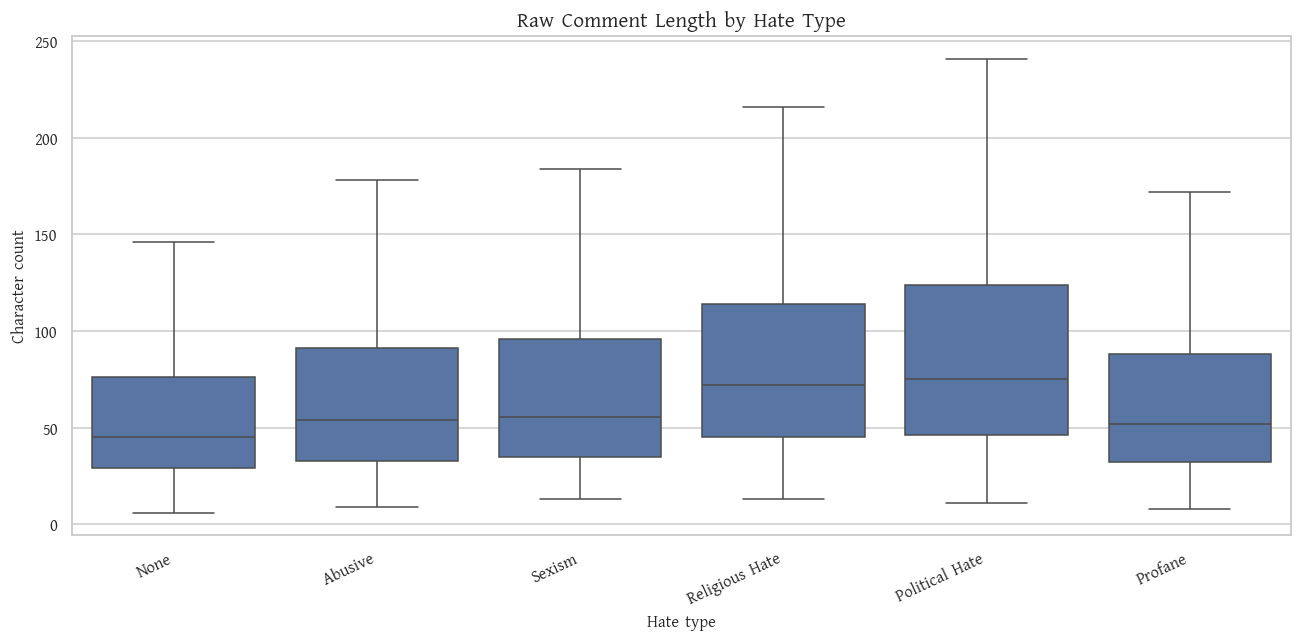

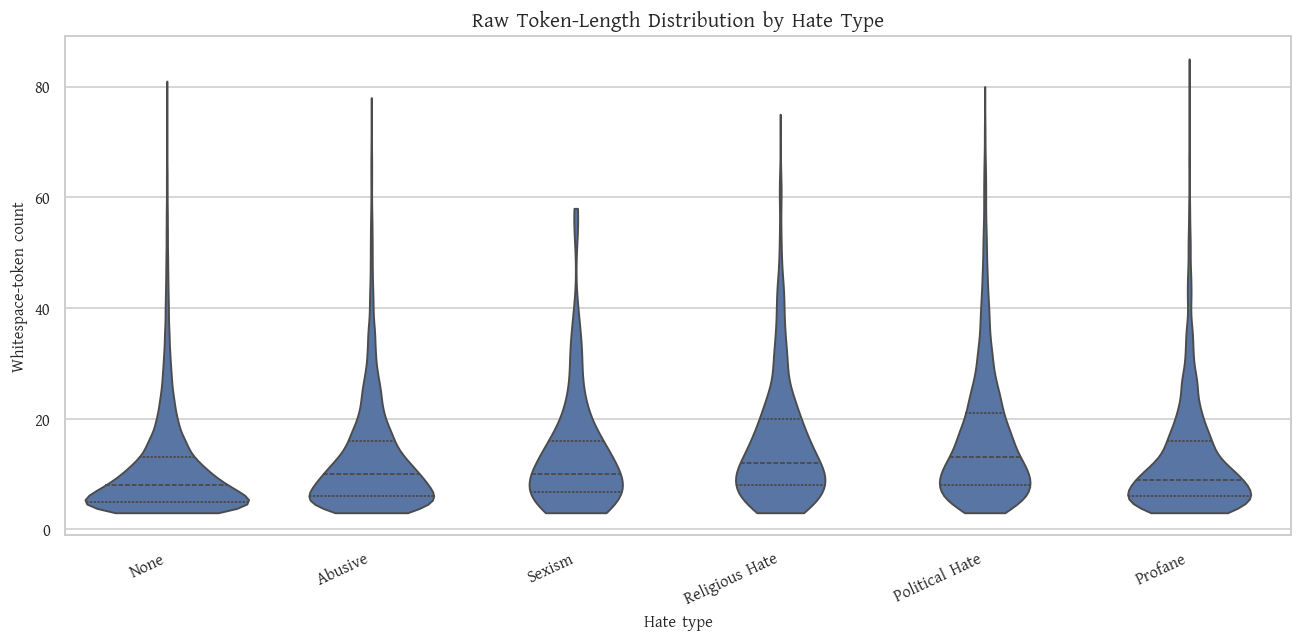

In [26]:
# Compare raw comment lengths across hate-type classes using box and violin plots
plot_df = raw_all_df[raw_all_df['raw_char_count'] <= raw_all_df['raw_char_count'].quantile(0.99)].copy()
plot_df[TARGET_COL] = pd.Categorical(plot_df[TARGET_COL], categories=CLASS_ORDER, ordered=True)

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x=TARGET_COL, y='raw_char_count', showfliers=False)
plt.title('Raw Comment Length by Hate Type')
plt.xlabel('Hate type')
plt.ylabel('Character count')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.violinplot(data=plot_df, x=TARGET_COL, y='raw_whitespace_token_count', cut=0, inner='quartile')
plt.title('Raw Token-Length Distribution by Hate Type')
plt.xlabel('Hate type')
plt.ylabel('Whitespace-token count')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

In [27]:
# Detect extreme text-length outliers with the interquartile-range method
q1 = raw_all_df['raw_char_count'].quantile(0.25)
q3 = raw_all_df['raw_char_count'].quantile(0.75)
iqr = q3 - q1
lower_bound = max(0, q1 - 1.5 * iqr)
upper_bound = q3 + 1.5 * iqr

raw_all_df['raw_length_outlier'] = ~raw_all_df['raw_char_count'].between(lower_bound, upper_bound)
outlier_summary = pd.crosstab(raw_all_df[SPLIT_COL], raw_all_df['raw_length_outlier'], margins=True)
print(f'IQR bounds for raw character count: {lower_bound:.2f} to {upper_bound:.2f}')
display(outlier_summary)

IQR bounds for raw character count: 0.00 to 176.00


raw_length_outlier,False,True,All
split,,,
dev,4678,346,5024
test,9472,728,10200
train,32982,2540,35522
All,47132,3614,50746


## **4.4 Script, Symbol, Code-Mixing, and Noise Analysis**

In [28]:
# Define reusable Unicode-aware counters for Bangla, Latin, digits, punctuation, emoji, and noisy patterns
BANGLA_PATTERN = re.compile(r'[\u0980-\u09FF]')
LATIN_PATTERN = re.compile(r'[A-Za-z]')
DIGIT_PATTERN = re.compile(r'\d')
URL_PATTERN = re.compile(r'(?:https?://|www\.)\S+', flags=re.IGNORECASE)
EMAIL_PATTERN = re.compile(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b')
MENTION_PATTERN = re.compile(r'(?<!\w)@[\w_]+', flags=re.UNICODE)
HASHTAG_PATTERN = re.compile(r'(?<!\w)#[\w_]+', flags=re.UNICODE)
REPEATED_PUNCT_PATTERN = re.compile(r'([!?.,।])\1{1,}')
REPEATED_CHAR_PATTERN = re.compile(r'(.)\1{2,}', flags=re.UNICODE)


def is_emoji_character(char):
    codepoint = ord(char)
    return (
        0x1F300 <= codepoint <= 0x1FAFF or
        0x2600 <= codepoint <= 0x26FF or
        0x2700 <= codepoint <= 0x27BF
    )


def raw_symbol_features(text):
    text = '' if pd.isna(text) else str(text)
    non_space_chars = max(sum(not char.isspace() for char in text), 1)
    bangla_count = len(BANGLA_PATTERN.findall(text))
    latin_count = len(LATIN_PATTERN.findall(text))
    digit_count = len(DIGIT_PATTERN.findall(text))
    punctuation_count = sum(unicodedata.category(char).startswith('P') for char in text)
    emoji_count = sum(is_emoji_character(char) for char in text)
    return pd.Series({
        'bangla_char_count_raw': bangla_count,
        'latin_char_count_raw': latin_count,
        'digit_count_raw': digit_count,
        'punctuation_count_raw': punctuation_count,
        'emoji_count_raw': emoji_count,
        'url_count_raw': len(URL_PATTERN.findall(text)),
        'email_count_raw': len(EMAIL_PATTERN.findall(text)),
        'mention_count_raw': len(MENTION_PATTERN.findall(text)),
        'hashtag_count_raw': len(HASHTAG_PATTERN.findall(text)),
        'repeated_punctuation_count_raw': len(REPEATED_PUNCT_PATTERN.findall(text)),
        'repeated_character_count_raw': len(REPEATED_CHAR_PATTERN.findall(text)),
        'bangla_char_ratio_raw': bangla_count / non_space_chars,
        'latin_char_ratio_raw': latin_count / non_space_chars,
        'digit_ratio_raw': digit_count / non_space_chars,
        'code_mixed_raw': int(bangla_count > 0 and latin_count > 0)
    })

raw_symbol_df = raw_all_df[TEXT_COL].apply(raw_symbol_features)
raw_all_df = pd.concat([raw_all_df, raw_symbol_df], axis=1)
print('Raw symbolic features created:', raw_symbol_df.shape[1])

Raw symbolic features created: 15


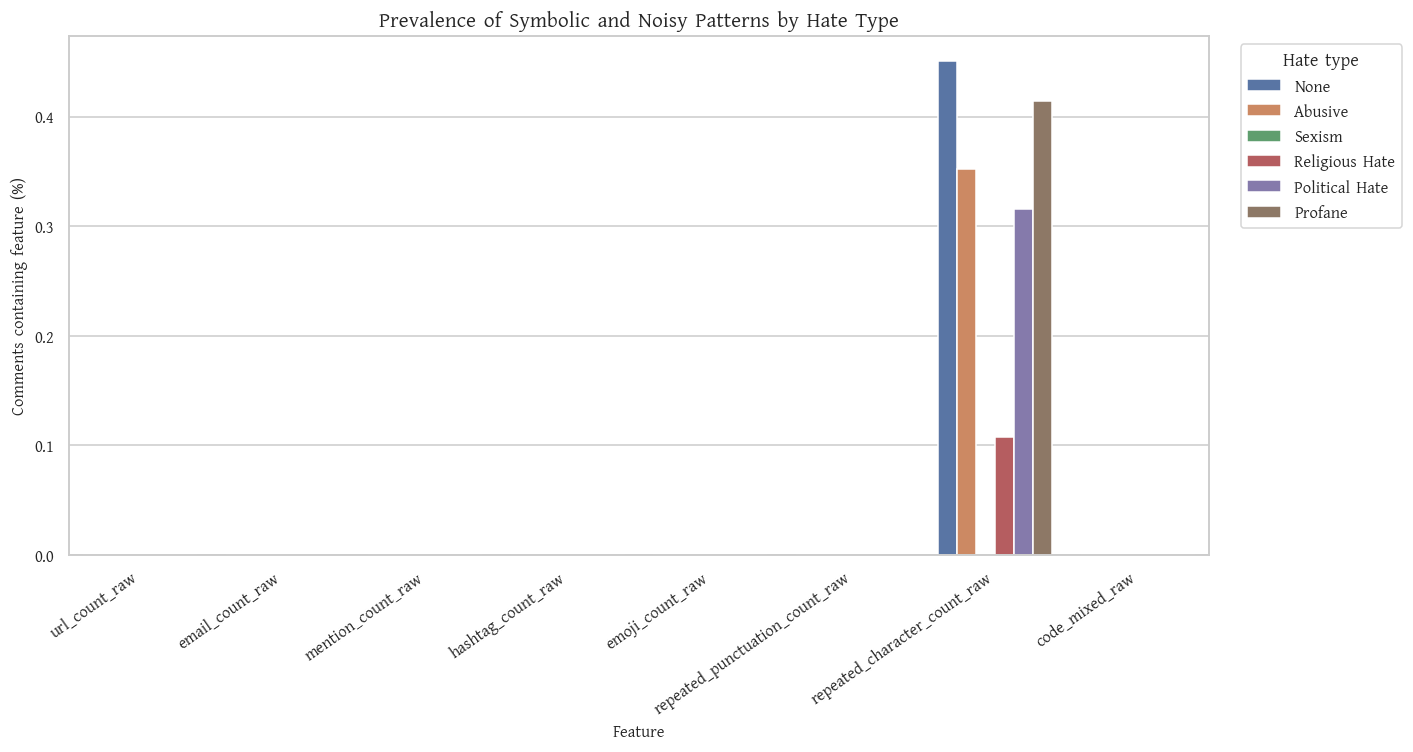

In [29]:
# Visualize the prevalence of URLs, mentions, hashtags, emoji, repeated punctuation, and code mixing
binary_prevalence_features = [
    'url_count_raw', 'email_count_raw', 'mention_count_raw', 'hashtag_count_raw',
    'emoji_count_raw', 'repeated_punctuation_count_raw', 'repeated_character_count_raw', 'code_mixed_raw'
]

prevalence_records = []
for feature in binary_prevalence_features:
    for label in CLASS_ORDER:
        values = raw_all_df.loc[raw_all_df[TARGET_COL] == label, feature]
        prevalence_records.append({
            'feature': feature,
            'hate_type': label,
            'percentage_with_feature': float((values > 0).mean() * 100) if len(values) else 0.0
        })
prevalence_df = pd.DataFrame(prevalence_records)

plt.figure(figsize=(13, 7))
sns.barplot(data=prevalence_df, x='feature', y='percentage_with_feature', hue='hate_type', hue_order=CLASS_ORDER)
plt.title('Prevalence of Symbolic and Noisy Patterns by Hate Type')
plt.xlabel('Feature')
plt.ylabel('Comments containing feature (%)')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Hate type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

bangla_char_ratio_raw             latin_char_ratio_raw         \
                                mean median  std                 mean median   
type_of_hate                                                                   
None                             1.0    1.0  0.0                  0.0    0.0   
Abusive                          1.0    1.0  0.0                  0.0    0.0   
Sexism                           1.0    1.0  0.0                  0.0    0.0   
Religious Hate                   1.0    1.0  0.0                  0.0    0.0   
Political Hate                   1.0    1.0  0.0                  0.0    0.0   
Profane                          1.0    1.0  0.0                  0.0    0.0   

                    digit_ratio_raw                   
                std            mean median       std  
type_of_hate                                          
None            0.0        0.004071    0.0  0.021608  
Abusive         0.0        0.001987    0.0  0.012742  
Sexism          0.0        0.000712    0.0  0.004296  
Religious Hate  0.0        0.001123    0.0  0.008688  
Political Hate  0.0        0.002227    0.0  0.013198  
Profane         0.0        0.001508    0.0  0.011358

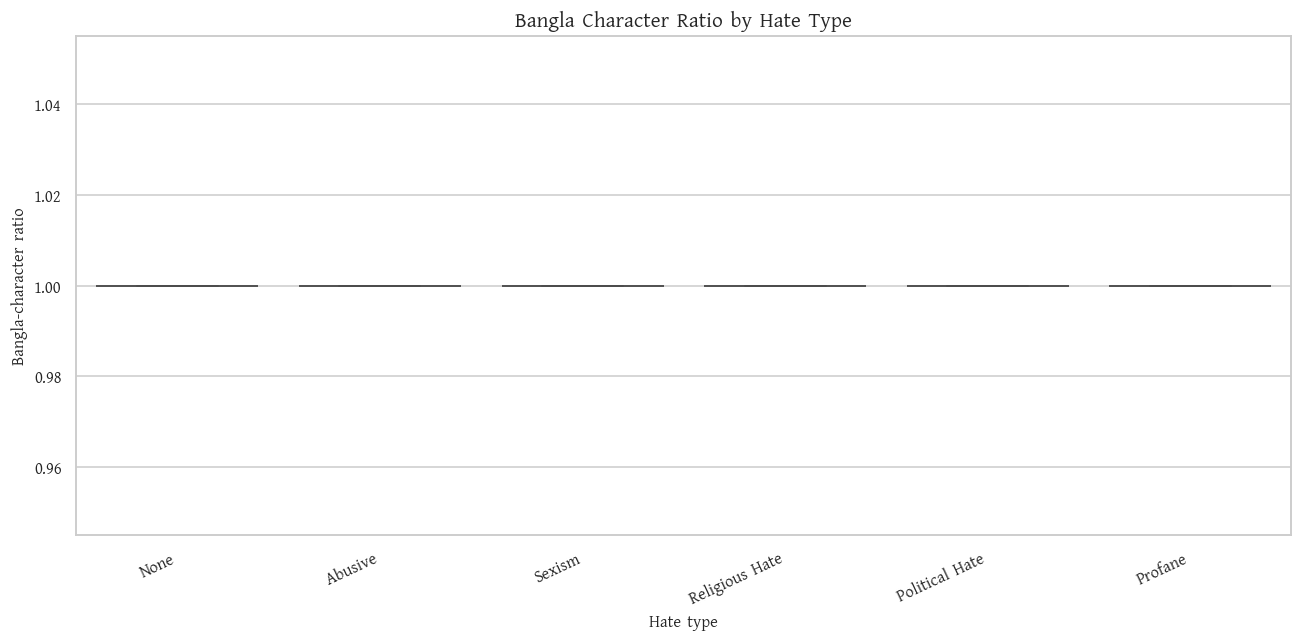

In [30]:
# Compare Bangla, Latin, digit, and code-mixing ratios across classes
ratio_columns = ['bangla_char_ratio_raw', 'latin_char_ratio_raw', 'digit_ratio_raw']
ratio_summary = raw_all_df.groupby(TARGET_COL)[ratio_columns].agg(['mean', 'median', 'std']).reindex(CLASS_ORDER)
display(ratio_summary)

sample_for_ratio_plot = raw_all_df.sample(min(8000, len(raw_all_df)), random_state=SEED)
plt.figure(figsize=(12, 6))
sns.boxplot(data=sample_for_ratio_plot, x=TARGET_COL, y='bangla_char_ratio_raw', order=CLASS_ORDER, showfliers=False)
plt.title('Bangla Character Ratio by Hate Type')
plt.xlabel('Hate type')
plt.ylabel('Bangla-character ratio')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## **4.5 Lexical Frequency, N-gram, and Distinctive-Term Analysis**

In [31]:
# Define lightweight Bangla tokenization and an EDA-only stopword set without altering model text
BANGLA_STOPWORDS = {
    'আমি', 'আমার', 'আমাদের', 'আমরা', 'তুমি', 'তোমার', 'তোমরা', 'আপনি', 'আপনার', 'সে', 'তার', 'তারা',
    'এই', 'এটা', 'এটি', 'ওই', 'সেই', 'যে', 'যা', 'যার', 'যদি', 'তাহলে', 'কিন্তু', 'এবং', 'আর', 'বা',
    'না', 'নয়', 'নেই', 'হয়', 'হয়ে', 'হবে', 'ছিল', 'আছে', 'করে', 'করেছে', 'করতে', 'করা', 'এর', 'কে',
    'কি', 'কী', 'কেন', 'কোন', 'কোনো', 'এক', 'একটি', 'অনেক', 'খুব', 'আরও', 'থেকে', 'জন্য', 'সাথে',
    'উপর', 'মধ্যে', 'সব', 'কিছু', 'তো', 'ও', 'হে', 'এ', 'তে', 'রা', 'গুলো', 'দিয়ে', 'দিয়ে'
}


def simple_bangla_tokenize(text):
    return re.findall(r'[\u0980-\u09FF]+|[A-Za-z]+|\d+', str(text).lower())


def eda_tokens(text):
    return [token for token in simple_bangla_tokenize(text) if token not in BANGLA_STOPWORDS and len(token) > 1]

raw_all_df['_eda_tokens'] = raw_all_df[TEXT_COL].fillna('').map(eda_tokens)
print('Tokenization completed for lexical EDA.')

Tokenization completed for lexical EDA.


,token,frequency
0,কথা,1997
1,ভালো,1961
2,মানুষ,1777
3,দেশের,1664
4,টাকা,1630
5,আল্লাহ,1613
6,নাই,1604
7,এখন,1549
8,একটা,1538
9,বাংলাদেশ,1519


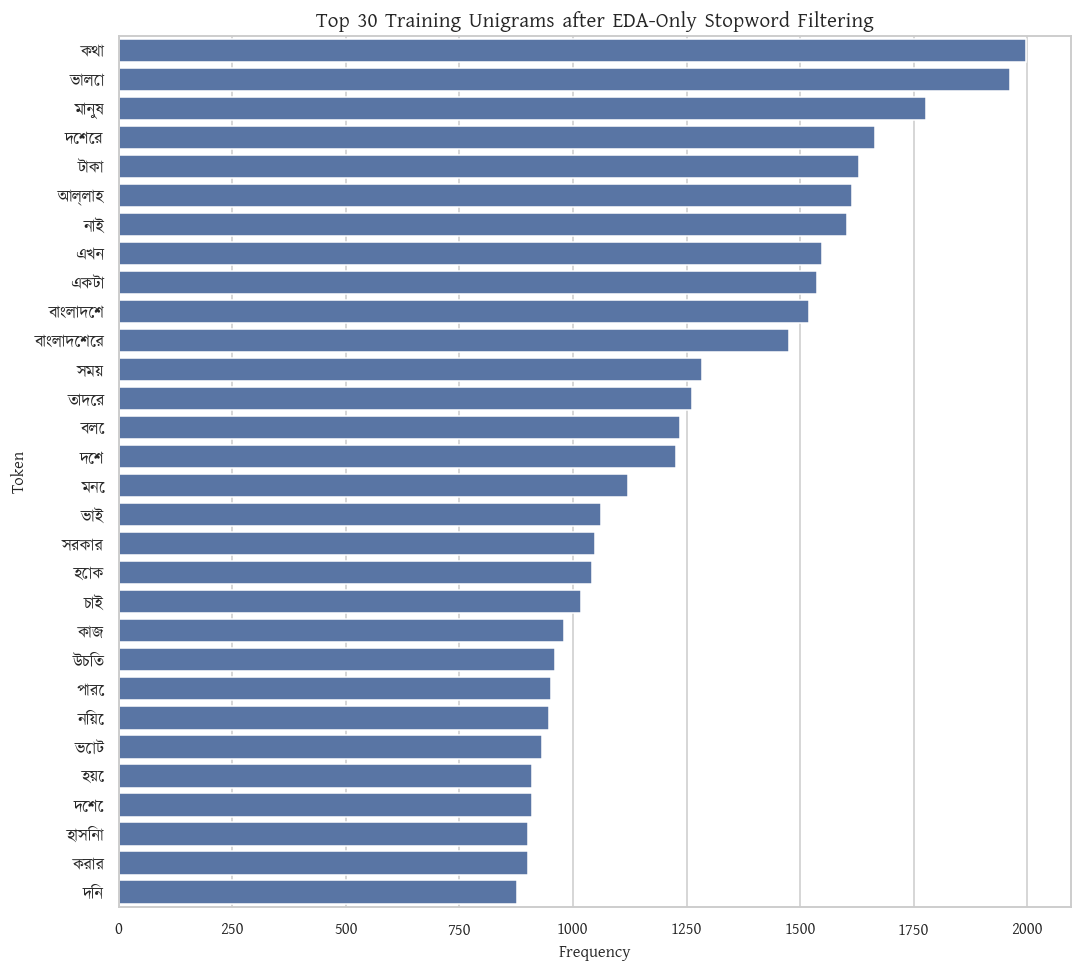

In [32]:
# Plot the most frequent non-stopword unigrams in the training split
train_tokens = [token for tokens in raw_all_df.loc[raw_all_df[SPLIT_COL] == 'train', '_eda_tokens'] for token in tokens]
top_unigrams = pd.DataFrame(Counter(train_tokens).most_common(30), columns=['token', 'frequency'])
display(top_unigrams)

plt.figure(figsize=(10, 9))
sns.barplot(data=top_unigrams, x='frequency', y='token', color=sns.color_palette()[0])
plt.title('Top 30 Training Unigrams after EDA-Only Stopword Filtering')
plt.xlabel('Frequency')
plt.ylabel('Token')
plt.tight_layout()
plt.show()


TOP UNIGRAMS: None


,token,frequency
0,ভালো,1329
1,আল্লাহ,1244
2,কথা,993
3,মানুষ,914
4,বাংলাদেশ,827
5,টাকা,824
6,ভাই,784
7,বাংলাদেশের,725
8,নাই,716
9,একটা,712



TOP UNIGRAMS: Abusive


,token,frequency
0,কথা,510
1,নাই,473
2,সময়,464
3,মানুষ,452
4,একটা,445
5,এখন,438
6,টাকা,429
7,দেশের,425
8,বাংলাদেশ,382
9,টিভি,374



TOP UNIGRAMS: Sexism


...

,token,frequency
0,মুসলিম,124
1,আল্লাহ,122
2,হিন্দু,50
3,আল্লাহর,50
4,মুসলমানদের,46
5,গজব,43
6,ইহুদি,43
7,তাদের,42
8,করবে,41
9,ইসলাম,41



TOP UNIGRAMS: Political Hate


,token,frequency
0,ভোট,523
1,সরকার,454
2,দেশের,408
3,হাসিনা,362
4,কথা,331
5,লীগ,324
6,বিএনপি,318
7,বাংলাদেশের,314
8,এখন,310
9,নির্বাচন,303



TOP UNIGRAMS: Profane


,token,frequency
0,বাল,257
1,বাচ্চা,194
2,হাসিনা,172
3,একটা,156
4,বালের,131
5,তোর,131
6,কবে,129
7,দফা,123
8,টাকা,122
9,দেশের,117


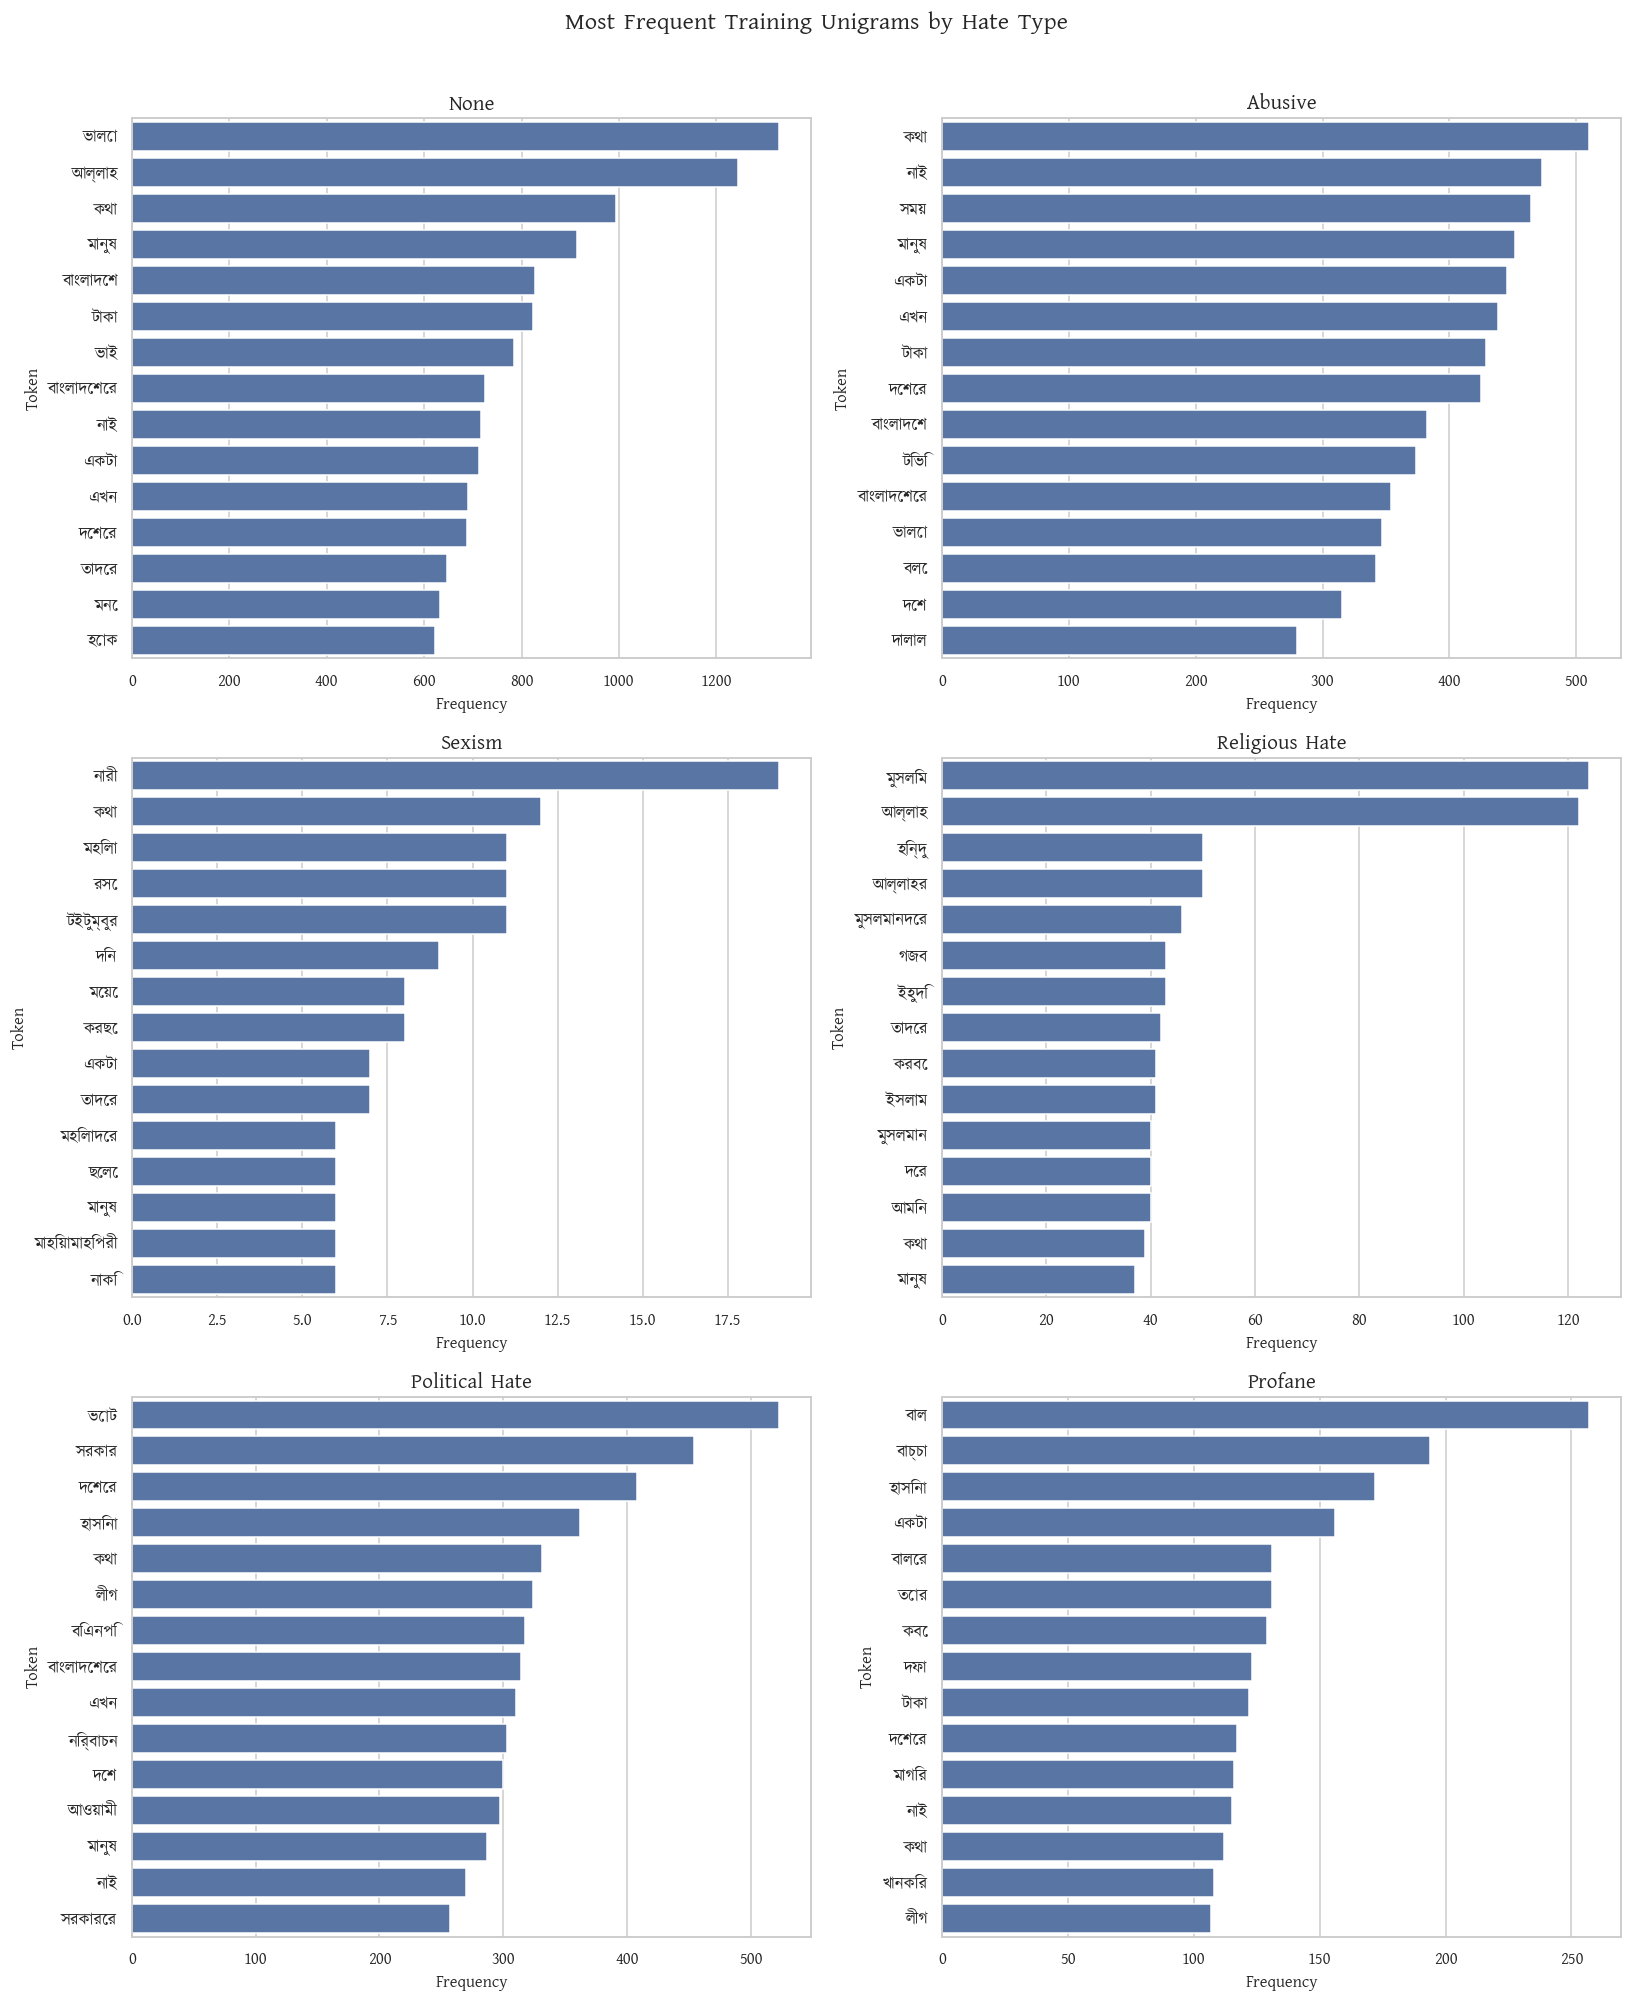

In [33]:
# Display and plot the most frequent unigrams separately for every hate-type class
class_top_unigrams = {}
for label in CLASS_ORDER:
    tokens = [
        token
        for token_list in raw_all_df.loc[
            (raw_all_df[SPLIT_COL] == 'train') & (raw_all_df[TARGET_COL] == label), '_eda_tokens'
        ]
        for token in token_list
    ]
    table = pd.DataFrame(Counter(tokens).most_common(15), columns=['token', 'frequency'])
    class_top_unigrams[label] = table
    print(f'\nTOP UNIGRAMS: {label}')
    display(table)

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
for axis, label in zip(axes.flat, CLASS_ORDER):
    table = class_top_unigrams[label]
    if not table.empty:
        sns.barplot(data=table, x='frequency', y='token', ax=axis, color=sns.color_palette()[0])
    axis.set_title(label)
    axis.set_xlabel('Frequency')
    axis.set_ylabel('Token')
plt.suptitle('Most Frequent Training Unigrams by Hate Type', y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

In [34]:
# Extract the most frequent bigrams for each class from the training split

def top_ngrams_for_series(text_series, ngram_range=(2, 2), top_k=15):
    vectorizer = CountVectorizer(
        tokenizer=eda_tokens,
        token_pattern=None,
        lowercase=False,
        ngram_range=ngram_range,
        min_df=1
    )
    matrix = vectorizer.fit_transform(text_series.astype(str))
    frequencies = np.asarray(matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    order = frequencies.argsort()[::-1][:top_k]
    return pd.DataFrame({'ngram': terms[order], 'frequency': frequencies[order]})

class_top_bigrams = {}
for label in CLASS_ORDER:
    texts = raw_all_df.loc[
        (raw_all_df[SPLIT_COL] == 'train') & (raw_all_df[TARGET_COL] == label), TEXT_COL
    ]
    class_top_bigrams[label] = top_ngrams_for_series(texts, ngram_range=(2, 2), top_k=15) if len(texts) else pd.DataFrame()
    print(f'\nTOP BIGRAMS: {label}')
    display(class_top_bigrams[label])


TOP BIGRAMS: None


,ngram,frequency
0,শেখ হাসিনা,164
1,সময় টিভি,113
2,করুন আমিন,109
3,দান করুন,107
4,শেখ হাসিনার,98
5,হেফাজত করুন,98
6,জয় বাংলা,93
7,দেখতে চাই,82
8,কথা বলে,82
9,হতে পারে,82



TOP BIGRAMS: Abusive


,ngram,frequency
0,সময় টিভি,175
1,সময় টিভি,100
2,মিথ্যা কথা,62
3,সময় টিভির,60
4,কথা বলে,56
5,হয়ে গেছে,54
6,চোর চোর,54
7,শেখ হাসিনা,47
8,মনে হয়,43
9,হা হা,43



TOP BIGRAMS: Sexism


...

,ngram,frequency
0,আল্লাহর গজব,15
1,হয়ে গেছে,10
2,হতে পারে,8
3,মুসলিম দেশ,7
4,হাজার হাজার,7
5,আল্লাহর কাছে,7
6,হেফাজত করুন,7
7,ছি ছি,6
8,আল্লাহ গজব,6
9,ধমীয় সহিংসতা,5



TOP BIGRAMS: Political Hate


,ngram,frequency
0,আওয়ামী লীগ,128
1,শেখ হাসিনা,122
2,আওয়ামী লীগ,100
3,ভোট চোর,95
4,আওয়ামী লীগের,84
5,আওয়ামী লীগের,77
6,বি এন,77
7,শেখ হাসিনার,65
8,এন পি,57
9,ভোট চুরি,51



TOP BIGRAMS: Profane


,ngram,frequency
0,হাসিনা কবে,123
1,কবে যাবিএক,98
2,যাবিএক দফা,98
3,আওয়ামী লীগ,79
4,বেশ্যা মাগির,77
5,মাগির পোলারাই,76
6,পোলারাই আওয়ামী,76
7,লীগ করেএকমাত্র,75
8,করেএকমাত্র বেশ্যা,75
9,কুত্তার বাচ্চা,47


In [35]:
# Use chi-square scores to identify class-distinctive word and bigram features
train_raw = raw_all_df[raw_all_df[SPLIT_COL] == 'train'].copy()
chi_vectorizer = TfidfVectorizer(
    tokenizer=eda_tokens,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 2),
    min_df=3,
    max_features=12000,
    sublinear_tf=True
)
chi_matrix = chi_vectorizer.fit_transform(train_raw[TEXT_COL].astype(str))
chi_terms = np.asarray(chi_vectorizer.get_feature_names_out())

distinctive_term_records = []
for label in CLASS_ORDER:
    binary_target = (train_raw[TARGET_COL].values == label).astype(int)
    scores, p_values = chi2(chi_matrix, binary_target)
    top_indices = np.argsort(scores)[-20:][::-1]
    for rank, index in enumerate(top_indices, start=1):
        distinctive_term_records.append({
            'hate_type': label,
            'rank': rank,
            'term': chi_terms[index],
            'chi_square': float(scores[index]),
            'p_value': float(p_values[index])
        })

distinctive_terms_df = pd.DataFrame(distinctive_term_records)
display(distinctive_terms_df.groupby('hate_type').head(10))

,hate_type,rank,term,chi_square,p_value
0,None,1,দালাল,123.732539,9.639997e-29
1,None,2,বাল,107.031850,4.380723e-25
2,None,3,চোর,104.392307,1.659737e-24
3,None,4,ধন্যবাদ,92.217796,7.764343e-22
4,None,5,লীগ,69.436905,7.889847e-17
5,None,6,ভোট,69.435543,7.895300e-17
6,None,7,আল্লাহ,67.725925,1.878769e-16
7,None,8,শালা,66.187092,4.100893e-16
8,None,9,বাচ্চা,65.388671,6.149137e-16
9,None,10,বিএনপি,61.231006,5.075587e-15


In [36]:
# Calculate lexical diversity, vocabulary size, and hapax proportions by class
lexical_diversity_records = []
for label in CLASS_ORDER:
    token_lists = raw_all_df.loc[
        (raw_all_df[SPLIT_COL] == 'train') & (raw_all_df[TARGET_COL] == label), '_eda_tokens'
    ]
    tokens = [token for token_list in token_lists for token in token_list]
    counts = Counter(tokens)
    total_tokens = len(tokens)
    vocabulary_size = len(counts)
    hapax_count = sum(frequency == 1 for frequency in counts.values())
    lexical_diversity_records.append({
        'hate_type': label,
        'total_tokens': total_tokens,
        'vocabulary_size': vocabulary_size,
        'type_token_ratio': vocabulary_size / max(total_tokens, 1),
        'hapax_types': hapax_count,
        'hapax_proportion_of_vocabulary': hapax_count / max(vocabulary_size, 1)
    })
lexical_diversity_df = pd.DataFrame(lexical_diversity_records)
display(lexical_diversity_df)

,hate_type,total_tokens,vocabulary_size,type_token_ratio,hapax_types,hapax_proportion_of_vocabulary
0,None,199851,33286,0.166554,20503,0.615965
1,Abusive,93132,20089,0.215705,12450,0.619742
2,Sexism,1645,1158,0.703951,918,0.792746
3,Religious Hate,9221,3886,0.421429,2590,0.666495
4,Political Hate,66362,14623,0.220352,8986,0.614511
5,Profane,26678,8526,0.319589,5655,0.663265


In [37]:
# Generate optional class-specific word clouds only when a Bengali-capable font file is available
font_file_candidates = [
    '/usr/share/fonts/truetype/noto/NotoSansBengali-Regular.ttf',
    '/usr/share/fonts/opentype/noto/NotoSansBengali-Regular.ttf',
    '/usr/share/fonts/truetype/lohit-bengali/Lohit-Bengali.ttf'
]
bengali_font_path = next((path for path in font_file_candidates if os.path.exists(path)), None)

if bengali_font_path is None:
    print('Bengali font file was not found. Word clouds are skipped safely; frequency plots above remain valid.')
else:
    fig, axes = plt.subplots(3, 2, figsize=(16, 15))
    for axis, label in zip(axes.flat, CLASS_ORDER):
        tokens = [
            token for token_list in raw_all_df.loc[
                (raw_all_df[SPLIT_COL] == 'train') & (raw_all_df[TARGET_COL] == label), '_eda_tokens'
            ] for token in token_list
        ]
        wordcloud_text = ' '.join(tokens)
        if wordcloud_text.strip():
            cloud = WordCloud(
                width=900, height=450, background_color='white',
                font_path=bengali_font_path, collocations=False
            ).generate(wordcloud_text)
            axis.imshow(cloud, interpolation='bilinear')
        axis.axis('off')
        axis.set_title(label)
    plt.suptitle('Training Word Clouds by Hate Type', fontsize=16)
    plt.tight_layout()
    plt.show()

Bengali font file was not found. Word clouds are skipped safely; frequency plots above remain valid.


## **4.6 Text-Space Structure and Metadata Association**

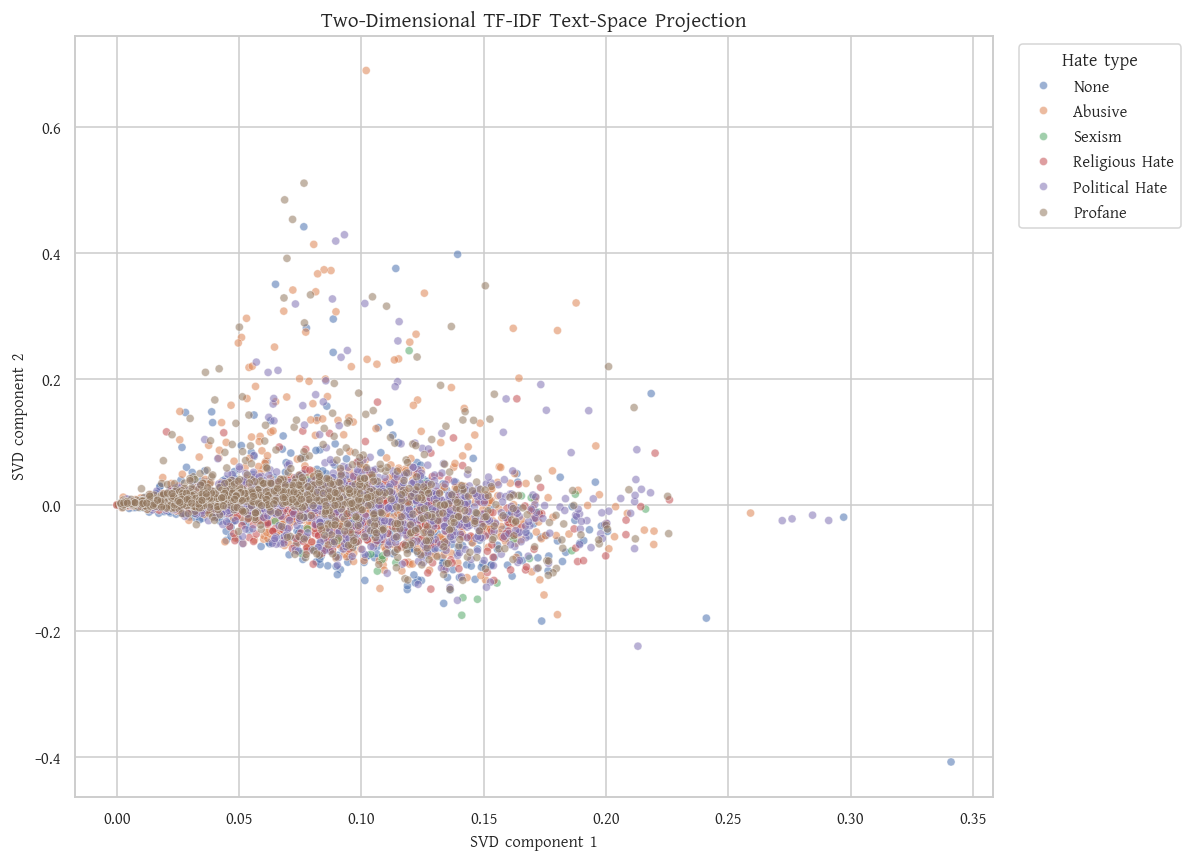

Variance explained by two components: 0.0049488996010673796


In [38]:
# Project a stratified sample of raw training text into two dimensions with TF-IDF and Truncated SVD
sample_parts = []
for label in CLASS_ORDER:
    class_part = train_raw[train_raw[TARGET_COL] == label]
    sample_parts.append(class_part.sample(min(1000, len(class_part)), random_state=SEED))
svd_sample_df = pd.concat(sample_parts, ignore_index=True)

eda_tfidf = TfidfVectorizer(
    tokenizer=simple_bangla_tokenize,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_features=10000,
    sublinear_tf=True
)
eda_tfidf_matrix = eda_tfidf.fit_transform(svd_sample_df[TEXT_COL].astype(str))
eda_svd = TruncatedSVD(n_components=2, random_state=SEED)
eda_coordinates = eda_svd.fit_transform(eda_tfidf_matrix)
svd_sample_df['svd_1'] = eda_coordinates[:, 0]
svd_sample_df['svd_2'] = eda_coordinates[:, 1]

plt.figure(figsize=(11, 8))
sns.scatterplot(
    data=svd_sample_df, x='svd_1', y='svd_2', hue=TARGET_COL,
    hue_order=CLASS_ORDER, alpha=0.55, s=28
)
plt.title('Two-Dimensional TF-IDF Text-Space Projection')
plt.xlabel('SVD component 1')
plt.ylabel('SVD component 2')
plt.legend(title='Hate type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Variance explained by two components:', eda_svd.explained_variance_ratio_.sum())

,None,Abusive,Sexism,Religious Hate,Political Hate,Profane
None,1.000,0.782,0.508,0.631,0.707,0.603
Abusive,0.782,1.000,0.534,0.623,0.760,0.708
Sexism,0.508,0.534,1.000,0.408,0.456,0.430
Religious Hate,0.631,0.623,0.408,1.000,0.557,0.491
Political Hate,0.707,0.760,0.456,0.557,1.000,0.617
Profane,0.603,0.708,0.430,0.491,0.617,1.000


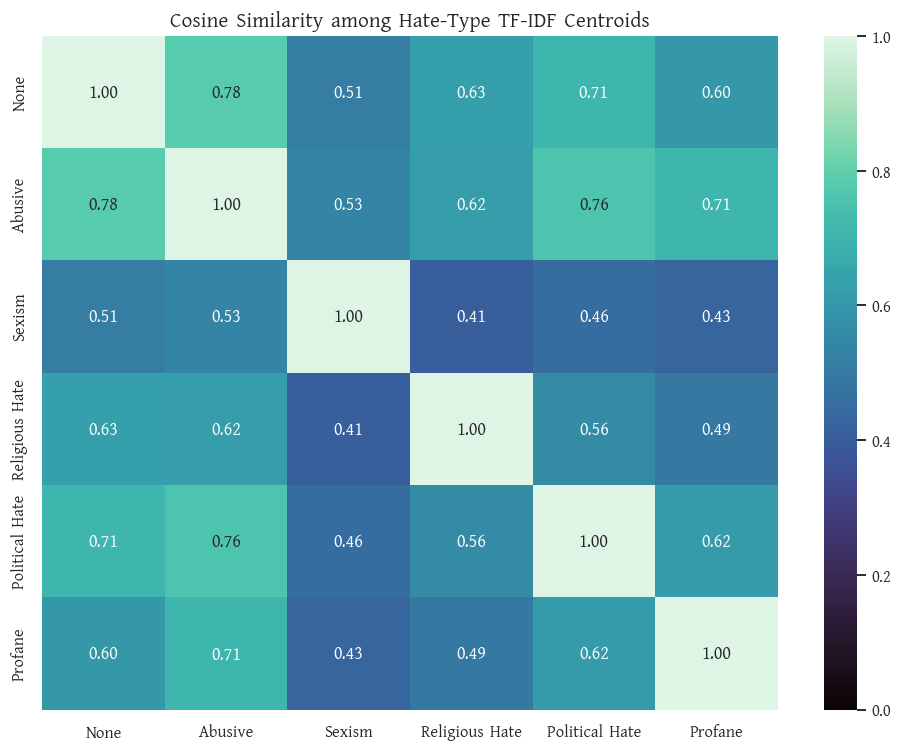

In [39]:
# Calculate cosine similarity among class centroids in TF-IDF space
class_centroids = []
for label in CLASS_ORDER:
    class_rows = svd_sample_df[TARGET_COL].values == label
    if class_rows.any():
        class_centroids.append(np.asarray(eda_tfidf_matrix[class_rows].mean(axis=0)).ravel())
    else:
        class_centroids.append(np.zeros(eda_tfidf_matrix.shape[1]))

centroid_similarity = cosine_similarity(np.vstack(class_centroids))
centroid_similarity_df = pd.DataFrame(centroid_similarity, index=CLASS_ORDER, columns=CLASS_ORDER)
display(centroid_similarity_df.round(3))

plt.figure(figsize=(9, 7))
sns.heatmap(centroid_similarity_df, annot=True, fmt='.2f', cmap='mako', vmin=0, vmax=1)
plt.title('Cosine Similarity among Hate-Type TF-IDF Centroids')
plt.tight_layout()
plt.show()

In [40]:
# Measure association between categorical metadata and hate type with Cramer's V

def cramers_v(x, y):
    confusion = pd.crosstab(x.fillna('Unknown'), y.fillna('Unknown'))
    observed = confusion.values
    if observed.size == 0:
        return np.nan
    row_sums = observed.sum(axis=1, keepdims=True)
    col_sums = observed.sum(axis=0, keepdims=True)
    total = observed.sum()
    expected = row_sums @ col_sums / max(total, 1)
    valid = expected > 0
    chi_square = np.sum(((observed - expected) ** 2)[valid] / expected[valid])
    phi2 = chi_square / max(total, 1)
    rows, cols = observed.shape
    corrected_phi2 = max(0, phi2 - ((cols - 1) * (rows - 1)) / max(total - 1, 1))
    corrected_rows = rows - ((rows - 1) ** 2) / max(total - 1, 1)
    corrected_cols = cols - ((cols - 1) ** 2) / max(total - 1, 1)
    denominator = min(corrected_cols - 1, corrected_rows - 1)
    return math.sqrt(corrected_phi2 / denominator) if denominator > 0 else 0.0

association_records = []
for column in ['category', 'subcategory', 'severity_of_hate', 'target_of_hate', SPLIT_COL]:
    association_records.append({
        'feature': column,
        'cramers_v_with_type_of_hate': cramers_v(raw_all_df[column], raw_all_df[TARGET_COL])
    })
metadata_association_df = pd.DataFrame(association_records).sort_values('cramers_v_with_type_of_hate', ascending=False)
display(metadata_association_df)

,feature,cramers_v_with_type_of_hate
2,severity_of_hate,0.632244
3,target_of_hate,0.497758
1,subcategory,0.119680
0,category,0.101743
4,split,0.003745


# **5. Missing-Value Handling and Text Preprocessing**

## **5.1 Preprocessing Policy**

The final model text uses **conservative normalization** rather than aggressive stemming or stopword deletion. Hate-type classification and later SHAP/LIME explanations depend on the original words, negations, slang, and short phrases. The notebook therefore:

- normalizes Unicode and invisible characters;
- decodes HTML and removes HTML tags;
- replaces URLs, emails, mentions, and numbers with interpretable placeholders;
- standardizes whitespace and repeated punctuation;
- retains Bangla words, Latin code-mixed words, emojis, and meaningful punctuation information through derived numeric features;
- creates a separate lexical-analysis variant for frequency plots only;
- never fits transformations on development or test data.

In [41]:
# Define deterministic Unicode-aware text-normalization and lexical-cleaning functions
ZERO_WIDTH_PATTERN = re.compile(r'[\u200B-\u200D\uFEFF]')
HTML_TAG_PATTERN = re.compile(r'<[^>]+>')
MULTISPACE_PATTERN = re.compile(r'\s+')
MULTI_PUNCT_REPLACEMENTS = [
    (re.compile(r'!{4,}'), '!!!'),
    (re.compile(r'\?{4,}'), '???'),
    (re.compile(r'।{4,}'), '।।।'),
    (re.compile(r'\.{4,}'), '...')
]


def normalize_model_text(text):
    """Conservative model-facing normalization that preserves semantic cues."""
    if pd.isna(text):
        return ''
    text = html.unescape(str(text))
    text = unicodedata.normalize('NFC', text)
    text = ZERO_WIDTH_PATTERN.sub('', text)
    text = ''.join(char for char in text if not (unicodedata.category(char).startswith('C') and char not in '\n\t\r'))
    text = HTML_TAG_PATTERN.sub(' ', text)
    text = EMAIL_PATTERN.sub(' EMAILTOKEN ', text)
    text = URL_PATTERN.sub(' URLTOKEN ', text)
    text = MENTION_PATTERN.sub(' USERTOKEN ', text)
    text = re.sub(r'(?<!\w)#([\w_]+)', r' HASHTAGTOKEN \1 ', text, flags=re.UNICODE)
    text = re.sub(r'\d+', ' NUMBERTOKEN ', text)
    for pattern, replacement in MULTI_PUNCT_REPLACEMENTS:
        text = pattern.sub(replacement, text)
    text = MULTISPACE_PATTERN.sub(' ', text).strip()
    return text


def normalize_lexical_text(text):
    """EDA and bag-of-words variant containing Bangla, Latin, numeric placeholders, and spaces only."""
    text = normalize_model_text(text).lower()
    text = re.sub(r'[^\u0980-\u09FFA-Za-z_\s]', ' ', text)
    text = MULTISPACE_PATTERN.sub(' ', text).strip()
    return text


def stopword_filtered_text(text):
    """EDA-only variant; this column is not the default modeling text."""
    return ' '.join(token for token in simple_bangla_tokenize(text) if token not in BANGLA_STOPWORDS and len(token) > 1)

In [42]:
# Standardize missing values, drop unusable supervised rows, fill metadata, and remove exact duplicates within splits
cleaning_audit_records = []
cleaned_splits = {}

for split_name, split_df in raw_splits.items():
    current = split_df.copy()
    before_rows = len(current)

    for column in EXPECTED_COLUMNS:
        current[column] = current[column].astype('string').str.strip()
        normalized = current[column].str.lower()
        current.loc[normalized.isin(MISSING_TEXT_TOKENS), column] = pd.NA

    missing_text_rows = int(current[TEXT_COL].isna().sum())
    missing_target_rows = int(current[TARGET_COL].isna().sum())
    current = current.dropna(subset=[TEXT_COL, TARGET_COL]).copy()

    current['id'] = current['id'].fillna(pd.Series(
        [f'{split_name}_generated_{i}' for i in range(len(current))], index=current.index, dtype='string'
    ))

    for metadata_column in ['category', 'subcategory', 'severity_of_hate', 'target_of_hate']:
        current[metadata_column] = current[metadata_column].fillna('Unknown')

    exact_duplicates = int(current.duplicated().sum())
    current = current.drop_duplicates().reset_index(drop=True)
    current[SPLIT_COL] = split_name

    cleaning_audit_records.append({
        'split': split_name,
        'rows_before': before_rows,
        'missing_text_rows_removed': missing_text_rows,
        'missing_target_rows_removed': missing_target_rows,
        'exact_duplicate_rows_removed': exact_duplicates,
        'rows_after_basic_cleaning': len(current)
    })
    cleaned_splits[split_name] = current

cleaning_audit_df = pd.DataFrame(cleaning_audit_records)
display(cleaning_audit_df)

,split,rows_before,missing_text_rows_removed,missing_target_rows_removed,exact_duplicate_rows_removed,rows_after_basic_cleaning
0,train,35522,0,19954,0,15568
1,dev,5024,0,2898,0,2126
2,test,10200,0,5751,0,4449


In [43]:
# Apply raw-preserving, conservative model, lexical, and stopword-filtered text variants to every split
for split_name, split_df in cleaned_splits.items():
    split_df['text_raw'] = split_df[TEXT_COL].astype(str)
    split_df['text_model'] = split_df[TEXT_COL].map(normalize_model_text)
    split_df['text_lexical'] = split_df[TEXT_COL].map(normalize_lexical_text)
    split_df['text_eda_no_stopwords'] = split_df['text_lexical'].map(stopword_filtered_text)
    split_df['_normalized_duplicate_key'] = split_df['text_model'].str.lower()
    cleaned_splits[split_name] = split_df

cleaned_all_df = pd.concat(cleaned_splits.values(), ignore_index=True)
print('Combined cleaned shape:', cleaned_all_df.shape)
display(cleaned_all_df[['text_raw', 'text_model', 'text_lexical', TARGET_COL, SPLIT_COL]].head())

Combined cleaned shape: (22143, 13)


,text_raw,text_model,text_lexical,type_of_hate,split
0,অতিরিক্ত এ নিজেকে বাদুর বানাইয়া ফেলছেন রে,অতিরিক্ত এ নিজেকে বাদুর বানাইয়া ফেলছেন রে,অতিরিক্ত এ নিজেকে বাদুর বানাইয়া ফেলছেন রে,Abusive,train
1,এটার বিচার কে করবেযে বিচার করবে সেই তো হলো এই সমস্ত চোরদের গড ফাদার,এটার বিচার কে করবেযে বিচার করবে সেই তো হলো এই সমস্ত চোরদের গড ফাদার,এটার বিচার কে করবেযে বিচার করবে সেই তো হলো এই সমস্ত চোরদের গড ফাদার,Abusive,train
2,ইরান পারমাণবিক বোমা বানাবে বানাবে বলতে বলতে বিয়া করার বয়স হই গেছে বোমা আর বানানো হলো না,ইরান পারমাণবিক বোমা বানাবে বানাবে বলতে বলতে বিয়া করার বয়স হই গেছে বোমা আর বানানো হলো না,ইরান পারমাণবিক বোমা বানাবে বানাবে বলতে বলতে বিয়া করার বয়স হই গেছে বোমা আর বানানো হলো না,Abusive,train
3,মুসলিম বাচ্চাগুলো বাচ্চা পেরে পেরে গোটা পৃথিবীর ধ্বংস করে দেবে শালা শুয়োরের বাচ্চা গুলো,মুসলিম বাচ্চাগুলো বাচ্চা পেরে পেরে গোটা পৃথিবীর ধ্বংস করে দেবে শালা শুয়োরের বাচ্চা গুলো,মুসলিম বাচ্চাগুলো বাচ্চা পেরে পেরে গোটা পৃথিবীর ধ্বংস করে দেবে শালা শুয়োরের বাচ্চা গুলো,Profane,train
4,বাড়ি বাল ফালায়ছে,বাড়ি বাল ফালায়ছে,বাড়ি বাল ফালায়ছে,Profane,train


In [44]:
# Audit empty outputs, text changes, length changes, and placeholder creation after normalization
transformation_audit_records = []
for split_name, split_df in cleaned_splits.items():
    changed = split_df['text_raw'].ne(split_df['text_model'])
    transformation_audit_records.append({
        'split': split_name,
        'rows': len(split_df),
        'empty_model_text': int(split_df['text_model'].str.strip().eq('').sum()),
        'empty_lexical_text': int(split_df['text_lexical'].str.strip().eq('').sum()),
        'rows_changed_by_normalization': int(changed.sum()),
        'rows_changed_percent': float(changed.mean() * 100),
        'url_placeholders': int(split_df['text_model'].str.count('URLTOKEN').sum()),
        'user_placeholders': int(split_df['text_model'].str.count('USERTOKEN').sum()),
        'email_placeholders': int(split_df['text_model'].str.count('EMAILTOKEN').sum()),
        'number_placeholders': int(split_df['text_model'].str.count('NUMBERTOKEN').sum())
    })
transformation_audit_df = pd.DataFrame(transformation_audit_records)
display(transformation_audit_df)

if transformation_audit_df['empty_model_text'].sum() > 0:
    print('Warning: Some comments became empty after normalization and will be removed below.')

,split,rows,empty_model_text,empty_lexical_text,rows_changed_by_normalization,rows_changed_percent,url_placeholders,user_placeholders,email_placeholders,number_placeholders
0,train,15568,0,0,7564,48.586845,0,0,0,1299
1,dev,2126,0,0,1039,48.871119,0,0,0,178
2,test,4449,0,0,2221,49.921331,0,0,0,354


In [45]:
# Remove only rows that became empty after conservative normalization and update the cleaning audit
for split_name, split_df in cleaned_splits.items():
    before = len(split_df)
    split_df = split_df[split_df['text_model'].str.strip().ne('')].reset_index(drop=True)
    removed = before - len(split_df)
    cleaned_splits[split_name] = split_df
    cleaning_audit_df.loc[cleaning_audit_df['split'] == split_name, 'empty_after_normalization_removed'] = removed
    cleaning_audit_df.loc[cleaning_audit_df['split'] == split_name, 'final_clean_rows'] = len(split_df)

cleaned_all_df = pd.concat(cleaned_splits.values(), ignore_index=True)
display(cleaning_audit_df.fillna(0))

,split,rows_before,missing_text_rows_removed,missing_target_rows_removed,exact_duplicate_rows_removed,rows_after_basic_cleaning,empty_after_normalization_removed,final_clean_rows
0,train,35522,0,19954,0,15568,0.0,15568.0
1,dev,5024,0,2898,0,2126,0.0,2126.0
2,test,10200,0,5751,0,4449,0.0,4449.0


In [46]:
# Recheck within-split duplicates, cross-split overlap, and conflicting labels after normalization
post_clean_records = []
for split_name, split_df in cleaned_splits.items():
    post_clean_records.append({
        'split': split_name,
        'duplicate_normalized_text': int(split_df['_normalized_duplicate_key'].duplicated().sum()),
        'duplicate_normalized_text_label': int(split_df.duplicated(subset=['_normalized_duplicate_key', TARGET_COL]).sum())
    })
post_clean_duplicate_df = pd.DataFrame(post_clean_records)
display(post_clean_duplicate_df)

post_clean_sets = {name: set(frame['_normalized_duplicate_key']) for name, frame in cleaned_splits.items()}
post_clean_overlap = pd.DataFrame([
    {'split_pair': f'{left} vs {right}', 'overlap_count': len(post_clean_sets[left] & post_clean_sets[right])}
    for left, right in [('train', 'dev'), ('train', 'test'), ('dev', 'test')]
])
display(post_clean_overlap)

print('Official split rows are preserved except genuinely unusable or exact duplicate records.')
print('Cross-split overlap is reported rather than silently deleted so benchmark comparability remains transparent.')

,split,duplicate_normalized_text,duplicate_normalized_text_label
0,train,0,0
1,dev,0,0
2,test,0,0


,split_pair,overlap_count
0,train vs dev,0
1,train vs test,0
2,dev vs test,0


Official split rows are preserved except genuinely unusable or exact duplicate records.
Cross-split overlap is reported rather than silently deleted so benchmark comparability remains transparent.


# **6. Feature Derivation**

## **6.1 Handcrafted Feature Strategy**

The engineered features complement TF-IDF without replacing the text. They capture:

- comment size and lexical richness;
- Bangla/Latin code mixing;
- digits, punctuation, emojis, URLs, mentions, and hashtags;
- repeated characters and emphatic punctuation;
- metadata frequency signals learned from the training split only.

Features based on the target label are **not** created. Category and subcategory metadata are retained for optional ablation experiments because they may become shortcut features or may not be available in a real moderation system.

In [47]:
# Define a comprehensive deterministic function for deriving numeric comment features

def derive_numeric_features(row):
    raw_text = str(row['text_raw'])
    model_text = str(row['text_model'])
    tokens = simple_bangla_tokenize(model_text)
    token_lengths = [len(token) for token in tokens]
    unique_tokens = set(tokens)
    non_space_chars = max(sum(not char.isspace() for char in raw_text), 1)

    bangla_count = len(BANGLA_PATTERN.findall(raw_text))
    latin_count = len(LATIN_PATTERN.findall(raw_text))
    digit_count = len(DIGIT_PATTERN.findall(raw_text))
    punctuation_count = sum(unicodedata.category(char).startswith('P') for char in raw_text)
    emoji_count = sum(is_emoji_character(char) for char in raw_text)
    bangla_stopword_count = sum(token in BANGLA_STOPWORDS for token in tokens)
    latin_tokens = re.findall(r'[A-Za-z]+', raw_text)

    return pd.Series({
        'char_count_raw': len(raw_text),
        'char_count_model': len(model_text),
        'token_count': len(tokens),
        'unique_token_count': len(unique_tokens),
        'lexical_diversity': len(unique_tokens) / max(len(tokens), 1),
        'average_token_length': float(np.mean(token_lengths)) if token_lengths else 0.0,
        'max_token_length': max(token_lengths) if token_lengths else 0,
        'short_token_count': sum(length <= 2 for length in token_lengths),
        'long_token_count': sum(length >= 8 for length in token_lengths),
        'bangla_stopword_count': bangla_stopword_count,
        'bangla_stopword_ratio': bangla_stopword_count / max(len(tokens), 1),
        'bangla_char_count': bangla_count,
        'latin_char_count': latin_count,
        'digit_count': digit_count,
        'whitespace_count': sum(char.isspace() for char in raw_text),
        'punctuation_count': punctuation_count,
        'emoji_count': emoji_count,
        'bangla_char_ratio': bangla_count / non_space_chars,
        'latin_char_ratio': latin_count / non_space_chars,
        'digit_ratio': digit_count / non_space_chars,
        'punctuation_ratio': punctuation_count / non_space_chars,
        'code_mixed_flag': int(bangla_count > 0 and latin_count > 0),
        'url_count': len(URL_PATTERN.findall(raw_text)),
        'email_count': len(EMAIL_PATTERN.findall(raw_text)),
        'mention_count': len(MENTION_PATTERN.findall(raw_text)),
        'hashtag_count': len(HASHTAG_PATTERN.findall(raw_text)),
        'exclamation_count': raw_text.count('!'),
        'question_count': raw_text.count('?'),
        'bangla_danda_count': raw_text.count('।'),
        'newline_count': raw_text.count('\n'),
        'repeated_punctuation_count': len(REPEATED_PUNCT_PATTERN.findall(raw_text)),
        'repeated_character_count': len(REPEATED_CHAR_PATTERN.findall(raw_text)),
        'placeholder_count': sum(model_text.count(token) for token in ['URLTOKEN', 'EMAILTOKEN', 'USERTOKEN', 'HASHTAGTOKEN', 'NUMBERTOKEN']),
        'all_caps_latin_token_count': sum(token.isupper() and len(token) > 1 for token in latin_tokens),
        'log_char_count': np.log1p(len(raw_text)),
        'log_token_count': np.log1p(len(tokens))
    })

In [48]:
# Apply numeric feature derivation to train, development, and test data
for split_name, split_df in cleaned_splits.items():
    numeric_features = split_df.apply(derive_numeric_features, axis=1)
    cleaned_splits[split_name] = pd.concat([split_df.reset_index(drop=True), numeric_features.reset_index(drop=True)], axis=1)

cleaned_all_df = pd.concat(cleaned_splits.values(), ignore_index=True)
NUMERIC_FEATURE_COLUMNS = list(numeric_features.columns)
print('Number of handcrafted numeric features:', len(NUMERIC_FEATURE_COLUMNS))
display(cleaned_all_df[NUMERIC_FEATURE_COLUMNS].describe().T)

Number of handcrafted numeric features: 36


,count,mean,std,min,25%,50%,75%,max
char_count_raw,22143.0,87.431242,124.658733,8.000000,36.000000,60.000000,103.000000,3707.000000
char_count_model,22143.0,89.269882,127.285587,8.000000,37.000000,61.000000,105.000000,3816.000000
token_count,22143.0,15.375649,20.744558,3.000000,7.000000,11.000000,18.000000,622.000000
unique_token_count,22143.0,13.922910,14.619158,1.000000,6.000000,10.000000,17.000000,409.000000
lexical_diversity,22143.0,0.952781,0.078289,0.017505,0.916667,1.000000,1.000000,1.000000
average_token_length,22143.0,4.859032,1.140593,1.272727,4.315789,4.777778,5.307692,115.500000
max_token_length,22143.0,8.839137,3.882435,2.000000,7.000000,8.000000,10.000000,440.000000
short_token_count,22143.0,1.656370,2.488836,0.000000,0.000000,1.000000,2.000000,70.000000
long_token_count,22143.0,1.801653,3.420391,0.000000,0.000000,1.000000,2.000000,101.000000
bangla_stopword_count,22143.0,2.728944,4.343055,0.000000,1.000000,2.000000,4.000000,148.000000


In [49]:
# Add category and subcategory frequency encodings learned only from the training split
train_category_frequency = cleaned_splits['train']['category'].value_counts(normalize=True)
train_subcategory_frequency = cleaned_splits['train']['subcategory'].value_counts(normalize=True)

for split_name, split_df in cleaned_splits.items():
    split_df['category_train_frequency'] = split_df['category'].map(train_category_frequency).fillna(0.0)
    split_df['subcategory_train_frequency'] = split_df['subcategory'].map(train_subcategory_frequency).fillna(0.0)
    cleaned_splits[split_name] = split_df

NUMERIC_FEATURE_COLUMNS.extend(['category_train_frequency', 'subcategory_train_frequency'])
cleaned_all_df = pd.concat(cleaned_splits.values(), ignore_index=True)
print('Total numeric features after frequency encoding:', len(NUMERIC_FEATURE_COLUMNS))

Total numeric features after frequency encoding: 38


In [50]:
# Audit engineered features for missing values, infinite values, constant columns, and extreme skew
feature_audit = pd.DataFrame(index=NUMERIC_FEATURE_COLUMNS)
feature_audit['missing_count'] = cleaned_splits['train'][NUMERIC_FEATURE_COLUMNS].isna().sum()
feature_audit['infinite_count'] = np.isinf(cleaned_splits['train'][NUMERIC_FEATURE_COLUMNS].to_numpy(dtype=float)).sum(axis=0)
feature_audit['unique_values'] = cleaned_splits['train'][NUMERIC_FEATURE_COLUMNS].nunique()
feature_audit['variance'] = cleaned_splits['train'][NUMERIC_FEATURE_COLUMNS].var()
feature_audit['skewness'] = cleaned_splits['train'][NUMERIC_FEATURE_COLUMNS].skew()
feature_audit['is_constant'] = feature_audit['unique_values'] <= 1

display(feature_audit.sort_values(['is_constant', 'skewness'], ascending=[False, False]))

,missing_count,infinite_count,unique_values,variance,skewness,is_constant
latin_char_count,0,0,1,0.0,0.0,True
punctuation_count,0,0,1,0.0,0.0,True
emoji_count,0,0,1,0.0,0.0,True
bangla_char_ratio,0,0,1,0.0,0.0,True
latin_char_ratio,0,0,1,0.0,0.0,True
punctuation_ratio,0,0,1,0.0,0.0,True
code_mixed_flag,0,0,1,0.0,0.0,True
url_count,0,0,1,0.0,0.0,True
email_count,0,0,1,0.0,0.0,True
mention_count,0,0,1,0.0,0.0,True


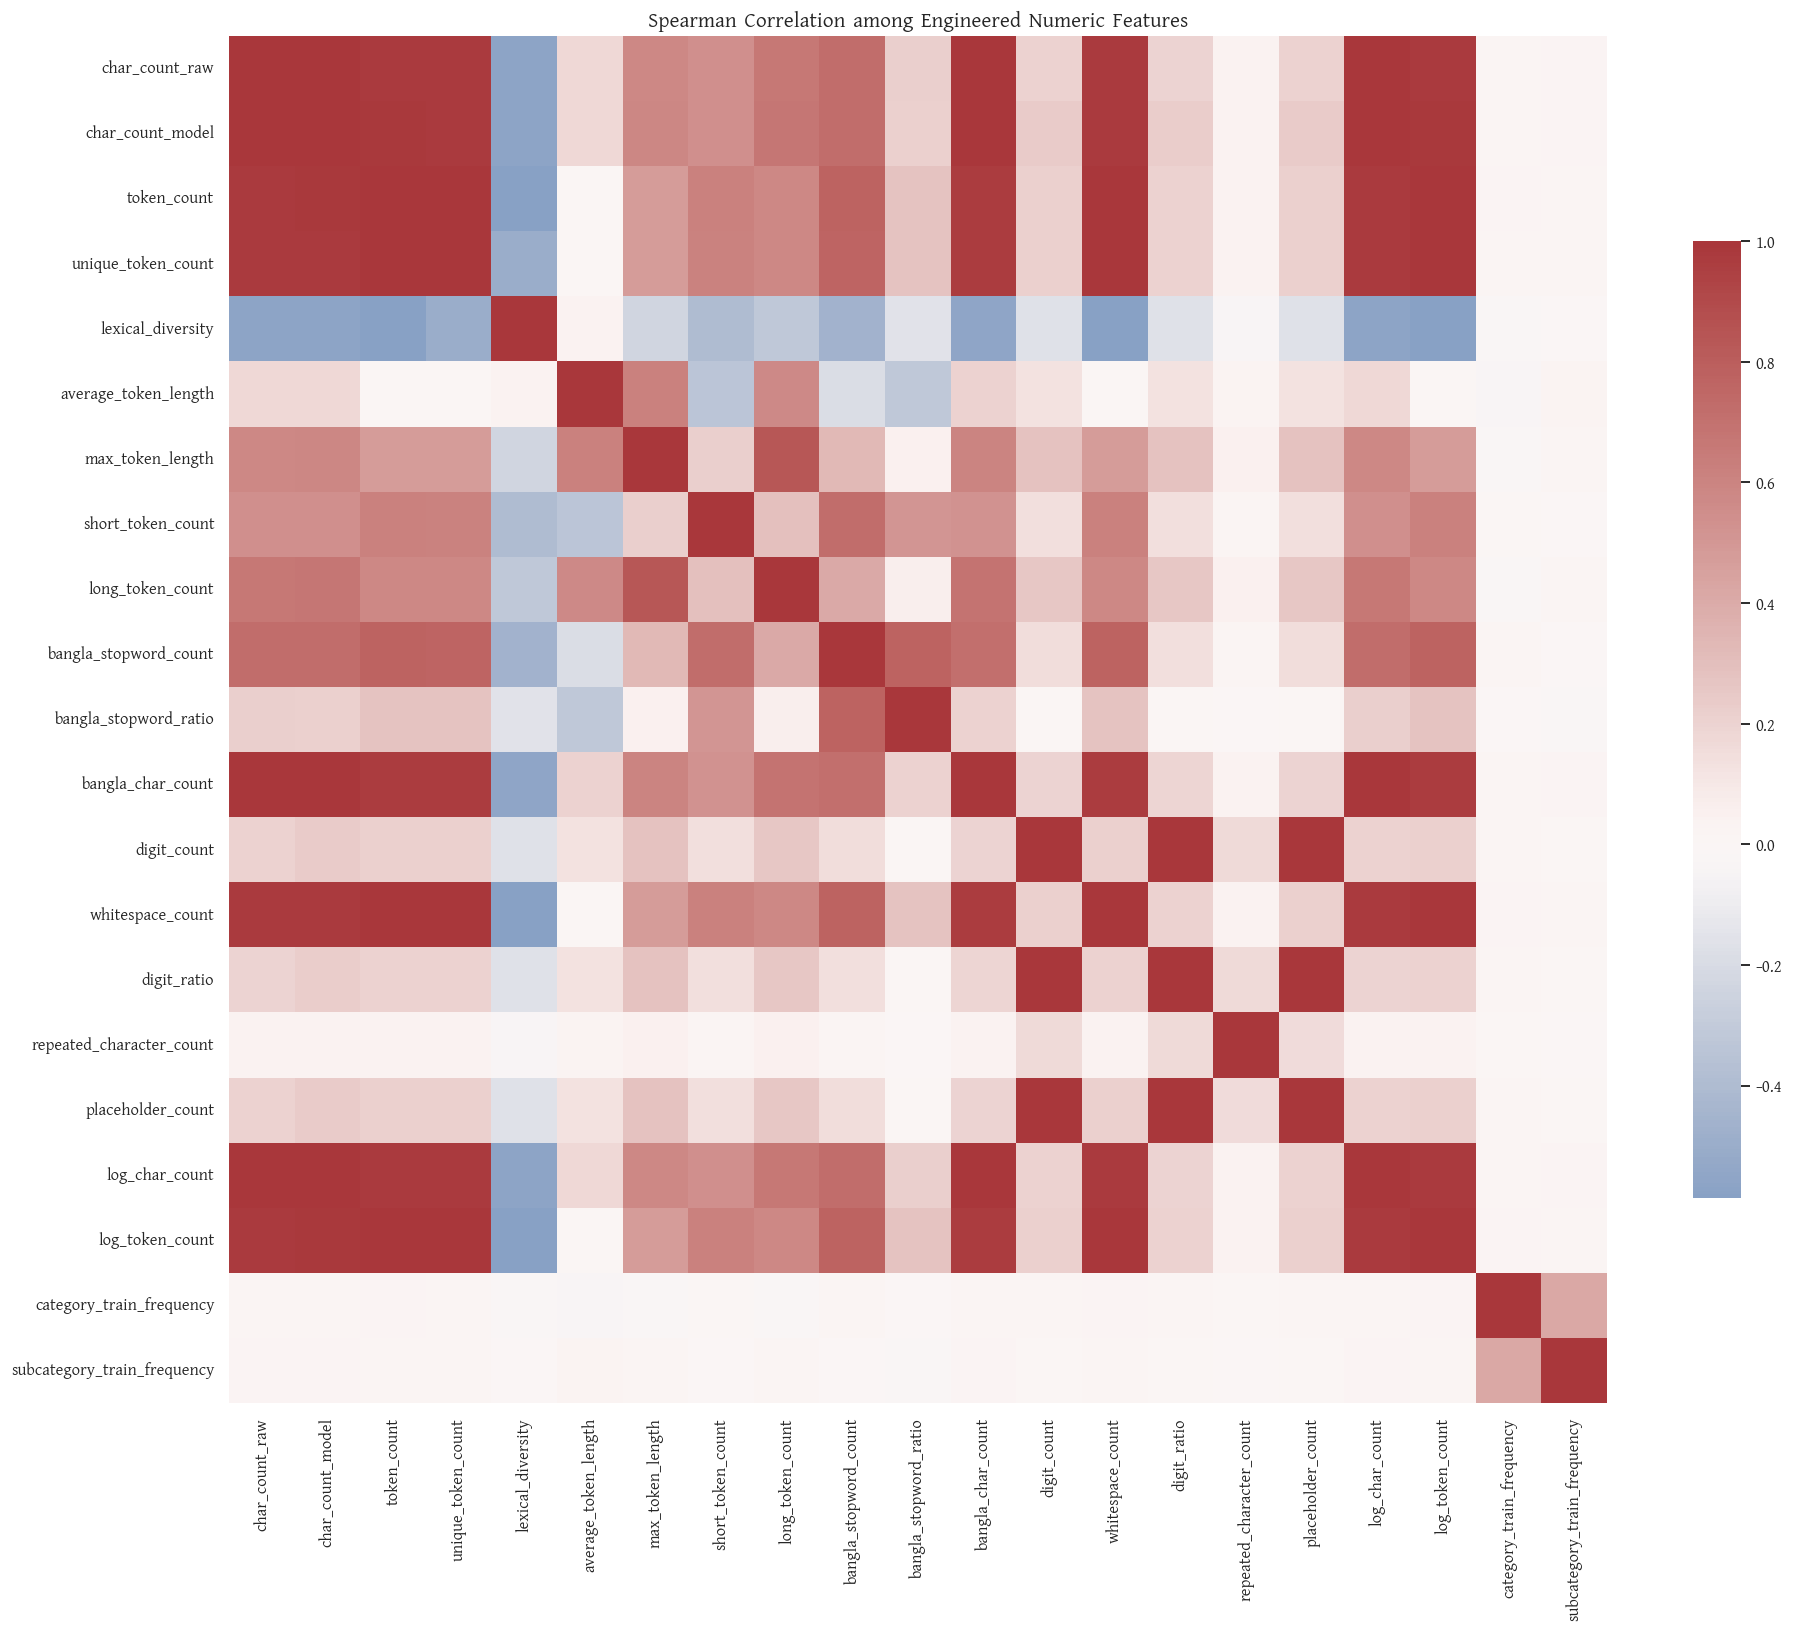

In [51]:
# Visualize correlations among informative handcrafted features with Spearman correlation
nonconstant_numeric_features = feature_audit.index[~feature_audit['is_constant']].tolist()
correlation_matrix = cleaned_splits['train'][nonconstant_numeric_features].corr(method='spearman')

plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, cmap='vlag', center=0, square=False, cbar_kws={'shrink': 0.7})
plt.title('Spearman Correlation among Engineered Numeric Features')
plt.tight_layout()
plt.show()

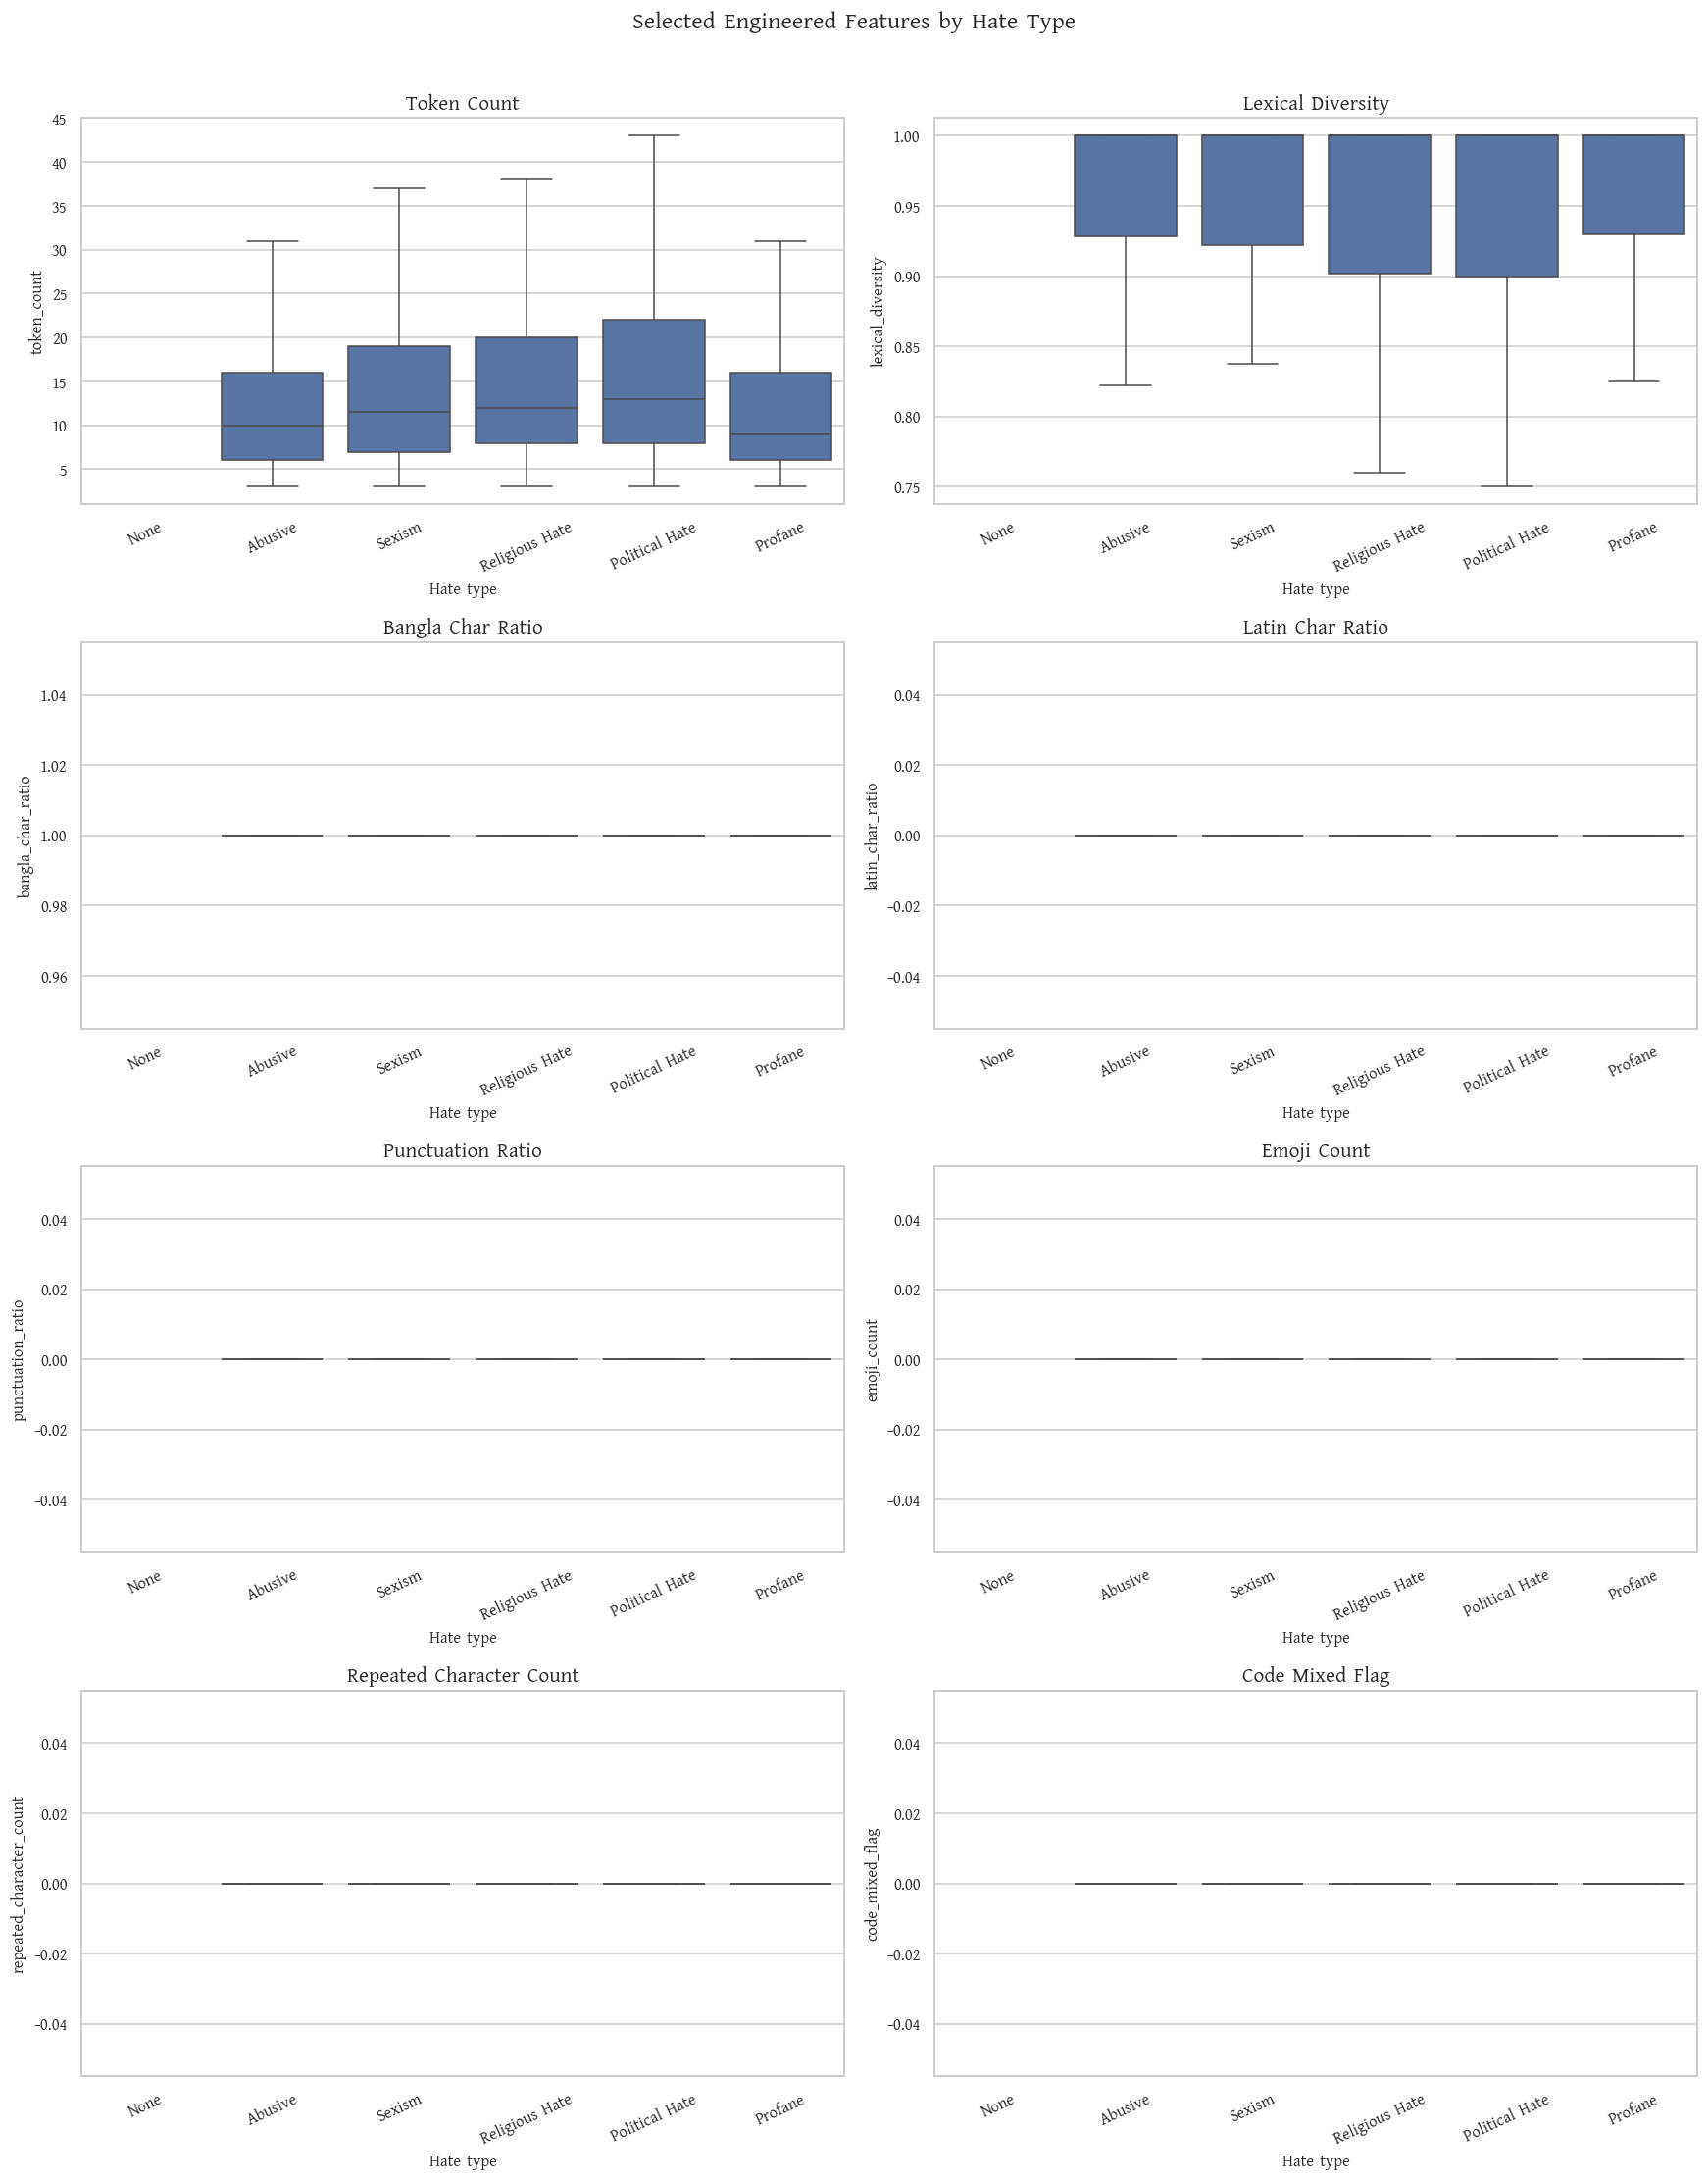

In [52]:
# Compare selected engineered feature distributions across hate-type classes
selected_feature_plots = [
    'token_count', 'lexical_diversity', 'bangla_char_ratio', 'latin_char_ratio',
    'punctuation_ratio', 'emoji_count', 'repeated_character_count', 'code_mixed_flag'
]

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
for axis, feature in zip(axes.flat, selected_feature_plots):
    sns.boxplot(
        data=cleaned_splits['train'], x=TARGET_COL, y=feature,
        order=CLASS_ORDER, showfliers=False, ax=axis
    )
    axis.set_title(feature.replace('_', ' ').title())
    axis.tick_params(axis='x', rotation=25)
    axis.set_xlabel('Hate type')
plt.suptitle('Selected Engineered Features by Hate Type', y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

In [53]:
# Document every engineered feature, its source, interpretation, and intended use
feature_documentation = [
    ('char_count_raw', 'Length', 'Number of Unicode characters in raw comment', 'Captures comment verbosity and short-comment behavior'),
    ('char_count_model', 'Length', 'Characters after conservative normalization', 'Audits normalization and supports compactness analysis'),
    ('token_count', 'Length', 'Number of Bangla/Latin/numeric tokens', 'Text-size feature independent of TF-IDF'),
    ('unique_token_count', 'Lexical', 'Number of unique tokens', 'Vocabulary richness'),
    ('lexical_diversity', 'Lexical', 'Unique tokens divided by total tokens', 'Repetition and lexical variety'),
    ('average_token_length', 'Lexical', 'Mean token length', 'Orthographic style'),
    ('max_token_length', 'Lexical', 'Maximum token length', 'Long compounds, concatenation, or noise'),
    ('short_token_count', 'Lexical', 'Tokens with length <= 2', 'Short informal forms and particles'),
    ('long_token_count', 'Lexical', 'Tokens with length >= 8', 'Long lexical forms and concatenations'),
    ('bangla_stopword_count', 'Lexical', 'Count of EDA stopwords', 'Function-word density'),
    ('bangla_stopword_ratio', 'Lexical', 'Stopword count divided by token count', 'Relative function-word density'),
    ('bangla_char_count', 'Script', 'Bangla-script character count', 'Bangla content volume'),
    ('latin_char_count', 'Script', 'Latin character count', 'English/code-mixed content'),
    ('digit_count', 'Script', 'Digit count', 'Numeric references and obfuscation'),
    ('whitespace_count', 'Formatting', 'Whitespace character count', 'Spacing style'),
    ('punctuation_count', 'Formatting', 'Unicode punctuation count', 'Emphasis and style'),
    ('emoji_count', 'Formatting', 'Emoji/symbol character count', 'Affective and pragmatic cues'),
    ('bangla_char_ratio', 'Script', 'Bangla chars divided by non-space chars', 'Language composition'),
    ('latin_char_ratio', 'Script', 'Latin chars divided by non-space chars', 'Code-mixing intensity'),
    ('digit_ratio', 'Script', 'Digits divided by non-space chars', 'Relative numeric content'),
    ('punctuation_ratio', 'Formatting', 'Punctuation divided by non-space chars', 'Relative emphasis'),
    ('code_mixed_flag', 'Script', '1 when Bangla and Latin characters coexist', 'Code-mixed comment indicator'),
    ('url_count', 'Noise/Context', 'Number of URLs', 'External-link behavior'),
    ('email_count', 'Noise/Context', 'Number of email addresses', 'Contact-information pattern'),
    ('mention_count', 'Noise/Context', 'Number of @mentions', 'Direct targeting cue'),
    ('hashtag_count', 'Noise/Context', 'Number of hashtags', 'Topic and campaign cue'),
    ('exclamation_count', 'Emphasis', 'Number of exclamation marks', 'Emotional emphasis'),
    ('question_count', 'Emphasis', 'Number of question marks', 'Interrogative or rhetorical style'),
    ('bangla_danda_count', 'Formatting', 'Number of Bangla danda marks', 'Bangla sentence-boundary signal'),
    ('newline_count', 'Formatting', 'Number of line breaks', 'Multi-line structure'),
    ('repeated_punctuation_count', 'Emphasis', 'Runs of repeated punctuation', 'Intensification'),
    ('repeated_character_count', 'Emphasis', 'Character runs of length >= 3', 'Elongation and expressive spelling'),
    ('placeholder_count', 'Normalization', 'Count of normalized URL/user/email/number placeholders', 'Amount of replaced noisy content'),
    ('all_caps_latin_token_count', 'Emphasis', 'Uppercase Latin token count', 'Code-mixed shouting cue'),
    ('log_char_count', 'Length', 'log(1 + raw character count)', 'Reduces extreme length skew'),
    ('log_token_count', 'Length', 'log(1 + token count)', 'Reduces extreme token-count skew'),
    ('category_train_frequency', 'Metadata', 'Training frequency of category', 'Optional metadata rarity signal; ablation only'),
    ('subcategory_train_frequency', 'Metadata', 'Training frequency of subcategory', 'Optional metadata rarity signal; ablation only')
]
feature_dictionary_df = pd.DataFrame(
    feature_documentation,
    columns=['feature_name', 'feature_group', 'definition', 'project_relevance']
)
feature_dictionary_df['fitted_using'] = np.where(
    feature_dictionary_df['feature_name'].str.contains('train_frequency'),
    'Training split only',
    'Row-level deterministic transformation'
)
feature_dictionary_df['target_leakage'] = 'No target label used'
display(feature_dictionary_df)

,feature_name,feature_group,definition,project_relevance,fitted_using,target_leakage
0,char_count_raw,Length,Number of Unicode characters in raw comment,Captures comment verbosity and short-comment behavior,Row-level deterministic transformation,No target label used
1,char_count_model,Length,Characters after conservative normalization,Audits normalization and supports compactness analysis,Row-level deterministic transformation,No target label used
2,token_count,Length,Number of Bangla/Latin/numeric tokens,Text-size feature independent of TF-IDF,Row-level deterministic transformation,No target label used
3,unique_token_count,Lexical,Number of unique tokens,Vocabulary richness,Row-level deterministic transformation,No target label used
4,lexical_diversity,Lexical,Unique tokens divided by total tokens,Repetition and lexical variety,Row-level deterministic transformation,No target label used
5,average_token_length,Lexical,Mean token length,Orthographic style,Row-level deterministic transformation,No target label used
6,max_token_length,Lexical,Maximum token length,"Long compounds, concatenation, or noise",Row-level deterministic transformation,No target label used
7,short_token_count,Lexical,Tokens with length <= 2,Short informal forms and particles,Row-level deterministic transformation,No target label used
8,long_token_count,Lexical,Tokens with length >= 8,Long lexical forms and concatenations,Row-level deterministic transformation,No target label used
9,bangla_stopword_count,Lexical,Count of EDA stopwords,Function-word density,Row-level deterministic transformation,No target label used


# **7. Encoding Categorical Variables and Target Labels**

In [54]:
# Encode the six target classes with a fixed documented semantic order
label_to_id = {label: index for index, label in enumerate(CLASS_ORDER)}
id_to_label = {index: label for label, index in label_to_id.items()}

observed_labels = set(cleaned_splits['train'][TARGET_COL].dropna().unique())
unknown_labels = observed_labels - set(CLASS_ORDER)
missing_expected_labels = set(CLASS_ORDER) - observed_labels
if unknown_labels:
    raise ValueError(f'Unexpected target labels found: {sorted(unknown_labels)}')
if missing_expected_labels:
    print('Warning: These expected labels are absent from the training split:', sorted(missing_expected_labels))

for split_name, split_df in cleaned_splits.items():
    split_df['type_of_hate_id'] = split_df[TARGET_COL].map(label_to_id)
    if split_df['type_of_hate_id'].isna().any():
        raise ValueError(f'Unmapped labels remain in {split_name}.')
    split_df['type_of_hate_id'] = split_df['type_of_hate_id'].astype(int)
    cleaned_splits[split_name] = split_df

label_mapping_df = pd.DataFrame({'type_of_hate': CLASS_ORDER, 'type_of_hate_id': range(len(CLASS_ORDER))})
display(label_mapping_df)

,type_of_hate,type_of_hate_id
0,None,0
1,Abusive,1
2,Sexism,2
3,Religious Hate,3
4,Political Hate,4
5,Profane,5


In [55]:
# Fit one-hot encoding for optional metadata features using training data only
METADATA_COLUMNS = ['category', 'subcategory', 'severity_of_hate', 'target_of_hate']
metadata_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True, dtype=np.float32)
metadata_encoder.fit(cleaned_splits['train'][METADATA_COLUMNS])

metadata_matrices = {
    split_name: metadata_encoder.transform(split_df[METADATA_COLUMNS])
    for split_name, split_df in cleaned_splits.items()
}

metadata_feature_names = metadata_encoder.get_feature_names_out(METADATA_COLUMNS)
print('One-hot metadata feature count:', len(metadata_feature_names))
for split_name, matrix in metadata_matrices.items():
    print(split_name, matrix.shape)

One-hot metadata feature count: 113
train (15568, 113)
dev (2126, 113)
test (4449, 113)


In [56]:
# Verify that unseen development or test metadata values are handled without errors
unseen_metadata_records = []
for column_index, column in enumerate(METADATA_COLUMNS):
    train_values = set(cleaned_splits['train'][column].astype(str))
    for split_name in ['dev', 'test']:
        comparison_values = set(cleaned_splits[split_name][column].astype(str))
        unseen_values = comparison_values - train_values
        unseen_metadata_records.append({
            'column': column,
            'split': split_name,
            'unseen_value_count': len(unseen_values),
            'sample_unseen_values': sorted(unseen_values)[:10]
        })
unseen_metadata_df = pd.DataFrame(unseen_metadata_records)
display(unseen_metadata_df)

,column,split,unseen_value_count,sample_unseen_values
0,category,dev,0,[]
1,category,test,1,[Technology]
2,subcategory,dev,2,"[আমাদে্র মা, বিনোদন প্রতিদিন]"
3,subcategory,test,3,"[Lawhe Mahfuz, টেক চেক, মহানায়কের মহাজীবন]"
4,severity_of_hate,dev,0,[]
5,severity_of_hate,test,0,[]
6,target_of_hate,dev,0,[]
7,target_of_hate,test,0,[]


# **8. Numeric Normalization and Scaling**

In [57]:
# Remove constant numeric features and fit a RobustScaler using only the training split
FINAL_NUMERIC_FEATURES = [
    feature for feature in NUMERIC_FEATURE_COLUMNS
    if cleaned_splits['train'][feature].nunique(dropna=False) > 1
]
constant_numeric_features = sorted(set(NUMERIC_FEATURE_COLUMNS) - set(FINAL_NUMERIC_FEATURES))
print('Constant numeric features excluded:', constant_numeric_features)

numeric_scaler = RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0))
numeric_scaler.fit(cleaned_splits['train'][FINAL_NUMERIC_FEATURES])

scaled_numeric_arrays = {
    split_name: numeric_scaler.transform(split_df[FINAL_NUMERIC_FEATURES]).astype(np.float32)
    for split_name, split_df in cleaned_splits.items()
}

for split_name, array in scaled_numeric_arrays.items():
    print(split_name, array.shape, 'finite:', bool(np.isfinite(array).all()))

Constant numeric features excluded: ['all_caps_latin_token_count', 'bangla_char_ratio', 'bangla_danda_count', 'code_mixed_flag', 'email_count', 'emoji_count', 'exclamation_count', 'hashtag_count', 'latin_char_count', 'latin_char_ratio', 'mention_count', 'newline_count', 'punctuation_count', 'punctuation_ratio', 'question_count', 'repeated_punctuation_count', 'url_count']
train (15568, 21) finite: True
dev (2126, 21) finite: True
test (4449, 21) finite: True


,raw_median,raw_iqr,scaled_median,scaled_iqr
char_count_raw,59.0,66.25,0.0,1.0
char_count_model,61.0,67.0,0.0,1.0
token_count,11.0,11.0,0.0,1.0
unique_token_count,10.0,11.0,0.0,1.0
lexical_diversity,1.0,0.083333,0.0,1.0
average_token_length,4.780869,0.980455,0.0,1.0
max_token_length,8.0,3.0,0.0,1.0
short_token_count,1.0,2.0,0.0,1.0
long_token_count,1.0,2.0,0.0,1.0
bangla_stopword_count,2.0,3.0,0.0,1.0


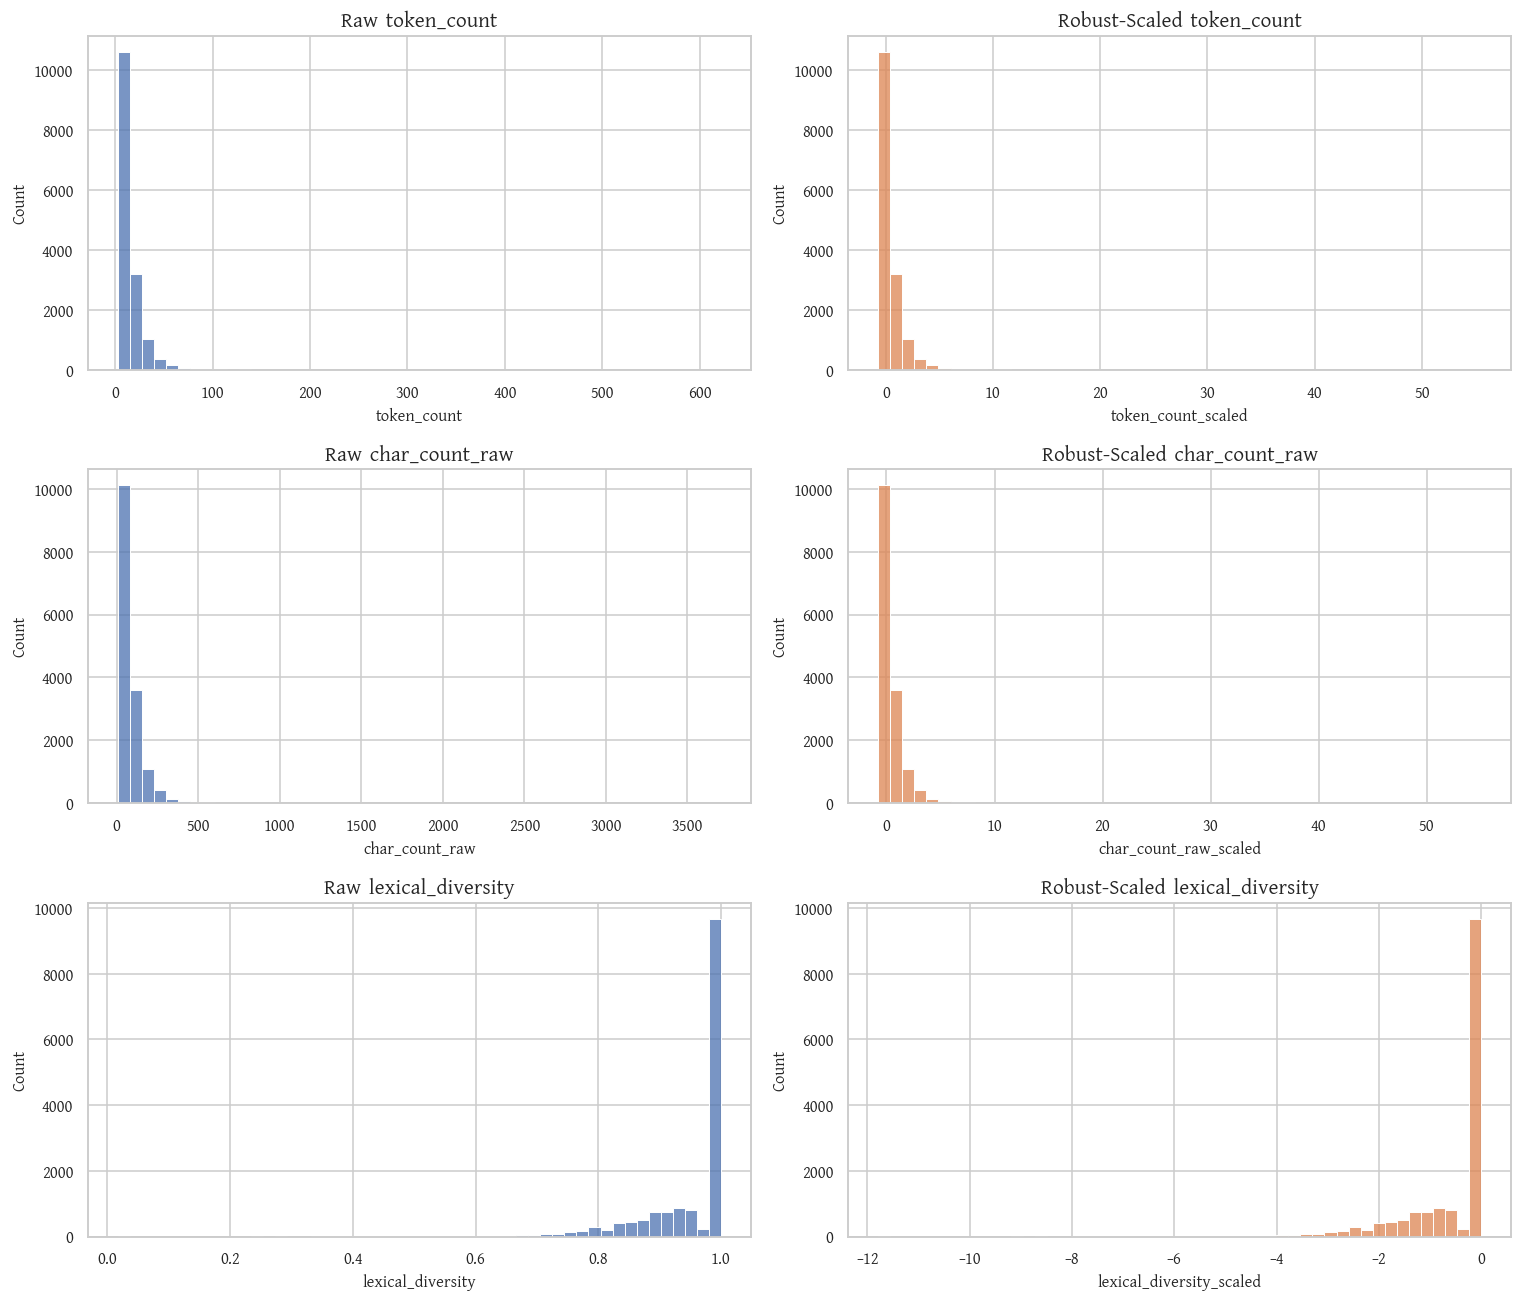

In [58]:
# Compare numeric distributions before and after robust scaling
scaled_train_df = pd.DataFrame(
    scaled_numeric_arrays['train'],
    columns=[f'{feature}_scaled' for feature in FINAL_NUMERIC_FEATURES]
)

scaling_comparison = pd.DataFrame({
    'raw_median': cleaned_splits['train'][FINAL_NUMERIC_FEATURES].median(),
    'raw_iqr': cleaned_splits['train'][FINAL_NUMERIC_FEATURES].quantile(0.75) - cleaned_splits['train'][FINAL_NUMERIC_FEATURES].quantile(0.25),
    'scaled_median': scaled_train_df.median().values,
    'scaled_iqr': (scaled_train_df.quantile(0.75) - scaled_train_df.quantile(0.25)).values
})
display(scaling_comparison.head(20))

comparison_features = [feature for feature in ['token_count', 'char_count_raw', 'punctuation_ratio', 'lexical_diversity'] if feature in FINAL_NUMERIC_FEATURES]
fig, axes = plt.subplots(len(comparison_features), 2, figsize=(14, 4 * max(len(comparison_features), 1)))
if len(comparison_features) == 1:
    axes = np.array([axes])
for row_index, feature in enumerate(comparison_features):
    sns.histplot(cleaned_splits['train'][feature], bins=50, ax=axes[row_index, 0], color=sns.color_palette()[0])
    axes[row_index, 0].set_title(f'Raw {feature}')
    scaled_col = f'{feature}_scaled'
    sns.histplot(scaled_train_df[scaled_col], bins=50, ax=axes[row_index, 1], color=sns.color_palette()[1])
    axes[row_index, 1].set_title(f'Robust-Scaled {feature}')
plt.tight_layout()
plt.show()

# **9. Text Feature Engineering**

## **9.1 Word and Character TF-IDF**

Two complementary text representations are prepared:

- **Word TF-IDF:** interpretable unigrams and bigrams for later SHAP/LIME analysis.
- **Character TF-IDF:** 3–5 character sequences that are robust to spelling variation, informal Bangla, concatenation, and obfuscation.

Both vectorizers are fitted on the training split only and use L2 normalization internally.

In [59]:
# Fit word-level TF-IDF on training text and transform development and test text without leakage
WORD_TFIDF_MAX_FEATURES = 30000
word_tfidf = TfidfVectorizer(
    tokenizer=simple_bangla_tokenize,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.995,
    max_features=WORD_TFIDF_MAX_FEATURES,
    sublinear_tf=True,
    norm='l2',
    dtype=np.float32
)
word_tfidf.fit(cleaned_splits['train']['text_model'])

word_tfidf_matrices = {
    split_name: word_tfidf.transform(split_df['text_model'])
    for split_name, split_df in cleaned_splits.items()
}
print('Word TF-IDF vocabulary size:', len(word_tfidf.get_feature_names_out()))
for split_name, matrix in word_tfidf_matrices.items():
    print(split_name, matrix.shape, 'density:', matrix.nnz / max(matrix.shape[0] * matrix.shape[1], 1))

Word TF-IDF vocabulary size: 30000
train (15568, 30000) density: 0.0005908765844467284
dev (2126, 30000) density: 0.0005246472248353716
test (4449, 30000) density: 0.0005279014010639095


In [60]:
# Fit character-level TF-IDF to capture spelling variation, obfuscation, and informal Bangla morphology
CHAR_TFIDF_MAX_FEATURES = 20000
char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.995,
    max_features=CHAR_TFIDF_MAX_FEATURES,
    sublinear_tf=True,
    norm='l2',
    dtype=np.float32
)
char_tfidf.fit(cleaned_splits['train']['text_model'])

char_tfidf_matrices = {
    split_name: char_tfidf.transform(split_df['text_model'])
    for split_name, split_df in cleaned_splits.items()
}
print('Character TF-IDF vocabulary size:', len(char_tfidf.get_feature_names_out()))
for split_name, matrix in char_tfidf_matrices.items():
    print(split_name, matrix.shape, 'density:', matrix.nnz / max(matrix.shape[0] * matrix.shape[1], 1))

Character TF-IDF vocabulary size: 20000
train (15568, 20000) density: 0.006825876798561151
dev (2126, 20000) density: 0.006684336782690498
test (4449, 20000) density: 0.006756035064059339


In [61]:
# Inspect TF-IDF normalization and the most globally weighted interpretable word features
word_feature_names = np.asarray(word_tfidf.get_feature_names_out())
train_word_mean_tfidf = np.asarray(word_tfidf_matrices['train'].mean(axis=0)).ravel()
top_indices = train_word_mean_tfidf.argsort()[::-1][:30]
top_mean_tfidf_df = pd.DataFrame({
    'feature': word_feature_names[top_indices],
    'mean_training_tfidf': train_word_mean_tfidf[top_indices]
})
display(top_mean_tfidf_df)

row_norms = sparse.linalg.norm(word_tfidf_matrices['train'], axis=1)
print('Word TF-IDF row-norm summary:')
display(pd.Series(np.asarray(row_norms).ravel()).describe())

,feature,mean_training_tfidf
0,না,0.018530
1,করে,0.014134
2,এই,0.013560
3,আর,0.012400
4,কি,0.012027
5,হবে,0.009912
6,সময়,0.009229
7,কে,0.008555
8,সব,0.008445
9,তো,0.007715


Word TF-IDF row-norm summary:


count    15568.000000
mean         0.999807
std          0.013881
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
dtype: float64

## **9.2 Compact SVD Features for Visualization and Optional Classical Models**

In [62]:
# Fit a compact Truncated SVD representation on combined training TF-IDF features
combined_text_train = sparse.hstack(
    [word_tfidf_matrices['train'], char_tfidf_matrices['train']],
    format='csr', dtype=np.float32
)

max_valid_components = max(2, min(100, combined_text_train.shape[0] - 1, combined_text_train.shape[1] - 1))
SVD_COMPONENTS = max_valid_components
text_svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=SEED)
text_svd.fit(combined_text_train)

svd_feature_arrays = {}
for split_name in cleaned_splits:
    combined_matrix = sparse.hstack(
        [word_tfidf_matrices[split_name], char_tfidf_matrices[split_name]],
        format='csr', dtype=np.float32
    )
    svd_feature_arrays[split_name] = text_svd.transform(combined_matrix).astype(np.float32)

print('SVD components:', SVD_COMPONENTS)
print('Cumulative explained variance:', float(text_svd.explained_variance_ratio_.sum()))

SVD components: 100
Cumulative explained variance: 0.1563422977924347


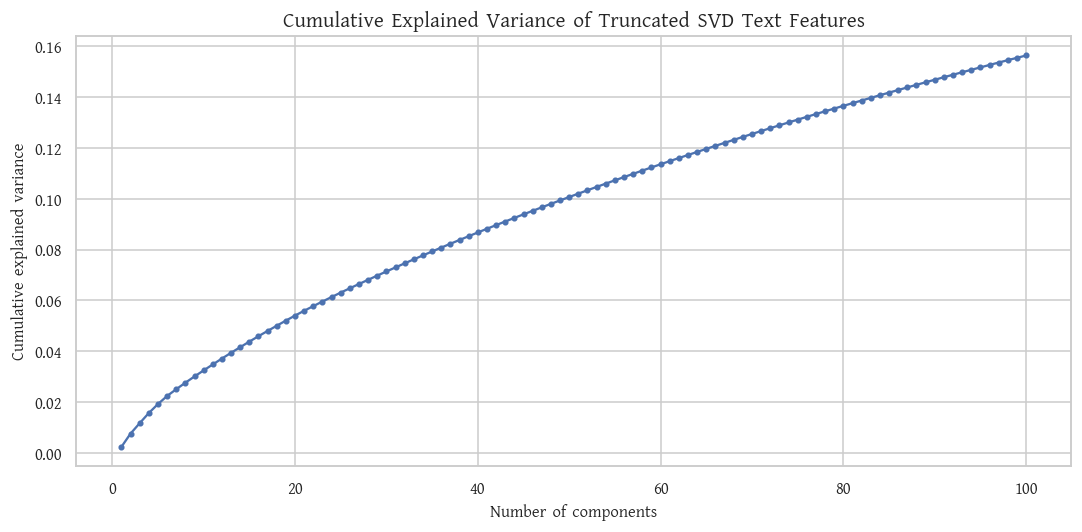

In [63]:
# Plot cumulative explained variance of the compact SVD text representation
cumulative_variance = np.cumsum(text_svd.explained_variance_ratio_)
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', markersize=3)
plt.title('Cumulative Explained Variance of Truncated SVD Text Features')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.tight_layout()
plt.show()

# **10. Construction of Reusable Feature Sets**

Three feature sets are prepared for later model comparison:

1. **Text only:** word TF-IDF + character TF-IDF.
2. **Text + numeric:** text features plus robust-scaled handcrafted features. This is the recommended primary classical-ML feature set.
3. **Text + numeric + metadata:** includes one-hot category, subcategory, severity, and target metadata. Use only as an ablation because metadata may create shortcuts and may not be available during real-world inference.

In [64]:
# Combine sparse text, scaled numeric, and optional metadata features for every split
feature_matrices = {}
for split_name in cleaned_splits:
    text_matrix = sparse.hstack(
        [word_tfidf_matrices[split_name], char_tfidf_matrices[split_name]],
        format='csr', dtype=np.float32
    )
    numeric_matrix = sparse.csr_matrix(scaled_numeric_arrays[split_name], dtype=np.float32)
    text_numeric_matrix = sparse.hstack([text_matrix, numeric_matrix], format='csr', dtype=np.float32)
    all_features_matrix = sparse.hstack(
        [text_numeric_matrix, metadata_matrices[split_name]],
        format='csr', dtype=np.float32
    )

    feature_matrices[split_name] = {
        'text_only': text_matrix,
        'text_numeric': text_numeric_matrix,
        'text_numeric_metadata': all_features_matrix
    }

for split_name, matrices in feature_matrices.items():
    print(f'\n{split_name.upper()} FEATURE MATRICES')
    for feature_set_name, matrix in matrices.items():
        print(f'{feature_set_name:>22}: shape={matrix.shape}, nnz={matrix.nnz:,}')


TRAIN FEATURE MATRICES
             text_only: shape=(15568, 50000), nnz=2,401,268
          text_numeric: shape=(15568, 50021), nnz=2,635,875
 text_numeric_metadata: shape=(15568, 50134), nnz=2,698,147

DEV FEATURE MATRICES
             text_only: shape=(2126, 50000), nnz=317,680
          text_numeric: shape=(2126, 50021), nnz=349,784
 text_numeric_metadata: shape=(2126, 50134), nnz=358,286

TEST FEATURE MATRICES
             text_only: shape=(4449, 50000), nnz=671,611
          text_numeric: shape=(4449, 50021), nnz=738,566
 text_numeric_metadata: shape=(4449, 50134), nnz=756,358


In [65]:
# Create a feature-set manifest that documents dimensions and recommended experimental use
feature_set_manifest_records = []
for split_name, matrices in feature_matrices.items():
    for feature_set_name, matrix in matrices.items():
        feature_set_manifest_records.append({
            'split': split_name,
            'feature_set': feature_set_name,
            'rows': matrix.shape[0],
            'columns': matrix.shape[1],
            'nonzero_values': matrix.nnz,
            'density': matrix.nnz / max(matrix.shape[0] * matrix.shape[1], 1),
            'recommended_use': {
                'text_only': 'Transparent text baseline',
                'text_numeric': 'Primary classical-ML feature set',
                'text_numeric_metadata': 'Optional metadata ablation only'
            }[feature_set_name]
        })
feature_set_manifest_df = pd.DataFrame(feature_set_manifest_records)
display(feature_set_manifest_df)

,split,feature_set,rows,columns,nonzero_values,density,recommended_use
0,train,text_only,15568,50000,2401268,0.003085,Transparent text baseline
1,train,text_numeric,15568,50021,2635875,0.003385,Primary classical-ML feature set
2,train,text_numeric_metadata,15568,50134,2698147,0.003457,Optional metadata ablation only
3,dev,text_only,2126,50000,317680,0.002989,Transparent text baseline
4,dev,text_numeric,2126,50021,349784,0.003289,Primary classical-ML feature set
5,dev,text_numeric_metadata,2126,50134,358286,0.003362,Optional metadata ablation only
6,test,text_only,4449,50000,671611,0.003019,Transparent text baseline
7,test,text_numeric,4449,50021,738566,0.003319,Primary classical-ML feature set
8,test,text_numeric_metadata,4449,50134,756358,0.003391,Optional metadata ablation only


In [66]:
# Calculate training-only class weights for the imbalance-aware modeling phase without resampling dev or test data
train_labels = cleaned_splits['train']['type_of_hate_id'].to_numpy()
present_class_ids = np.sort(np.unique(train_labels))
class_weight_values = compute_class_weight(class_weight='balanced', classes=present_class_ids, y=train_labels)
class_weight_by_id = {int(class_id): float(weight) for class_id, weight in zip(present_class_ids, class_weight_values)}
class_weight_by_label = {id_to_label[class_id]: weight for class_id, weight in class_weight_by_id.items()}

class_weight_df = pd.DataFrame({
    'type_of_hate': [id_to_label[class_id] for class_id in present_class_ids],
    'class_id': present_class_ids,
    'training_count': [int((train_labels == class_id).sum()) for class_id in present_class_ids],
    'balanced_class_weight': class_weight_values
})
display(class_weight_df)

print('No oversampling is applied in Phase 3. Any resampling must occur only inside the training fold during modeling.')

,type_of_hate,class_id,training_count,balanced_class_weight
0,Abusive,1,8212,0.379152
1,Sexism,2,122,25.521311
2,Religious Hate,3,676,4.605917
3,Political Hate,4,4227,0.736598
4,Profane,5,2331,1.335736


No oversampling is applied in Phase 3. Any resampling must occur only inside the training fold during modeling.


# **11. Post-Transformation EDA and Quality Diagnostics**

,split,raw_mean_chars,model_mean_chars,mean_change_chars,median_retention_ratio,unchanged_rows_percent
0,train,88.098214,89.945015,1.846801,1.0,51.413155
1,dev,84.897930,86.769991,1.872060,1.0,51.128881
2,test,86.307934,88.102045,1.794111,1.0,50.078669


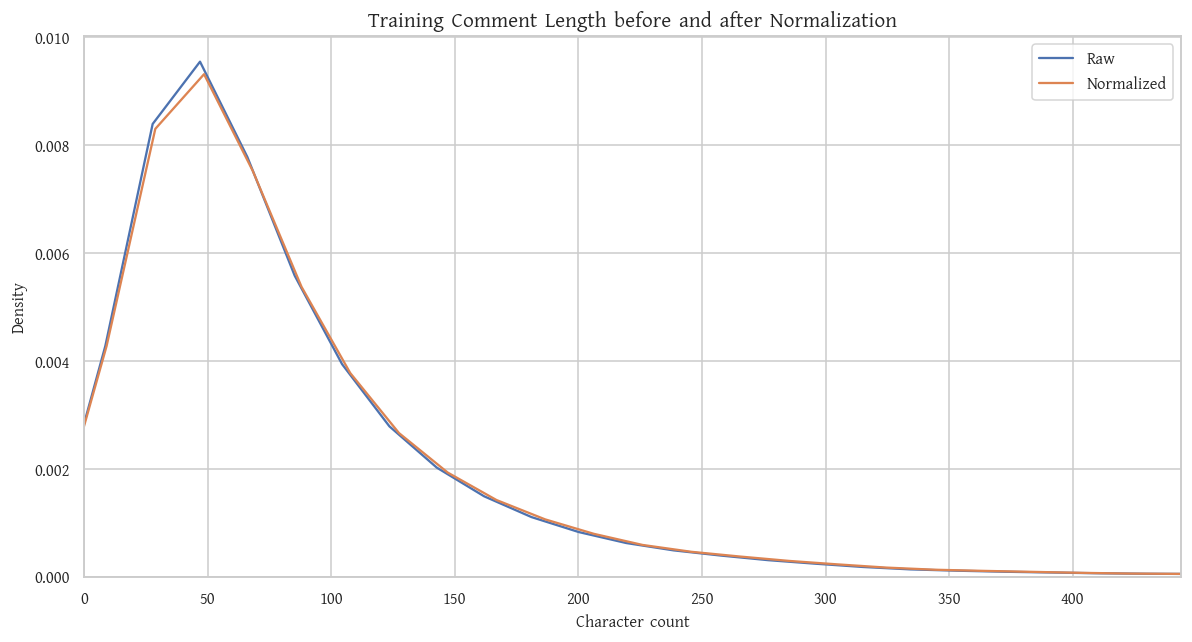

In [67]:
# Compare raw and normalized text lengths to detect excessive information removal
length_comparison_records = []
for split_name, split_df in cleaned_splits.items():
    raw_lengths = split_df['text_raw'].str.len()
    model_lengths = split_df['text_model'].str.len()
    length_comparison_records.append({
        'split': split_name,
        'raw_mean_chars': raw_lengths.mean(),
        'model_mean_chars': model_lengths.mean(),
        'mean_change_chars': (model_lengths - raw_lengths).mean(),
        'median_retention_ratio': (model_lengths / raw_lengths.replace(0, np.nan)).median(),
        'unchanged_rows_percent': split_df['text_raw'].eq(split_df['text_model']).mean() * 100
    })
length_comparison_df = pd.DataFrame(length_comparison_records)
display(length_comparison_df)

train_length_compare = pd.DataFrame({
    'raw_length': cleaned_splits['train']['text_raw'].str.len(),
    'normalized_length': cleaned_splits['train']['text_model'].str.len()
})
plt.figure(figsize=(11, 6))
sns.kdeplot(train_length_compare['raw_length'], label='Raw', fill=False, color=sns.color_palette()[0])
sns.kdeplot(train_length_compare['normalized_length'], label='Normalized', fill=False, color=sns.color_palette()[1])
plt.xlim(0, train_length_compare['raw_length'].quantile(0.99))
plt.title('Training Comment Length before and after Normalization')
plt.xlabel('Character count')
plt.legend()
plt.tight_layout()
plt.show()

Change in class percentage points after cleaning:


type_of_hate,None,Abusive,Sexism,Religious Hate,Political Hate,Profane
split,,,,,,
dev,-57.6831,30.1982,0.5155,2.1163,15.5739,9.2792
test,-56.3824,29.3001,0.3675,2.2685,15.4611,8.9852
train,-56.1736,29.6312,0.4402,2.4392,15.2522,8.4109


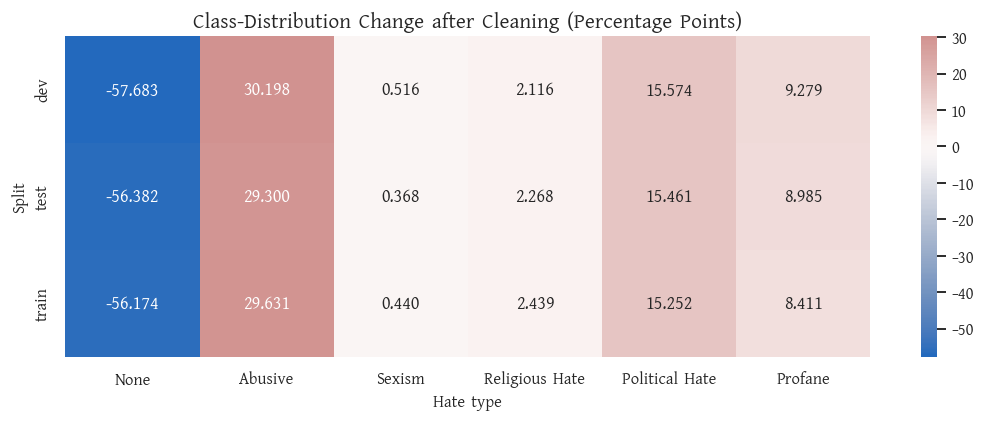

In [68]:
# Confirm that cleaning did not unintentionally alter class proportions
before_distribution = pd.crosstab(raw_all_df[SPLIT_COL], raw_all_df[TARGET_COL], normalize='index').reindex(columns=CLASS_ORDER, fill_value=0)
after_distribution = pd.crosstab(cleaned_all_df[SPLIT_COL], cleaned_all_df[TARGET_COL], normalize='index').reindex(columns=CLASS_ORDER, fill_value=0)
class_distribution_change = (after_distribution - before_distribution).mul(100)

print('Change in class percentage points after cleaning:')
display(class_distribution_change.round(4))

plt.figure(figsize=(10, 4))
sns.heatmap(class_distribution_change, annot=True, fmt='.3f', center=0, cmap='vlag')
plt.title('Class-Distribution Change after Cleaning (Percentage Points)')
plt.xlabel('Hate type')
plt.ylabel('Split')
plt.tight_layout()
plt.show()

In [69]:
# Measure numeric feature shift from training to development and test with standardized median differences
numeric_shift_records = []
train_numeric = cleaned_splits['train'][FINAL_NUMERIC_FEATURES]
train_medians = train_numeric.median()
train_iqrs = train_numeric.quantile(0.75) - train_numeric.quantile(0.25)

for split_name in ['dev', 'test']:
    split_medians = cleaned_splits[split_name][FINAL_NUMERIC_FEATURES].median()
    standardized_shift = (split_medians - train_medians) / train_iqrs.replace(0, np.nan)
    for feature, value in standardized_shift.items():
        numeric_shift_records.append({
            'feature': feature,
            'comparison': f'train vs {split_name}',
            'median_shift_in_training_iqr_units': float(value) if pd.notna(value) else 0.0
        })

numeric_shift_df = pd.DataFrame(numeric_shift_records)
display(numeric_shift_df.reindex(numeric_shift_df['median_shift_in_training_iqr_units'].abs().sort_values(ascending=False).index).head(30))

,feature,comparison,median_shift_in_training_iqr_units
27,max_token_length,train vs test,0.333333
24,unique_token_count,train vs test,0.090909
31,bangla_stopword_ratio,train vs test,0.035365
38,log_char_count,train vs test,0.031952
21,char_count_raw,train vs test,0.030189
5,average_token_length,train vs dev,-0.021285
32,bangla_char_count,train vs test,0.018519
17,log_char_count,train vs dev,0.016107
10,bangla_stopword_ratio,train vs dev,-0.015804
0,char_count_raw,train vs dev,0.015094


In [70]:
# Run a leakage-prevention checklist for all preprocessing and feature-engineering operations
leakage_checklist_df = pd.DataFrame([
    ('Official splits loaded separately', True, 'Train, dev, and test are never randomly re-split in this notebook.'),
    ('Target encoding uses fixed mapping', True, 'Mapping is predefined and not inferred from test frequencies.'),
    ('Metadata encoder fitted on train only', hasattr(metadata_encoder, 'categories_'), 'Unknown dev/test values are ignored safely.'),
    ('Numeric scaler fitted on train only', hasattr(numeric_scaler, 'center_'), 'Dev/test medians are not used.'),
    ('Word TF-IDF fitted on train only', hasattr(word_tfidf, 'vocabulary_'), 'Dev/test vocabulary is excluded.'),
    ('Character TF-IDF fitted on train only', hasattr(char_tfidf, 'vocabulary_'), 'Dev/test character n-grams are excluded.'),
    ('SVD fitted on train only', hasattr(text_svd, 'components_'), 'Projection is learned from training text only.'),
    ('No target-derived input features', True, 'The target ID is saved separately from model inputs.'),
    ('No dev/test oversampling', True, 'Class weights are calculated only from training labels.'),
    ('Cross-split duplicates reported', True, 'Potential overlap is visible rather than silently hidden.')
], columns=['check', 'passed', 'evidence'])
display(leakage_checklist_df)
assert leakage_checklist_df['passed'].all(), 'One or more leakage-prevention checks failed.'

,check,passed,evidence
0,Official splits loaded separately,True,"Train, dev, and test are never randomly re-split in this notebook."
1,Target encoding uses fixed mapping,True,Mapping is predefined and not inferred from test frequencies.
2,Metadata encoder fitted on train only,True,Unknown dev/test values are ignored safely.
3,Numeric scaler fitted on train only,True,Dev/test medians are not used.
4,Word TF-IDF fitted on train only,True,Dev/test vocabulary is excluded.
5,Character TF-IDF fitted on train only,True,Dev/test character n-grams are excluded.
6,SVD fitted on train only,True,Projection is learned from training text only.
7,No target-derived input features,True,The target ID is saved separately from model inputs.
8,No dev/test oversampling,True,Class weights are calculated only from training labels.
9,Cross-split duplicates reported,True,Potential overlap is visible rather than silently hidden.


# **12. Export Cleaned Data, Feature Matrices, and Reusable Artifacts**

In [71]:
# Save cleaned split tables in CSV and Parquet formats when the required Parquet engine is available
export_columns = [
    'id', 'text_raw', 'text_model', 'text_lexical', 'text_eda_no_stopwords',
    'category', 'subcategory', 'severity_of_hate', 'target_of_hate',
    TARGET_COL, 'type_of_hate_id', SPLIT_COL
] + NUMERIC_FEATURE_COLUMNS

saved_dataset_paths = []
for split_name, split_df in cleaned_splits.items():
    export_df = split_df[export_columns].copy()
    csv_path = CLEAN_DATA_DIR / f'banglamultihate_{split_name}_phase3_clean.csv'
    export_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
    saved_dataset_paths.append(csv_path)

    parquet_path = CLEAN_DATA_DIR / f'banglamultihate_{split_name}_phase3_clean.parquet'
    try:
        export_df.to_parquet(parquet_path, index=False)
        saved_dataset_paths.append(parquet_path)
    except Exception as parquet_error:
        print(f'Parquet export skipped for {split_name}: {type(parquet_error).__name__}')

print('Saved cleaned datasets:')
for path in saved_dataset_paths:
    print('-', path)

Saved cleaned datasets:
- phase3_outputs\cleaned_data\banglamultihate_train_phase3_clean.csv
- phase3_outputs\cleaned_data\banglamultihate_train_phase3_clean.parquet
- phase3_outputs\cleaned_data\banglamultihate_dev_phase3_clean.csv
- phase3_outputs\cleaned_data\banglamultihate_dev_phase3_clean.parquet
- phase3_outputs\cleaned_data\banglamultihate_test_phase3_clean.csv
- phase3_outputs\cleaned_data\banglamultihate_test_phase3_clean.parquet


In [72]:
# Save fitted encoders, scalers, vectorizers, SVD model, mappings, and feature documentation
joblib.dump(metadata_encoder, ARTIFACT_DIR / 'metadata_onehot_encoder.joblib')
joblib.dump(numeric_scaler, ARTIFACT_DIR / 'numeric_robust_scaler.joblib')
joblib.dump(word_tfidf, ARTIFACT_DIR / 'word_tfidf_vectorizer.joblib')
joblib.dump(char_tfidf, ARTIFACT_DIR / 'char_tfidf_vectorizer.joblib')
joblib.dump(text_svd, ARTIFACT_DIR / 'text_truncated_svd.joblib')

with open(ARTIFACT_DIR / 'label_mapping.json', 'w', encoding='utf-8') as file:
    json.dump({'label_to_id': label_to_id, 'id_to_label': id_to_label}, file, ensure_ascii=False, indent=2)

with open(ARTIFACT_DIR / 'class_weights.json', 'w', encoding='utf-8') as file:
    json.dump(class_weight_by_label, file, ensure_ascii=False, indent=2)

feature_dictionary_df.to_csv(REPORT_DIR / 'feature_dictionary.csv', index=False, encoding='utf-8-sig')
feature_set_manifest_df.to_csv(REPORT_DIR / 'feature_set_manifest.csv', index=False, encoding='utf-8-sig')
cleaning_audit_df.to_csv(REPORT_DIR / 'cleaning_audit.csv', index=False, encoding='utf-8-sig')
distribution_shift_df.to_csv(REPORT_DIR / 'categorical_distribution_shift.csv', index=False, encoding='utf-8-sig')

print('Reusable preprocessing artifacts saved successfully.')

Reusable preprocessing artifacts saved successfully.


In [73]:
# Save sparse feature matrices and target arrays for the later modeling phase
if BUILD_FULL_SPARSE_FEATURES:
    for split_name, matrices in feature_matrices.items():
        for feature_set_name, matrix in matrices.items():
            sparse.save_npz(FEATURE_DIR / f'{split_name}_{feature_set_name}.npz', matrix)

        np.save(FEATURE_DIR / f'{split_name}_labels.npy', cleaned_splits[split_name]['type_of_hate_id'].to_numpy(dtype=np.int64))
        np.save(FEATURE_DIR / f'{split_name}_svd_features.npy', svd_feature_arrays[split_name])
        np.save(FEATURE_DIR / f'{split_name}_row_ids.npy', cleaned_splits[split_name]['id'].astype(str).to_numpy())

    print('Sparse feature matrices and label arrays saved.')
else:
    print('Full sparse feature export was disabled by configuration.')

Sparse feature matrices and label arrays saved.


In [74]:
# Create a machine-readable Phase 3 manifest containing dataset, feature, and environment details
phase3_manifest = {
    'project_title': PROJECT_TITLE,
    'dataset_repository': DATASET_REPOSITORY,
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'random_seed': SEED,
    'target_column': TARGET_COL,
    'class_order': CLASS_ORDER,
    'split_rows_after_cleaning': {name: int(len(frame)) for name, frame in cleaned_splits.items()},
    'dataset_fingerprints': fingerprint_records,
    'numeric_feature_count': len(FINAL_NUMERIC_FEATURES),
    'word_tfidf_feature_count': len(word_tfidf.get_feature_names_out()),
    'character_tfidf_feature_count': len(char_tfidf.get_feature_names_out()),
    'metadata_feature_count': len(metadata_feature_names),
    'svd_components': SVD_COMPONENTS,
    'class_weights': class_weight_by_label,
    'python_version': platform.python_version(),
    'pandas_version': pd.__version__,
    'numpy_version': np.__version__
}

with open(OUTPUT_DIR / 'phase3_manifest.json', 'w', encoding='utf-8') as file:
    json.dump(phase3_manifest, file, ensure_ascii=False, indent=2)

print(json.dumps(phase3_manifest, ensure_ascii=False, indent=2)[:3000])

{
  "project_title": "Explainable and Imbalance-Aware Fine-Grained Bangla Hate Speech Type Classification Using Machine Learning",
  "dataset_repository": "aridhasan/BanglaMultiHate",
  "created_utc": "2026-08-02T19:26:01.673807+00:00",
  "random_seed": 42,
  "target_column": "type_of_hate",
  "class_order": [
    "None",
    "Abusive",
    "Sexism",
    "Religious Hate",
    "Political Hate",
    "Profane"
  ],
  "split_rows_after_cleaning": {
    "train": 15568,
    "dev": 2126,
    "test": 4449
  },
  "dataset_fingerprints": [
    {
      "split": "train",
      "rows": 35522,
      "columns": 8,
      "fingerprint_sha256": "2ee0fe4267baf3c85ce6a5fcabc64cf08fba6de1ccbf9c614b932ec13ba0a0c6"
    },
    {
      "split": "dev",
      "rows": 5024,
      "columns": 8,
      "fingerprint_sha256": "c06ab475c01258c350416da85a1409fc7d816f3620f38cbb3b957ece0c8d21f6"
    },
    {
      "split": "test",
      "rows": 10200,
      "columns": 8,
      "fingerprint_sha256": "95136b5a298f9c46e6b35b

In [75]:
# Verify that exported files exist and summarize their disk sizes
exported_file_records = []
for path in sorted(OUTPUT_DIR.rglob('*')):
    if path.is_file():
        exported_file_records.append({
            'relative_path': str(path.relative_to(OUTPUT_DIR)),
            'size_mb': path.stat().st_size / (1024 ** 2)
        })
exported_files_df = pd.DataFrame(exported_file_records)
display(exported_files_df)
print(f'Total exported size: {exported_files_df["size_mb"].sum():.2f} MB')

,relative_path,size_mb
0,artifacts\char_tfidf_vectorizer.joblib,0.716027
1,artifacts\class_weights.json,0.000178
2,artifacts\label_mapping.json,0.000299
3,artifacts\metadata_onehot_encoder.joblib,0.004836
4,artifacts\numeric_robust_scaler.joblib,0.001449
5,artifacts\text_truncated_svd.joblib,19.075339
6,artifacts\word_tfidf_vectorizer.joblib,1.428611
7,cleaned_data\banglamultihate_dev_phase3_clean.csv,2.479206
8,cleaned_data\banglamultihate_dev_phase3_clean.parquet,0.857510
9,cleaned_data\banglamultihate_test_phase3_clean.csv,5.256703


Total exported size: 114.54 MB


# **13. Reproducibility and Final Validation**

In [76]:
# Run final assertions to ensure every split, feature matrix, label array, and artifact is aligned
for split_name, split_df in cleaned_splits.items():
    assert len(split_df) > 0, f'{split_name} became empty.'
    assert split_df[TEXT_COL].notna().all(), f'Missing raw comments remain in {split_name}.'
    assert split_df['text_model'].str.strip().ne('').all(), f'Empty model text remains in {split_name}.'
    assert split_df[TARGET_COL].notna().all(), f'Missing target labels remain in {split_name}.'
    assert split_df['type_of_hate_id'].notna().all(), f'Unencoded labels remain in {split_name}.'
    assert np.isfinite(split_df[FINAL_NUMERIC_FEATURES].to_numpy(dtype=float)).all(), f'Invalid numeric values in {split_name}.'
    assert len(split_df) == scaled_numeric_arrays[split_name].shape[0], f'Numeric row mismatch in {split_name}.'
    assert len(split_df) == metadata_matrices[split_name].shape[0], f'Metadata row mismatch in {split_name}.'
    assert len(split_df) == word_tfidf_matrices[split_name].shape[0], f'Word TF-IDF row mismatch in {split_name}.'
    assert len(split_df) == char_tfidf_matrices[split_name].shape[0], f'Character TF-IDF row mismatch in {split_name}.'
    assert len(split_df) == feature_matrices[split_name]['text_numeric'].shape[0], f'Combined feature row mismatch in {split_name}.'

assert set(cleaned_splits['train'][TARGET_COL].unique()).issubset(set(CLASS_ORDER))
assert raw_all_df_backup.shape[0] == sum(len(frame) for frame in raw_splits.values())
print('All final validation assertions passed.')

All final validation assertions passed.


In [77]:
# Produce a concise Phase 3 evaluation-criteria checklist for submission review
phase3_checklist_df = pd.DataFrame([
    ('Notebook runs top to bottom', True, 'Deterministic setup, safe fallbacks, explicit assertions, and artifact validation'),
    ('Missing values handled', True, 'Missing-like tokens standardized; unusable text/label rows removed; metadata filled as Unknown'),
    ('Encoding completed', True, 'Fixed target mapping and train-fitted one-hot metadata encoder'),
    ('Normalization and scaling completed', True, 'Unicode normalization, TF-IDF L2 normalization, and train-fitted RobustScaler'),
    ('Feature derivation documented', True, f'{len(feature_dictionary_df)} engineered features documented in a feature dictionary'),
    ('EDA is comprehensive', True, 'Quality, imbalance, metadata, length, symbols, code mixing, lexical, n-gram, SVD, shift, and correlation analyses'),
    ('Visualizations are interpretable', True, 'Titles, labels, class order, percentages, robust axis limits, and heatmaps are used'),
    ('Data leakage prevented', True, 'All learned transformations fitted on train only; official dev/test splits remain separate'),
    ('Imbalance readiness included', True, 'Class distributions, per-class diagnostics, and training-only balanced class weights are exported'),
    ('Explainability readiness included', True, 'Conservative text normalization and interpretable word features are preserved for SHAP/LIME'),
    ('Artifacts exported', True, 'Cleaned data, sparse matrices, labels, vectorizers, encoders, scaler, SVD, mappings, and reports')
], columns=['criterion', 'satisfied', 'evidence'])
display(phase3_checklist_df)
assert phase3_checklist_df['satisfied'].all()

,criterion,satisfied,evidence
0,Notebook runs top to bottom,True,"Deterministic setup, safe fallbacks, explicit assertions, and artifact validation"
1,Missing values handled,True,Missing-like tokens standardized; unusable text/label rows removed; metadata filled as Unknown
2,Encoding completed,True,Fixed target mapping and train-fitted one-hot metadata encoder
3,Normalization and scaling completed,True,"Unicode normalization, TF-IDF L2 normalization, and train-fitted RobustScaler"
4,Feature derivation documented,True,38 engineered features documented in a feature dictionary
5,EDA is comprehensive,True,"Quality, imbalance, metadata, length, symbols, code mixing, lexical, n-gram, SVD, shift, and correlation analyses"
6,Visualizations are interpretable,True,"Titles, labels, class order, percentages, robust axis limits, and heatmaps are used"
7,Data leakage prevented,True,All learned transformations fitted on train only; official dev/test splits remain separate
8,Imbalance readiness included,True,"Class distributions, per-class diagnostics, and training-only balanced class weights are exported"
9,Explainability readiness included,True,Conservative text normalization and interpretable word features are preserved for SHAP/LIME


In [78]:
# Print the final transformed shapes and completion message
final_shape_summary = []
for split_name, split_df in cleaned_splits.items():
    final_shape_summary.append({
        'split': split_name,
        'clean_rows': len(split_df),
        'clean_columns': split_df.shape[1],
        'text_only_features': feature_matrices[split_name]['text_only'].shape[1],
        'text_numeric_features': feature_matrices[split_name]['text_numeric'].shape[1],
        'all_ablation_features': feature_matrices[split_name]['text_numeric_metadata'].shape[1]
    })
display(pd.DataFrame(final_shape_summary))

,split,clean_rows,clean_columns,text_only_features,text_numeric_features,all_ablation_features
0,train,15568,52,50000,50021,50134
1,dev,2126,52,50000,50021,50134
2,test,4449,52,50000,50021,50134


In [81]:
# Save Cleaned Dataset
os.makedirs("processed_data", exist_ok=True)

cleaned_splits['train'][export_columns].to_csv("processed_data/train_clean.csv", index=False)
cleaned_splits['dev'][export_columns].to_csv("processed_data/dev_clean.csv", index=False)
cleaned_splits['test'][export_columns].to_csv("processed_data/test_clean.csv", index=False)

print("Cleaned datasets saved successfully.")

cleaned_splits['train'][export_columns].to_csv(
    "processed_data/train_features.csv",
    index=False
)

cleaned_splits['dev'][export_columns].to_csv(
    "processed_data/dev_features.csv",
    index=False
)

cleaned_splits['test'][export_columns].to_csv(
    "processed_data/test_features.csv",
    index=False
)

Cleaned datasets saved successfully.


# **14. Model Development and Evaluation**

Phase 4 continues directly from the Phase 3 data-transformation and feature-engineering pipeline. The objective is to train suitable baseline and candidate classifiers, compare them fairly on the official development split, select the final model without using the test labels for model selection, and then evaluate that selected model once on the untouched test split.

Because the task is **imbalanced multi-class Bangla hate-type classification**, **macro-F1 is the primary model-selection metric**. Micro-F1, weighted-F1, balanced accuracy, macro precision, macro recall, per-class recall, Matthews correlation coefficient (MCC), Cohen's kappa, ROC-AUC, and average precision are reported as complementary diagnostics. Particular attention is given to minority-class recall so that high performance on dominant classes does not hide poor recognition of rare hate categories.

## **14.1 Modeling Setup and Phase 3 Artifact Reuse**

In [1]:
# Import Phase 4 modeling, evaluation, visualization, and persistence utilities
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc
)
import joblib

SEED = globals().get('SEED', 42)
np.random.seed(SEED)

PHASE4_OUTPUT_DIR = Path('phase4_outputs')
PHASE4_MODEL_DIR = PHASE4_OUTPUT_DIR / 'models'
PHASE4_REPORT_DIR = PHASE4_OUTPUT_DIR / 'reports'
PHASE4_FIGURE_DIR = PHASE4_OUTPUT_DIR / 'figures'
for directory in [PHASE4_OUTPUT_DIR, PHASE4_MODEL_DIR, PHASE4_REPORT_DIR, PHASE4_FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print('Phase 4 output directory:', PHASE4_OUTPUT_DIR.resolve())

Phase 4 output directory: F:\CSE437 Project\Notebook\phase4_outputs


In [2]:
# Reuse in-memory Phase 3 features when available and otherwise load the exported Phase 3 matrices for reproducibility
def locate_phase3_output_dir():
    candidates = [
        Path('phase3_outputs'),
        Path('../phase3_outputs'),
        Path.cwd() / 'phase3_outputs',
        Path.cwd().parent / 'phase3_outputs'
    ]
    for candidate in candidates:
        if (candidate / 'feature_matrices').exists():
            return candidate.resolve()
    raise FileNotFoundError(
        'Could not locate phase3_outputs. Run Phase 3 first or place phase3_outputs beside the notebook/project root.'
    )

phase3_output_dir = locate_phase3_output_dir()
phase3_feature_dir = phase3_output_dir / 'feature_matrices'
phase3_clean_dir = phase3_output_dir / 'cleaned_data'
phase3_artifact_dir = phase3_output_dir / 'artifacts'

if 'feature_matrices' not in globals():
    feature_matrices = {}
    for split_name in ['train', 'dev', 'test']:
        feature_matrices[split_name] = {
            feature_set: sparse.load_npz(phase3_feature_dir / f'{split_name}_{feature_set}.npz')
            for feature_set in ['text_only', 'text_numeric']
        }

if 'cleaned_splits' not in globals():
    cleaned_splits = {}
    for split_name in ['train', 'dev', 'test']:
        csv_path = phase3_clean_dir / f'banglamultihate_{split_name}_phase3_clean.csv'
        cleaned_splits[split_name] = pd.read_csv(csv_path)

if 'label_to_id' not in globals() or 'id_to_label' not in globals():
    with open(phase3_artifact_dir / 'label_mapping.json', 'r', encoding='utf-8') as file:
        mapping_payload = json.load(file)
    label_to_id = {str(k): int(v) for k, v in mapping_payload['label_to_id'].items()}
    id_to_label = {int(k): str(v) for k, v in mapping_payload['id_to_label'].items()}
else:
    id_to_label = {int(k): str(v) for k, v in id_to_label.items()}

y_by_split = {
    split_name: cleaned_splits[split_name]['type_of_hate_id'].to_numpy(dtype=np.int64)
    for split_name in ['train', 'dev', 'test']
}

print('Loaded Phase 3 matrices from:', phase3_output_dir)
for split_name in ['train', 'dev', 'test']:
    print(
        f"{split_name:>5}: text_only={feature_matrices[split_name]['text_only'].shape}, "
        f"text_numeric={feature_matrices[split_name]['text_numeric'].shape}, "
        f"labels={y_by_split[split_name].shape}"
    )

Loaded Phase 3 matrices from: F:\CSE437 Project\phase3_outputs
train: text_only=(15568, 50000), text_numeric=(15568, 50021), labels=(15568,)
  dev: text_only=(2126, 50000), text_numeric=(2126, 50021), labels=(2126,)
 test: text_only=(4449, 50000), text_numeric=(4449, 50021), labels=(4449,)


In [3]:
# Audit the classes actually present in the modeling splits before training any classifier
all_present_class_ids = sorted(
    set(y_by_split['train'].tolist())
    | set(y_by_split['dev'].tolist())
    | set(y_by_split['test'].tolist())
)
train_class_ids = sorted(np.unique(y_by_split['train']).tolist())

unseen_dev_classes = sorted(set(np.unique(y_by_split['dev'])) - set(train_class_ids))
unseen_test_classes = sorted(set(np.unique(y_by_split['test'])) - set(train_class_ids))
assert not unseen_dev_classes, f'Development split contains classes unseen during training: {unseen_dev_classes}'
assert not unseen_test_classes, f'Test split contains classes unseen during training: {unseen_test_classes}'

MODEL_CLASS_IDS = train_class_ids
MODEL_CLASS_LABELS = [id_to_label[class_id] for class_id in MODEL_CLASS_IDS]

support_records = []
for class_id in MODEL_CLASS_IDS:
    support_records.append({
        'class_id': class_id,
        'class_label': id_to_label[class_id],
        'train_support': int((y_by_split['train'] == class_id).sum()),
        'dev_support': int((y_by_split['dev'] == class_id).sum()),
        'test_support': int((y_by_split['test'] == class_id).sum())
    })
class_support_df = pd.DataFrame(support_records)
display(class_support_df)

configured_ids = sorted(id_to_label)
absent_configured_classes = [id_to_label[class_id] for class_id in configured_ids if class_id not in all_present_class_ids]
if absent_configured_classes:
    print('Configured labels absent from all available splits:', absent_configured_classes)
    print('No synthetic examples are created; Phase 4 evaluates only labels actually present in the dataset.')

,class_id,class_label,train_support,dev_support,test_support
0,1,Abusive,8212,1113,2312
1,2,Sexism,122,19,29
2,3,Religious Hate,676,78,179
3,4,Political Hate,4227,574,1220
4,5,Profane,2331,342,709


Configured labels absent from all available splits: ['None']
No synthetic examples are created; Phase 4 evaluates only labels actually present in the dataset.


# **15. Evaluation Protocol and Model Selection Rationale**

The project uses the official **train / dev / test** partition already preserved in Phase 3. Candidate models are fitted only on the training split and compared on the development split. The **test split remains untouched until after the final model is selected**.

The model family is intentionally centered on classifiers that suit high-dimensional sparse text representations:

- **Dummy most-frequent** establishes the minimum sanity baseline.
- **Complement Naive Bayes** is a classic text classifier designed to behave well on imbalanced word-frequency features.
- **Ridge Classifier** provides a regularized linear decision boundary and is efficient for sparse TF-IDF.
- **SGD classifiers** provide scalable logistic-loss and linear-SVM-style alternatives and allow a direct comparison of unweighted versus class-balanced learning.
- **One-vs-Rest Logistic Regression with balanced class weights** is included as a strong interpretable linear model. It is particularly suitable here because the project already has sparse TF-IDF and handcrafted numerical features, it supports class weighting, and its coefficients remain compatible with later explainability analysis.

Metadata features are deliberately excluded from the primary comparison because Phase 3 identified them as an **ablation-only feature set** that may create shortcuts or depend on information unavailable during real-world inference.

## **15.1 Metric Definitions and Minority-Class Focus**

In [4]:
# Define minority classes from training support and build reusable multi-class evaluation helpers
train_support_series = pd.Series(y_by_split['train']).value_counts().sort_index()
support_median = float(train_support_series.median())
MINORITY_CLASS_IDS = [
    int(class_id) for class_id, count in train_support_series.items()
    if count < support_median
]
MINORITY_CLASS_LABELS = [id_to_label[class_id] for class_id in MINORITY_CLASS_IDS]

print('Primary selection metric: Macro-F1')
print('Minority classes based on below-median training support:', MINORITY_CLASS_LABELS)

def get_aligned_score_matrix(model, X, class_ids):
    # Return probability or decision scores aligned to class_ids when the model exposes them
    if hasattr(model, 'predict_proba'):
        raw_scores = np.asarray(model.predict_proba(X))
    elif hasattr(model, 'decision_function'):
        raw_scores = np.asarray(model.decision_function(X))
    else:
        return None

    model_classes = np.asarray(getattr(model, 'classes_', class_ids), dtype=int)
    if raw_scores.ndim == 1:
        raw_scores = np.column_stack([-raw_scores, raw_scores])

    aligned = np.full((X.shape[0], len(class_ids)), np.nan, dtype=float)
    for model_col, class_id in enumerate(model_classes):
        if int(class_id) in class_ids:
            aligned[:, class_ids.index(int(class_id))] = raw_scores[:, model_col]

    if np.isnan(aligned).any():
        return None
    return aligned


def evaluate_multiclass_model(model, X, y_true, class_ids, minority_class_ids):
    # Calculate aggregate and imbalance-aware metrics for one fitted classifier
    y_pred = model.predict(X)
    scores = get_aligned_score_matrix(model, X, class_ids)

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'micro_precision': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'micro_recall': recall_score(y_true, y_pred, average='micro', zero_division=0),
        'micro_f1': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'weighted_recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred)
    }

    per_class_recall = recall_score(
        y_true, y_pred, labels=class_ids, average=None, zero_division=0
    )
    recall_lookup = dict(zip(class_ids, per_class_recall))
    if minority_class_ids:
        metrics['minority_recall_mean'] = float(
            np.mean([recall_lookup[class_id] for class_id in minority_class_ids])
        )
    else:
        metrics['minority_recall_mean'] = metrics['macro_recall']

    if scores is not None:
        y_binary = label_binarize(y_true, classes=class_ids)
        try:
            metrics['roc_auc_macro_ovr'] = roc_auc_score(y_binary, scores, average='macro')
        except ValueError:
            metrics['roc_auc_macro_ovr'] = np.nan
        try:
            metrics['average_precision_macro'] = average_precision_score(y_binary, scores, average='macro')
            metrics['average_precision_micro'] = average_precision_score(y_binary, scores, average='micro')
        except ValueError:
            metrics['average_precision_macro'] = np.nan
            metrics['average_precision_micro'] = np.nan
    else:
        metrics['roc_auc_macro_ovr'] = np.nan
        metrics['average_precision_macro'] = np.nan
        metrics['average_precision_micro'] = np.nan

    return metrics, y_pred, scores

Primary selection metric: Macro-F1
Minority classes based on below-median training support: ['Sexism', 'Religious Hate']


In [5]:
# Document why each candidate model and feature set is appropriate for this project
model_plan_df = pd.DataFrame([
    {
        'model': 'Dummy Most-Frequent',
        'feature_set': 'text_only',
        'imbalance_strategy': 'None',
        'role': 'Sanity baseline',
        'rationale': 'Measures how much every real model improves over always predicting the dominant class.'
    },
    {
        'model': 'ComplementNB',
        'feature_set': 'text_only',
        'imbalance_strategy': 'Complement statistics',
        'role': 'Classical text baseline',
        'rationale': 'Fast sparse-text classifier whose complement formulation is commonly useful for imbalanced text data.'
    },
    {
        'model': 'Ridge Balanced - Text Only',
        'feature_set': 'text_only',
        'imbalance_strategy': 'Balanced class weights',
        'role': 'Regularized linear baseline',
        'rationale': 'Efficient linear classifier for high-dimensional TF-IDF with regularization and imbalance weighting.'
    },
    {
        'model': 'Ridge Balanced - Text + Numeric',
        'feature_set': 'text_numeric',
        'imbalance_strategy': 'Balanced class weights',
        'role': 'Feature-engineering ablation',
        'rationale': 'Tests whether the handcrafted Phase 3 numerical features add value beyond TF-IDF alone.'
    },
    {
        'model': 'SGD Logistic - Unweighted',
        'feature_set': 'text_numeric',
        'imbalance_strategy': 'None',
        'role': 'Efficient linear baseline',
        'rationale': 'Provides a scalable logistic-loss reference before imbalance correction.'
    },
    {
        'model': 'SGD Logistic - Balanced',
        'feature_set': 'text_numeric',
        'imbalance_strategy': 'Balanced class weights',
        'role': 'Imbalance-aware linear model',
        'rationale': 'Directly tests whether class weighting improves minority-aware metrics for logistic-loss learning.'
    },
    {
        'model': 'SGD Linear SVM - Balanced',
        'feature_set': 'text_numeric',
        'imbalance_strategy': 'Balanced class weights',
        'role': 'Margin-based linear model',
        'rationale': 'A scalable linear-SVM-style classifier well matched to sparse high-dimensional text.'
    },
    {
        'model': 'Logistic Regression OVR - Balanced - Text Only',
        'feature_set': 'text_only',
        'imbalance_strategy': 'Balanced class weights',
        'role': 'Logistic feature ablation',
        'rationale': 'Measures the same interpretable OVR logistic model using only TF-IDF before handcrafted numeric features are added.'
    },
    {
        'model': 'Logistic Regression OVR - Balanced',
        'feature_set': 'text_numeric',
        'imbalance_strategy': 'Balanced class weights',
        'role': 'Strong final-model candidate',
        'rationale': 'Interpretable one-vs-rest linear classifier with class weighting, sparse-feature support, and usable decision scores.'
    }
])
display(model_plan_df)

,model,feature_set,imbalance_strategy,role,rationale
0,Dummy Most-Frequent,text_only,None,Sanity baseline,Measures how much every real model improves ov...
1,ComplementNB,text_only,Complement statistics,Classical text baseline,Fast sparse-text classifier whose complement f...
2,Ridge Balanced - Text Only,text_only,Balanced class weights,Regularized linear baseline,Efficient linear classifier for high-dimension...
3,Ridge Balanced - Text + Numeric,text_numeric,Balanced class weights,Feature-engineering ablation,Tests whether the handcrafted Phase 3 numerica...
4,SGD Logistic - Unweighted,text_numeric,None,Efficient linear baseline,Provides a scalable logistic-loss reference be...
5,SGD Logistic - Balanced,text_numeric,Balanced class weights,Imbalance-aware linear model,Directly tests whether class weighting improve...
6,SGD Linear SVM - Balanced,text_numeric,Balanced class weights,Margin-based linear model,A scalable linear-SVM-style classifier well ma...
7,Logistic Regression OVR - Balanced - Text Only,text_only,Balanced class weights,Logistic feature ablation,Measures the same interpretable OVR logistic m...
8,Logistic Regression OVR - Balanced,text_numeric,Balanced class weights,Strong final-model candidate,Interpretable one-vs-rest linear classifier wi...


# **16. Baseline and Candidate Model Training**

In [6]:
# Instantiate reproducible baseline and candidate classifiers with settings suitable for sparse text features
candidate_models = {
    'Dummy Most-Frequent': {
        'feature_set': 'text_only',
        'estimator': DummyClassifier(strategy='most_frequent')
    },
    'ComplementNB': {
        'feature_set': 'text_only',
        'estimator': ComplementNB(alpha=1.0)
    },
    'Ridge Balanced - Text Only': {
        'feature_set': 'text_only',
        'estimator': RidgeClassifier(alpha=1.0, class_weight='balanced', solver='lsqr')
    },
    'Ridge Balanced - Text + Numeric': {
        'feature_set': 'text_numeric',
        'estimator': RidgeClassifier(alpha=1.0, class_weight='balanced', solver='lsqr')
    },
    'SGD Logistic - Unweighted': {
        'feature_set': 'text_numeric',
        'estimator': SGDClassifier(
            loss='log_loss', penalty='l2', alpha=1e-5, class_weight=None,
            max_iter=2000, tol=1e-4, average=True, random_state=SEED, n_jobs=-1
        )
    },
    'SGD Logistic - Balanced': {
        'feature_set': 'text_numeric',
        'estimator': SGDClassifier(
            loss='log_loss', penalty='l2', alpha=1e-5, class_weight='balanced',
            max_iter=2000, tol=1e-4, average=True, random_state=SEED, n_jobs=-1
        )
    },
    'SGD Linear SVM - Balanced': {
        'feature_set': 'text_numeric',
        'estimator': SGDClassifier(
            loss='hinge', penalty='l2', alpha=1e-5, class_weight='balanced',
            max_iter=2000, tol=1e-4, average=True, random_state=SEED, n_jobs=-1
        )
    },
    'Logistic Regression OVR - Balanced - Text Only': {
        'feature_set': 'text_only',
        'estimator': OneVsRestClassifier(
            LogisticRegression(
                C=1.0, solver='liblinear', max_iter=1500,
                class_weight='balanced', random_state=SEED
            ),
            n_jobs=1
        )
    },
    'Logistic Regression OVR - Balanced': {
        'feature_set': 'text_numeric',
        'estimator': OneVsRestClassifier(
            LogisticRegression(
                C=1.0, solver='liblinear', max_iter=1500,
                class_weight='balanced', random_state=SEED
            ),
            n_jobs=1
        )
    }
}

print(f'{len(candidate_models)} candidate models configured.')

9 candidate models configured.


In [7]:
# Train every candidate on the training split and evaluate only on the development split
fitted_models = {}
dev_predictions = {}
dev_score_matrices = {}
dev_metric_records = []

for model_name, specification in candidate_models.items():
    feature_set = specification['feature_set']
    estimator = clone(specification['estimator'])

    X_train = feature_matrices['train'][feature_set]
    X_dev = feature_matrices['dev'][feature_set]
    y_train = y_by_split['train']
    y_dev = y_by_split['dev']

    fit_start = time.perf_counter()
    estimator.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - fit_start

    inference_start = time.perf_counter()
    metrics, y_dev_pred, dev_scores = evaluate_multiclass_model(
        estimator, X_dev, y_dev, MODEL_CLASS_IDS, MINORITY_CLASS_IDS
    )
    inference_seconds = time.perf_counter() - inference_start

    record = {
        'model': model_name,
        'feature_set': feature_set,
        'fit_seconds': fit_seconds,
        'dev_inference_seconds': inference_seconds,
        **metrics
    }

    fitted_models[model_name] = estimator
    dev_predictions[model_name] = y_dev_pred
    dev_score_matrices[model_name] = dev_scores
    dev_metric_records.append(record)

    print(
        f"{model_name:<38} "
        f"macro-F1={metrics['macro_f1']:.4f} | "
        f"micro-F1={metrics['micro_f1']:.4f} | "
        f"minority recall={metrics['minority_recall_mean']:.4f}"
    )

dev_model_comparison_df = pd.DataFrame(dev_metric_records).sort_values(
    by=['macro_f1', 'minority_recall_mean', 'micro_f1'],
    ascending=False
).reset_index(drop=True)

display(
    dev_model_comparison_df[
        [
            'model', 'feature_set', 'macro_f1', 'micro_f1', 'weighted_f1',
            'balanced_accuracy', 'macro_precision', 'macro_recall',
            'minority_recall_mean', 'roc_auc_macro_ovr',
            'average_precision_macro', 'mcc', 'cohen_kappa',
            'fit_seconds', 'dev_inference_seconds'
        ]
    ].round(4)
)

Dummy Most-Frequent                    macro-F1=0.1374 | micro-F1=0.5235 | minority recall=0.0000
ComplementNB                           macro-F1=0.5858 | micro-F1=0.7178 | minority recall=0.3924
Ridge Balanced - Text Only             macro-F1=0.6300 | micro-F1=0.7258 | minority recall=0.5432
Ridge Balanced - Text + Numeric        macro-F1=0.6274 | micro-F1=0.7295 | minority recall=0.5233
SGD Logistic - Unweighted              macro-F1=0.5253 | micro-F1=0.7248 | minority recall=0.1923


C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_base.py:408: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))


SGD Logistic - Balanced                macro-F1=0.6185 | micro-F1=0.7361 | minority recall=0.5111
SGD Linear SVM - Balanced              macro-F1=0.6125 | micro-F1=0.7206 | minority recall=0.5240
Logistic Regression OVR - Balanced - Text Only macro-F1=0.6437 | micro-F1=0.7498 | minority recall=0.5169
Logistic Regression OVR - Balanced     macro-F1=0.6482 | micro-F1=0.7441 | minority recall=0.5432


,model,feature_set,macro_f1,micro_f1,weighted_f1,balanced_accuracy,macro_precision,macro_recall,minority_recall_mean,roc_auc_macro_ovr,average_precision_macro,mcc,cohen_kappa,fit_seconds,dev_inference_seconds
0,Logistic Regression OVR - Balanced,text_numeric,0.6482,0.7441,0.7460,0.6593,0.6490,0.6593,0.5432,0.9087,0.6756,0.5952,0.5945,20.2096,0.0822
1,Logistic Regression OVR - Balanced - Text Only,text_only,0.6437,0.7498,0.7513,0.6526,0.6463,0.6526,0.5169,0.9113,0.6776,0.6036,0.6031,3.6164,0.0865
2,Ridge Balanced - Text Only,text_only,0.6300,0.7258,0.7279,0.6505,0.6160,0.6505,0.5432,0.8895,0.6565,0.5686,0.5679,1.9580,0.0625
3,Ridge Balanced - Text + Numeric,text_numeric,0.6274,0.7295,0.7313,0.6449,0.6177,0.6449,0.5233,0.8906,0.6557,0.5742,0.5736,5.8026,0.0628
4,SGD Logistic - Balanced,text_numeric,0.6185,0.7361,0.7333,0.6211,0.6305,0.6211,0.5111,NaN,NaN,0.5680,0.5632,1.3024,0.0728
5,SGD Linear SVM - Balanced,text_numeric,0.6125,0.7206,0.7201,0.6196,0.6230,0.6196,0.5240,0.8594,0.6264,0.5491,0.5471,0.7424,0.0628
6,ComplementNB,text_only,0.5858,0.7178,0.7157,0.5753,0.7468,0.5753,0.3924,0.8593,0.6399,0.5453,0.5446,0.0503,0.0743
7,SGD Logistic - Unweighted,text_numeric,0.5253,0.7248,0.7139,0.4847,0.6140,0.4847,0.1923,0.8655,0.5913,0.5389,0.5296,1.7140,0.0612
8,Dummy Most-Frequent,text_only,0.1374,0.5235,0.3598,0.2000,0.1047,0.2000,0.0000,0.5000,0.2000,0.0000,0.0000,0.0014,0.0632


# **17. Development-Set Model Comparison**

,model,macro_f1,micro_f1,weighted_f1,balanced_accuracy
0,Logistic Regression OVR - Balanced,0.6482,0.7441,0.7460,0.6593
1,Logistic Regression OVR - Balanced - Text Only,0.6437,0.7498,0.7513,0.6526
2,Ridge Balanced - Text Only,0.6300,0.7258,0.7279,0.6505
3,Ridge Balanced - Text + Numeric,0.6274,0.7295,0.7313,0.6449
4,SGD Logistic - Balanced,0.6185,0.7361,0.7333,0.6211
5,SGD Linear SVM - Balanced,0.6125,0.7206,0.7201,0.6196
6,ComplementNB,0.5858,0.7178,0.7157,0.5753
7,SGD Logistic - Unweighted,0.5253,0.7248,0.7139,0.4847
8,Dummy Most-Frequent,0.1374,0.5235,0.3598,0.2000


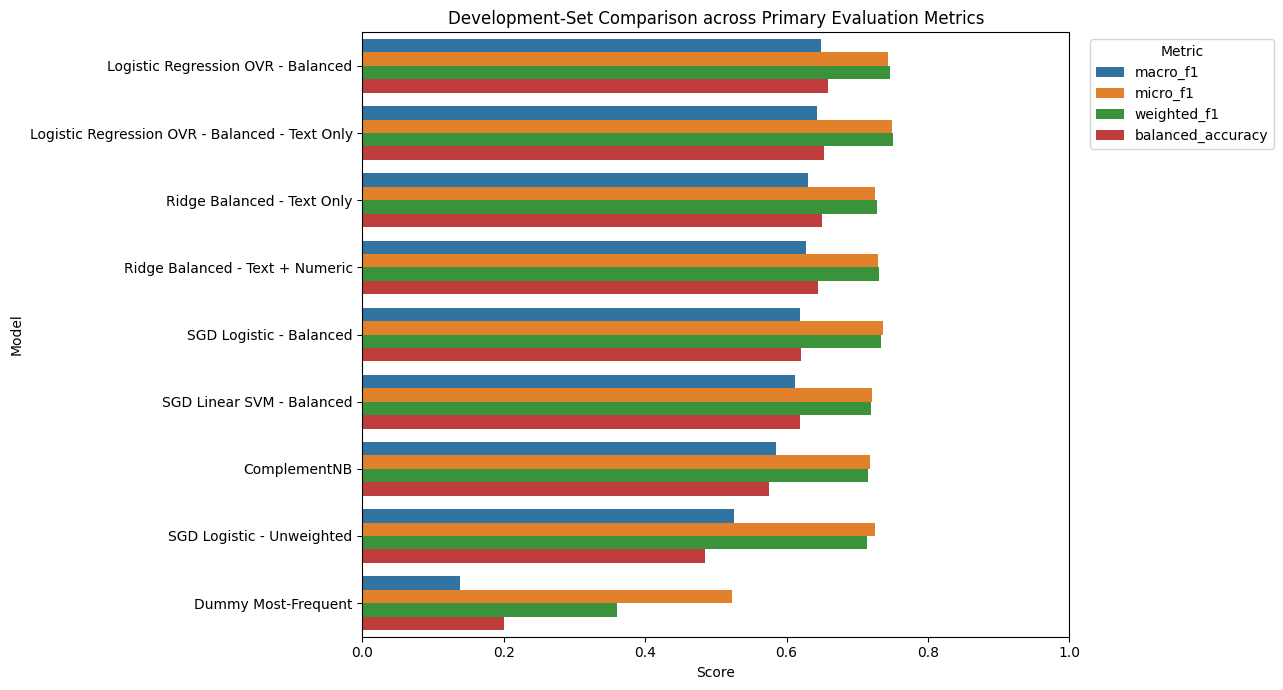

In [8]:
# Plot the main development metrics side by side so overall and imbalance-aware performance can be compared together
comparison_metrics = ['macro_f1', 'micro_f1', 'weighted_f1', 'balanced_accuracy']
comparison_long_df = dev_model_comparison_df[
    ['model'] + comparison_metrics
].melt(id_vars='model', var_name='metric', value_name='score')

display(
    dev_model_comparison_df[
        ['model', 'macro_f1', 'micro_f1', 'weighted_f1', 'balanced_accuracy']
    ].round(4)
)

plt.figure(figsize=(13, 7))
sns.barplot(data=comparison_long_df, y='model', x='score', hue='metric')
plt.xlim(0, 1)
plt.title('Development-Set Comparison across Primary Evaluation Metrics')
plt.xlabel('Score')
plt.ylabel('Model')
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

,model,macro_f1,micro_f1,minority_recall_mean
0,Logistic Regression OVR - Balanced,0.6482,0.7441,0.5432
1,Logistic Regression OVR - Balanced - Text Only,0.6437,0.7498,0.5169
2,Ridge Balanced - Text Only,0.6300,0.7258,0.5432
3,Ridge Balanced - Text + Numeric,0.6274,0.7295,0.5233
4,SGD Logistic - Balanced,0.6185,0.7361,0.5111
5,SGD Linear SVM - Balanced,0.6125,0.7206,0.5240
6,ComplementNB,0.5858,0.7178,0.3924
7,SGD Logistic - Unweighted,0.5253,0.7248,0.1923
8,Dummy Most-Frequent,0.1374,0.5235,0.0000


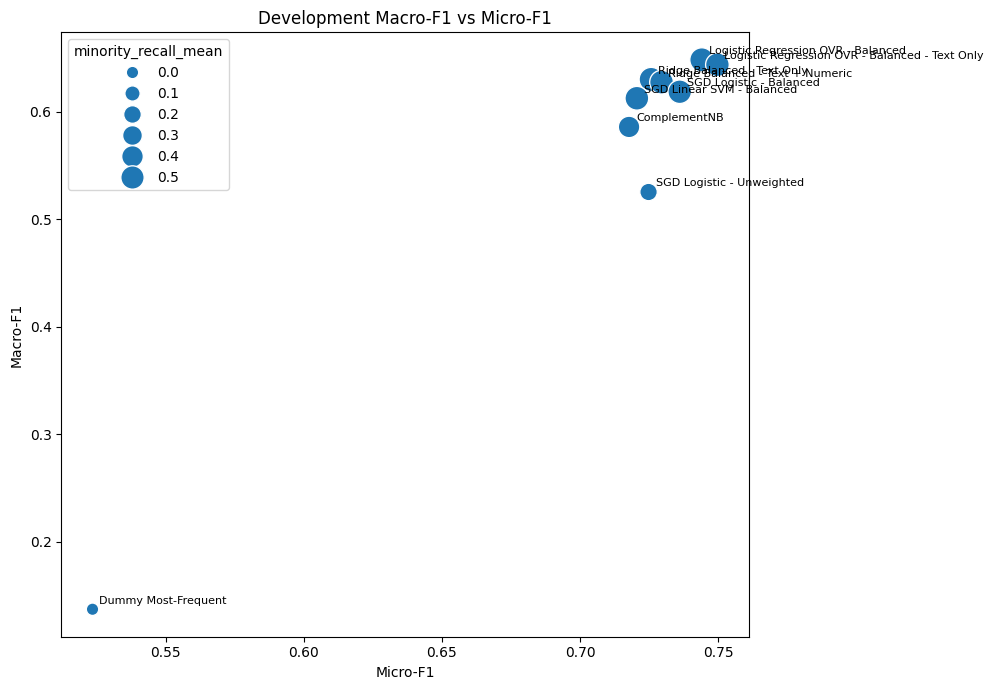

In [9]:
# Visualize the macro-F1 versus micro-F1 trade-off to expose models that succeed mainly on majority classes
display(
    dev_model_comparison_df[
        ['model', 'macro_f1', 'micro_f1', 'minority_recall_mean']
    ].round(4)
)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=dev_model_comparison_df,
    x='micro_f1',
    y='macro_f1',
    size='minority_recall_mean',
    sizes=(80, 300)
)
for _, row in dev_model_comparison_df.iterrows():
    plt.annotate(
        row['model'],
        (row['micro_f1'], row['macro_f1']),
        xytext=(5, 4),
        textcoords='offset points',
        fontsize=8
    )
plt.title('Development Macro-F1 vs Micro-F1')
plt.xlabel('Micro-F1')
plt.ylabel('Macro-F1')
plt.tight_layout()
plt.show()

class_label,Abusive,Political Hate,Profane,Religious Hate,Sexism
model,,,,,
Logistic Regression OVR - Balanced,0.7718,0.7247,0.7135,0.7179,0.3684
Logistic Regression OVR - Balanced - Text Only,0.7790,0.7282,0.7222,0.7179,0.3158
Ridge Balanced - Text Only,0.7484,0.6986,0.7193,0.7179,0.3684
Ridge Balanced - Text + Numeric,0.7520,0.7038,0.7222,0.7308,0.3158
SGD Logistic - Balanced,0.8455,0.6150,0.6228,0.6538,0.3684
SGD Linear SVM - Balanced,0.7844,0.7160,0.5497,0.6795,0.3684
ComplementNB,0.7673,0.7073,0.6170,0.6795,0.1053
SGD Logistic - Unweighted,0.8625,0.6411,0.5351,0.3846,0.0000
Dummy Most-Frequent,1.0000,0.0000,0.0000,0.0000,0.0000


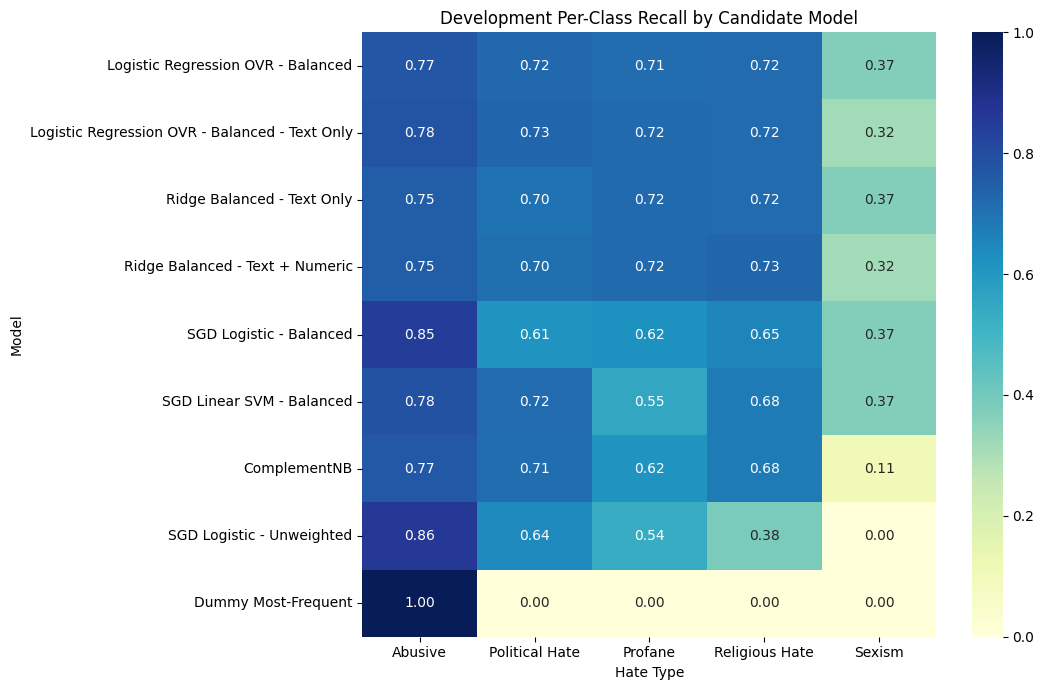

In [10]:
# Compare per-class development recall for every model to reveal minority-category behavior hidden by aggregate scores
per_model_recall_records = []
for model_name, y_pred in dev_predictions.items():
    recalls = recall_score(
        y_by_split['dev'], y_pred, labels=MODEL_CLASS_IDS, average=None, zero_division=0
    )
    for class_id, recall_value in zip(MODEL_CLASS_IDS, recalls):
        per_model_recall_records.append({
            'model': model_name,
            'class_label': id_to_label[class_id],
            'recall': recall_value
        })

dev_per_class_recall_df = pd.DataFrame(per_model_recall_records)
dev_recall_pivot = dev_per_class_recall_df.pivot(
    index='model', columns='class_label', values='recall'
).reindex(index=dev_model_comparison_df['model'])

display(dev_recall_pivot.round(4))

plt.figure(figsize=(11, 7))
sns.heatmap(dev_recall_pivot, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='YlGnBu')
plt.title('Development Per-Class Recall by Candidate Model')
plt.xlabel('Hate Type')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

In [11]:
# Quantify the effect of adding Phase 3 handcrafted numerical features with matched Ridge and Logistic classifiers
ablation_records = []
for model_family, text_name, numeric_name in [
    (
        'Ridge Balanced',
        'Ridge Balanced - Text Only',
        'Ridge Balanced - Text + Numeric'
    ),
    (
        'Logistic Regression OVR - Balanced',
        'Logistic Regression OVR - Balanced - Text Only',
        'Logistic Regression OVR - Balanced'
    )
]:
    text_row = dev_model_comparison_df.loc[
        dev_model_comparison_df['model'] == text_name
    ].iloc[0]
    numeric_row = dev_model_comparison_df.loc[
        dev_model_comparison_df['model'] == numeric_name
    ].iloc[0]

    for feature_variant, row in [('Text only', text_row), ('Text + handcrafted numeric', numeric_row)]:
        ablation_records.append({
            'model_family': model_family,
            'feature_variant': feature_variant,
            'macro_f1': row['macro_f1'],
            'micro_f1': row['micro_f1'],
            'balanced_accuracy': row['balanced_accuracy'],
            'minority_recall_mean': row['minority_recall_mean']
        })

feature_ablation_df = pd.DataFrame(ablation_records)
display(feature_ablation_df.round(4))

for model_family in feature_ablation_df['model_family'].unique():
    family_df = feature_ablation_df[feature_ablation_df['model_family'] == model_family].set_index('feature_variant')
    print(f'\n{model_family}: Text + numeric minus text-only change')
    for metric in ['macro_f1', 'micro_f1', 'balanced_accuracy', 'minority_recall_mean']:
        delta = (
            family_df.loc['Text + handcrafted numeric', metric]
            - family_df.loc['Text only', metric]
        )
        print(f'{metric:>22}: {delta:+.4f}')


,model_family,feature_variant,macro_f1,micro_f1,balanced_accuracy,minority_recall_mean
0,Ridge Balanced,Text only,0.6300,0.7258,0.6505,0.5432
1,Ridge Balanced,Text + handcrafted numeric,0.6274,0.7295,0.6449,0.5233
2,Logistic Regression OVR - Balanced,Text only,0.6437,0.7498,0.6526,0.5169
3,Logistic Regression OVR - Balanced,Text + handcrafted numeric,0.6482,0.7441,0.6593,0.5432



Ridge Balanced: Text + numeric minus text-only change
              macro_f1: -0.0026
              micro_f1: +0.0038
     balanced_accuracy: -0.0056
  minority_recall_mean: -0.0199

Logistic Regression OVR - Balanced: Text + numeric minus text-only change
              macro_f1: +0.0046
              micro_f1: -0.0056
     balanced_accuracy: +0.0066
  minority_recall_mean: +0.0263


# **18. Final Model Selection and Untouched Test Evaluation**

The final model is chosen **only from development-set evidence**. The ranking rule is:

1. Highest **macro-F1**.
2. If needed, higher **mean minority-class recall**.
3. If still tied, higher **micro-F1**.

This rule is aligned with the project objective because the dataset is highly imbalanced and minority hate categories are important. The test labels are not used in this ranking.

In [12]:
# Select the final classifier using development macro-F1 with minority recall and micro-F1 as deterministic tie-breakers
selection_table_df = dev_model_comparison_df.sort_values(
    by=['macro_f1', 'minority_recall_mean', 'micro_f1'],
    ascending=False
).reset_index(drop=True)

FINAL_MODEL_NAME = selection_table_df.loc[0, 'model']
FINAL_FEATURE_SET = candidate_models[FINAL_MODEL_NAME]['feature_set']
final_model = fitted_models[FINAL_MODEL_NAME]

runner_up_name = selection_table_df.loc[1, 'model'] if len(selection_table_df) > 1 else None
best_row = selection_table_df.iloc[0]

display(
    selection_table_df[
        ['model', 'feature_set', 'macro_f1', 'micro_f1', 'minority_recall_mean', 'balanced_accuracy']
    ].round(4)
)

print('Selected final model:', FINAL_MODEL_NAME)
print('Selected feature set:', FINAL_FEATURE_SET)
print(
    f"Development evidence -> macro-F1={best_row['macro_f1']:.4f}, "
    f"micro-F1={best_row['micro_f1']:.4f}, "
    f"minority recall={best_row['minority_recall_mean']:.4f}"
)

,model,feature_set,macro_f1,micro_f1,minority_recall_mean,balanced_accuracy
0,Logistic Regression OVR - Balanced,text_numeric,0.6482,0.7441,0.5432,0.6593
1,Logistic Regression OVR - Balanced - Text Only,text_only,0.6437,0.7498,0.5169,0.6526
2,Ridge Balanced - Text Only,text_only,0.6300,0.7258,0.5432,0.6505
3,Ridge Balanced - Text + Numeric,text_numeric,0.6274,0.7295,0.5233,0.6449
4,SGD Logistic - Balanced,text_numeric,0.6185,0.7361,0.5111,0.6211
5,SGD Linear SVM - Balanced,text_numeric,0.6125,0.7206,0.5240,0.6196
6,ComplementNB,text_only,0.5858,0.7178,0.3924,0.5753
7,SGD Logistic - Unweighted,text_numeric,0.5253,0.7248,0.1923,0.4847
8,Dummy Most-Frequent,text_only,0.1374,0.5235,0.0000,0.2000


Selected final model: Logistic Regression OVR - Balanced
Selected feature set: text_numeric
Development evidence -> macro-F1=0.6482, micro-F1=0.7441, minority recall=0.5432


In [13]:
# Generate an evidence-based written justification for the final model using the development comparison only
justification_parts = [
    f"**Final model selection:** {FINAL_MODEL_NAME} was selected because it achieved the strongest "
    f"development macro-F1 ({best_row['macro_f1']:.4f}), which is the primary metric for this imbalanced "
    f"multi-class problem. Its development micro-F1 was {best_row['micro_f1']:.4f}, balanced accuracy was "
    f"{best_row['balanced_accuracy']:.4f}, and mean recall across the identified minority classes "
    f"({', '.join(MINORITY_CLASS_LABELS)}) was {best_row['minority_recall_mean']:.4f}."
]
if runner_up_name is not None:
    runner_row = selection_table_df.iloc[1]
    justification_parts.append(
        f"The closest runner-up was {runner_up_name} with macro-F1={runner_row['macro_f1']:.4f}. "
        f"The final choice therefore follows the predefined development-set ranking rule rather than test performance."
    )
justification_parts.append(
    "The selected model also remains appropriate for the project because it operates efficiently on the sparse "
    "TF-IDF plus handcrafted feature representation and supports transparent post-hoc inspection. "
    "The test split is evaluated only after this decision, preserving an unbiased final assessment."
)

display(Markdown(' '.join(justification_parts)))

**Final model selection:** Logistic Regression OVR - Balanced was selected because it achieved the strongest development macro-F1 (0.6482), which is the primary metric for this imbalanced multi-class problem. Its development micro-F1 was 0.7441, balanced accuracy was 0.6593, and mean recall across the identified minority classes (Sexism, Religious Hate) was 0.5432. The closest runner-up was Logistic Regression OVR - Balanced - Text Only with macro-F1=0.6437. The final choice therefore follows the predefined development-set ranking rule rather than test performance. The selected model also remains appropriate for the project because it operates efficiently on the sparse TF-IDF plus handcrafted feature representation and supports transparent post-hoc inspection. The test split is evaluated only after this decision, preserving an unbiased final assessment.

In [14]:
# Evaluate the already selected training-fitted final model once on the untouched test split
X_test_final = feature_matrices['test'][FINAL_FEATURE_SET]
y_test = y_by_split['test']

test_start = time.perf_counter()
final_test_metrics, final_test_pred, final_test_scores = evaluate_multiclass_model(
    final_model, X_test_final, y_test, MODEL_CLASS_IDS, MINORITY_CLASS_IDS
)
test_inference_seconds = time.perf_counter() - test_start

final_test_metrics_df = pd.DataFrame([{
    'model': FINAL_MODEL_NAME,
    'feature_set': FINAL_FEATURE_SET,
    **final_test_metrics,
    'test_inference_seconds': test_inference_seconds
}])

display(final_test_metrics_df.round(4))

,model,feature_set,accuracy,balanced_accuracy,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,mcc,cohen_kappa,minority_recall_mean,roc_auc_macro_ovr,average_precision_macro,average_precision_micro,test_inference_seconds
0,Logistic Regression OVR - Balanced,text_numeric,0.7332,0.6056,0.7332,0.7332,0.7332,0.589,0.6056,0.591,0.7381,0.7332,0.734,0.5793,0.5786,0.4316,0.8967,0.6195,0.7737,0.1422


In [15]:
# Build the detailed final test classification report with precision, recall, F1, and support for every observed class
final_report_dict = classification_report(
    y_test,
    final_test_pred,
    labels=MODEL_CLASS_IDS,
    target_names=MODEL_CLASS_LABELS,
    output_dict=True,
    zero_division=0
)

final_per_class_df = pd.DataFrame(final_report_dict).T.loc[
    MODEL_CLASS_LABELS,
    ['precision', 'recall', 'f1-score', 'support']
]
final_per_class_df['support'] = final_per_class_df['support'].astype(int)

display(final_per_class_df.round(4))

,precision,recall,f1-score,support
Abusive,0.7892,0.7612,0.7750,2312
Sexism,0.1765,0.1034,0.1304,29
Religious Hate,0.5440,0.7598,0.6340,179
Political Hate,0.6631,0.7197,0.6903,1220
Profane,0.7723,0.6841,0.7255,709


# **19. Final Model Diagnostic Visualizations**

,Abusive,Sexism,Religious Hate,Political Hate,Profane
Abusive,1760,12,77,358,105
Sexism,24,3,0,1,1
Religious Hate,28,0,136,10,5
Political Hate,285,1,24,878,32
Profane,133,1,13,77,485


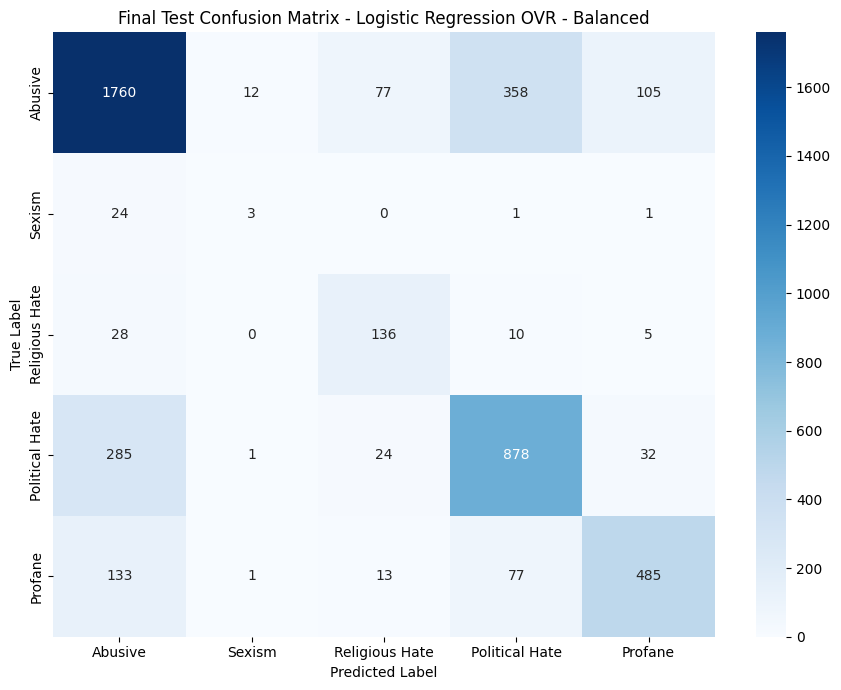

In [16]:
# Display and plot the raw final-test confusion matrix to show the exact number of correct and incorrect predictions
final_cm = confusion_matrix(y_test, final_test_pred, labels=MODEL_CLASS_IDS)
final_cm_df = pd.DataFrame(final_cm, index=MODEL_CLASS_LABELS, columns=MODEL_CLASS_LABELS)
display(final_cm_df)

plt.figure(figsize=(9, 7))
sns.heatmap(final_cm_df, annot=True, fmt='d', cmap='Blues')
plt.title(f'Final Test Confusion Matrix - {FINAL_MODEL_NAME}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

,Abusive,Sexism,Religious Hate,Political Hate,Profane
Abusive,0.7612,0.0052,0.0333,0.1548,0.0454
Sexism,0.8276,0.1034,0.0000,0.0345,0.0345
Religious Hate,0.1564,0.0000,0.7598,0.0559,0.0279
Political Hate,0.2336,0.0008,0.0197,0.7197,0.0262
Profane,0.1876,0.0014,0.0183,0.1086,0.6841


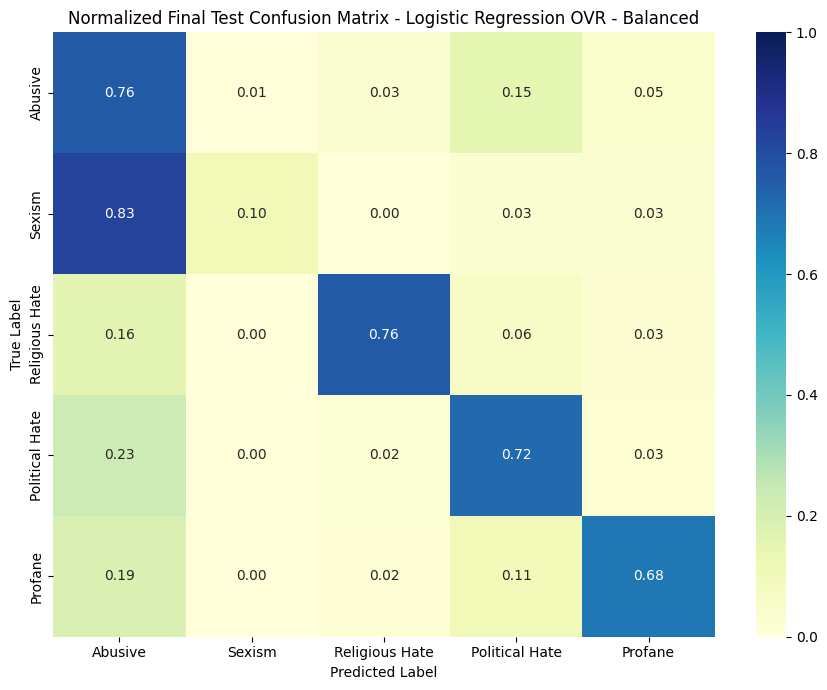

In [17]:
# Normalize the final-test confusion matrix by true class to compare error rates fairly across imbalanced categories
row_totals = final_cm.sum(axis=1, keepdims=True)
final_cm_normalized = np.divide(
    final_cm,
    row_totals,
    out=np.zeros_like(final_cm, dtype=float),
    where=row_totals != 0
)
final_cm_normalized_df = pd.DataFrame(
    final_cm_normalized,
    index=MODEL_CLASS_LABELS,
    columns=MODEL_CLASS_LABELS
)

display(final_cm_normalized_df.round(4))

plt.figure(figsize=(9, 7))
sns.heatmap(final_cm_normalized_df, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='YlGnBu')
plt.title(f'Normalized Final Test Confusion Matrix - {FINAL_MODEL_NAME}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

,precision,recall,f1-score,support
Abusive,0.7892,0.7612,0.7750,2312
Sexism,0.1765,0.1034,0.1304,29
Religious Hate,0.5440,0.7598,0.6340,179
Political Hate,0.6631,0.7197,0.6903,1220
Profane,0.7723,0.6841,0.7255,709


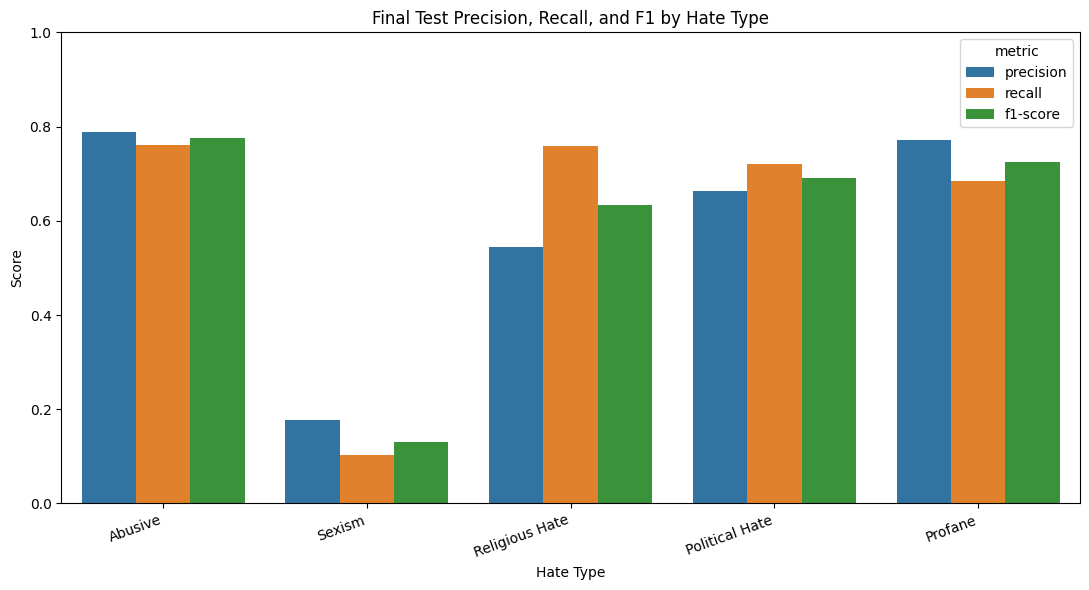

In [18]:
# Plot final per-class precision, recall, and F1 so minority-class performance remains visible
per_class_plot_df = (
    final_per_class_df[['precision', 'recall', 'f1-score']]
    .reset_index()
    .rename(columns={'index': 'class_label'})
    .melt(id_vars='class_label', var_name='metric', value_name='score')
)

display(final_per_class_df.round(4))

plt.figure(figsize=(11, 6))
sns.barplot(data=per_class_plot_df, x='class_label', y='score', hue='metric')
plt.ylim(0, 1)
plt.title('Final Test Precision, Recall, and F1 by Hate Type')
plt.xlabel('Hate Type')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

,split,macro_f1,micro_f1,weighted_f1,balanced_accuracy,minority_recall_mean
0,Development,0.6482,0.7441,0.746,0.6593,0.5432
1,Test,0.5910,0.7332,0.734,0.6056,0.4316


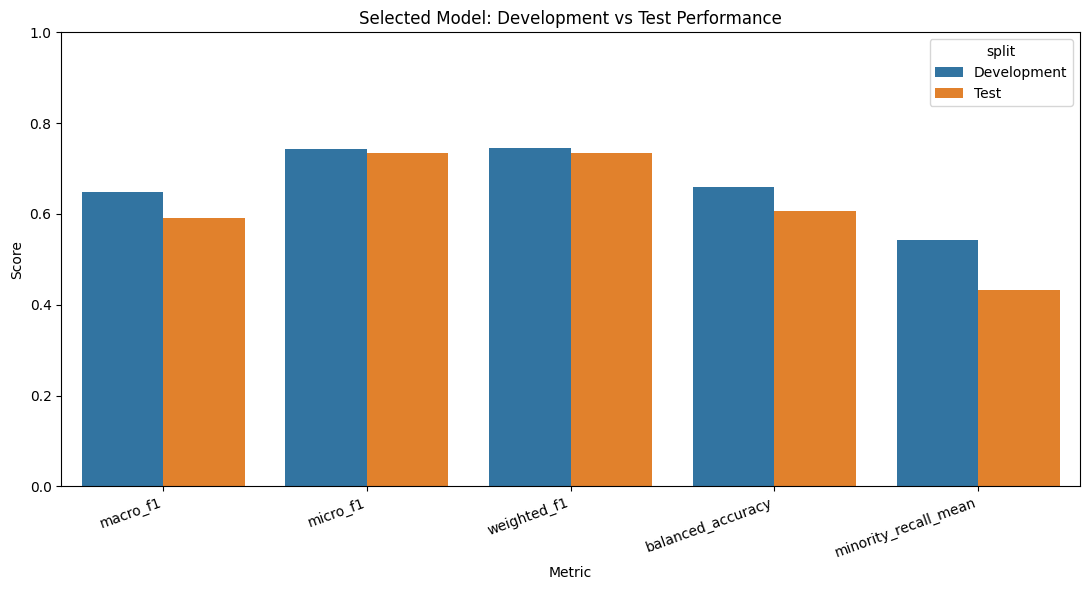

In [19]:
# Compare development and test aggregate metrics to assess generalization after final model selection
selected_dev_row = dev_model_comparison_df.loc[
    dev_model_comparison_df['model'] == FINAL_MODEL_NAME
].iloc[0]

dev_test_metric_df = pd.DataFrame([
    {
        'split': 'Development',
        'macro_f1': selected_dev_row['macro_f1'],
        'micro_f1': selected_dev_row['micro_f1'],
        'weighted_f1': selected_dev_row['weighted_f1'],
        'balanced_accuracy': selected_dev_row['balanced_accuracy'],
        'minority_recall_mean': selected_dev_row['minority_recall_mean']
    },
    {
        'split': 'Test',
        'macro_f1': final_test_metrics['macro_f1'],
        'micro_f1': final_test_metrics['micro_f1'],
        'weighted_f1': final_test_metrics['weighted_f1'],
        'balanced_accuracy': final_test_metrics['balanced_accuracy'],
        'minority_recall_mean': final_test_metrics['minority_recall_mean']
    }
])

display(dev_test_metric_df.round(4))

dev_test_long_df = dev_test_metric_df.melt(id_vars='split', var_name='metric', value_name='score')

plt.figure(figsize=(11, 6))
sns.barplot(data=dev_test_long_df, x='metric', y='score', hue='split')
plt.ylim(0, 1)
plt.title('Selected Model: Development vs Test Performance')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

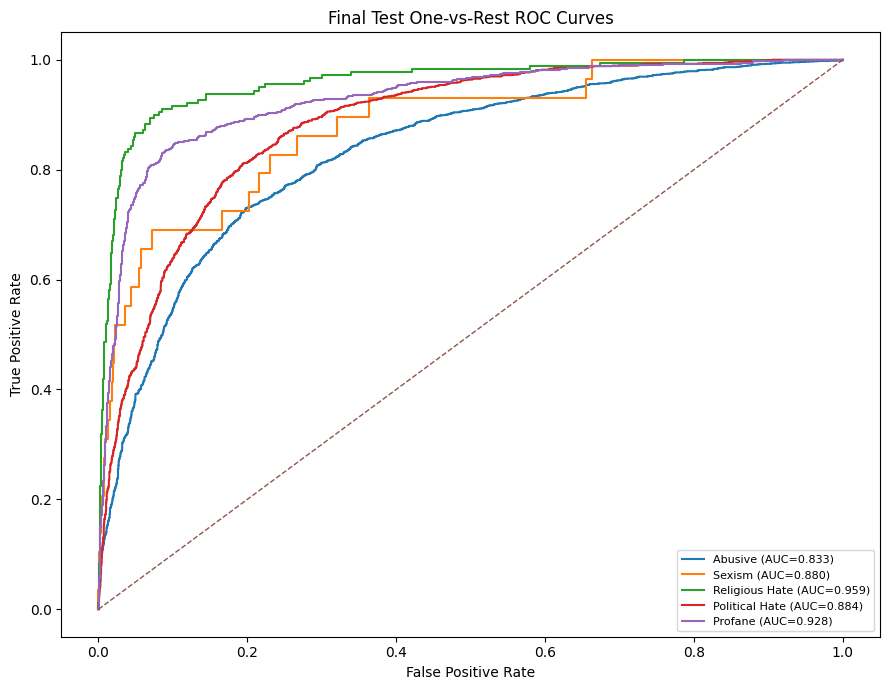

,class_label,roc_auc
2,Religious Hate,0.9591
4,Profane,0.9277
3,Political Hate,0.8838
1,Sexism,0.8796
0,Abusive,0.8333


In [20]:
# Plot one-vs-rest ROC curves and report per-class ROC-AUC when the final model exposes usable decision scores
if final_test_scores is not None:
    y_test_binary = label_binarize(y_test, classes=MODEL_CLASS_IDS)
    roc_records = []

    plt.figure(figsize=(9, 7))
    for class_index, class_label in enumerate(MODEL_CLASS_LABELS):
        fpr, tpr, _ = roc_curve(y_test_binary[:, class_index], final_test_scores[:, class_index])
        class_auc = auc(fpr, tpr)
        roc_records.append({'class_label': class_label, 'roc_auc': class_auc})
        plt.plot(fpr, tpr, label=f'{class_label} (AUC={class_auc:.3f})')

    plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
    plt.title('Final Test One-vs-Rest ROC Curves')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    final_roc_auc_df = pd.DataFrame(roc_records).sort_values('roc_auc', ascending=False)
    display(final_roc_auc_df.round(4))
else:
    final_roc_auc_df = pd.DataFrame()
    print('ROC curves skipped because the selected model does not expose probability or decision scores.')

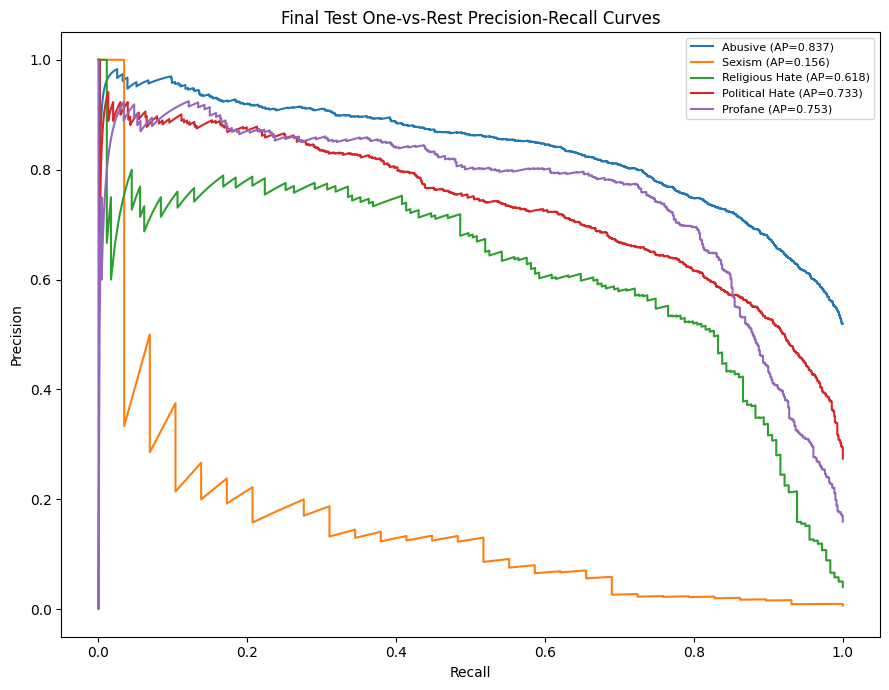

,class_label,average_precision
0,Abusive,0.8371
4,Profane,0.7531
3,Political Hate,0.7332
2,Religious Hate,0.6181
1,Sexism,0.1562


In [21]:
# Plot one-vs-rest precision-recall curves and report average precision for each hate category
if final_test_scores is not None:
    y_test_binary = label_binarize(y_test, classes=MODEL_CLASS_IDS)
    pr_records = []

    plt.figure(figsize=(9, 7))
    for class_index, class_label in enumerate(MODEL_CLASS_LABELS):
        precision_values, recall_values, _ = precision_recall_curve(
            y_test_binary[:, class_index],
            final_test_scores[:, class_index]
        )
        class_ap = average_precision_score(
            y_test_binary[:, class_index],
            final_test_scores[:, class_index]
        )
        pr_records.append({'class_label': class_label, 'average_precision': class_ap})
        plt.plot(recall_values, precision_values, label=f'{class_label} (AP={class_ap:.3f})')

    plt.title('Final Test One-vs-Rest Precision-Recall Curves')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    final_average_precision_df = pd.DataFrame(pr_records).sort_values('average_precision', ascending=False)
    display(final_average_precision_df.round(4))
else:
    final_average_precision_df = pd.DataFrame()
    print('Precision-recall curves skipped because the selected model does not expose probability or decision scores.')

,class_label,test_support,recall
0,Abusive,2312,0.7612
1,Sexism,29,0.1034
2,Religious Hate,179,0.7598
3,Political Hate,1220,0.7197
4,Profane,709,0.6841


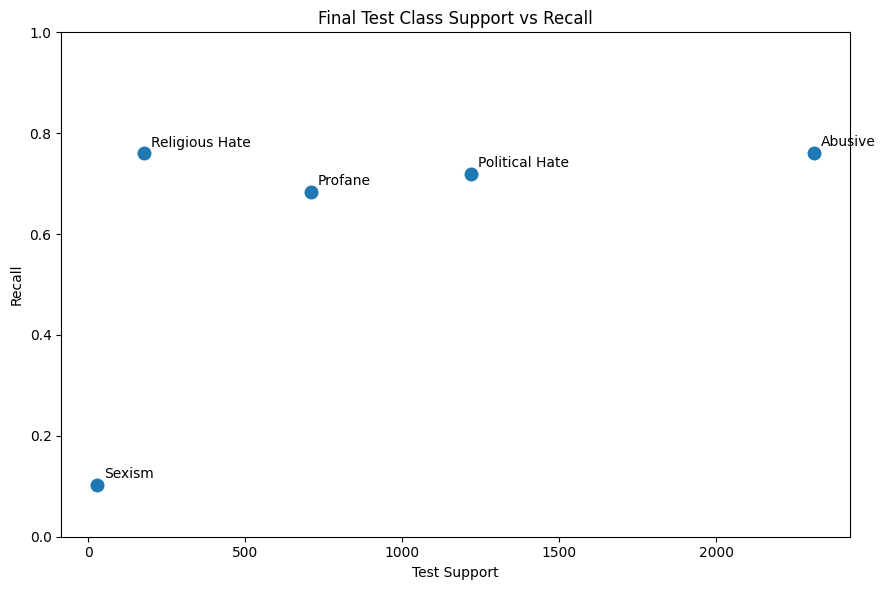

In [22]:
# Relate class support to final recall to make the effect of severe class imbalance visually explicit
support_recall_df = class_support_df[['class_label', 'test_support']].merge(
    final_per_class_df[['recall']].reset_index().rename(columns={'index': 'class_label'}),
    on='class_label',
    how='left'
)

display(support_recall_df.round(4))

plt.figure(figsize=(9, 6))
sns.scatterplot(data=support_recall_df, x='test_support', y='recall', s=120)
for _, row in support_recall_df.iterrows():
    plt.annotate(
        row['class_label'],
        (row['test_support'], row['recall']),
        xytext=(5, 5),
        textcoords='offset points'
    )
plt.ylim(0, 1)
plt.title('Final Test Class Support vs Recall')
plt.xlabel('Test Support')
plt.ylabel('Recall')
plt.tight_layout()
plt.show()

# **20. Error Analysis**

,true_label,predicted_label,error_count
0,Abusive,Political Hate,358
4,Political Hate,Abusive,285
8,Profane,Abusive,133
1,Abusive,Profane,105
9,Profane,Political Hate,77
2,Abusive,Religious Hate,77
5,Political Hate,Profane,32
12,Religious Hate,Abusive,28
15,Sexism,Abusive,24
6,Political Hate,Religious Hate,24


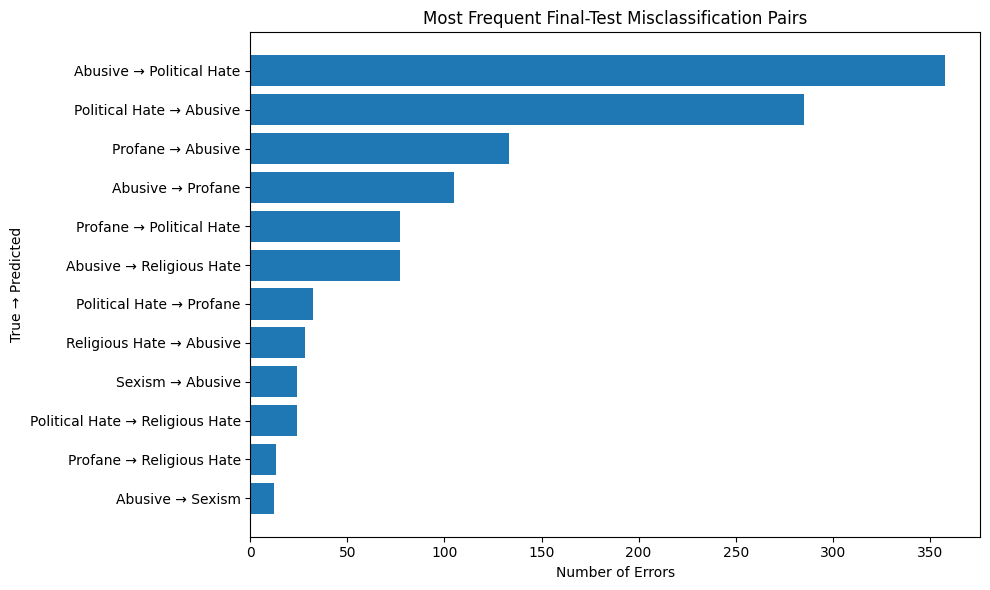

In [23]:
# Summarize the most frequent final-model confusion pairs and visualize the dominant error pathways
error_mask = y_test != final_test_pred
error_pairs_df = pd.DataFrame({
    'true_id': y_test[error_mask],
    'pred_id': final_test_pred[error_mask]
})
error_pairs_df['true_label'] = error_pairs_df['true_id'].map(id_to_label)
error_pairs_df['predicted_label'] = error_pairs_df['pred_id'].map(id_to_label)

top_confusion_pairs_df = (
    error_pairs_df
    .groupby(['true_label', 'predicted_label'])
    .size()
    .reset_index(name='error_count')
    .sort_values('error_count', ascending=False)
    .head(12)
)
top_confusion_pairs_df['confusion_pair'] = (
    top_confusion_pairs_df['true_label'] + ' → ' + top_confusion_pairs_df['predicted_label']
)

display(top_confusion_pairs_df[['true_label', 'predicted_label', 'error_count']])

plt.figure(figsize=(10, 6))
plt.barh(top_confusion_pairs_df['confusion_pair'][::-1], top_confusion_pairs_df['error_count'][::-1])
plt.title('Most Frequent Final-Test Misclassification Pairs')
plt.xlabel('Number of Errors')
plt.ylabel('True → Predicted')
plt.tight_layout()
plt.show()

In [24]:
# Build a privacy-conscious prediction audit table with labels, correctness, and confidence when available
test_prediction_audit_df = pd.DataFrame({
    'row_id': cleaned_splits['test']['id'].astype(str).to_numpy(),
    'true_id': y_test,
    'predicted_id': final_test_pred
})
test_prediction_audit_df['true_label'] = test_prediction_audit_df['true_id'].map(id_to_label)
test_prediction_audit_df['predicted_label'] = test_prediction_audit_df['predicted_id'].map(id_to_label)
test_prediction_audit_df['correct'] = test_prediction_audit_df['true_id'].eq(test_prediction_audit_df['predicted_id'])

if final_test_scores is not None:
    if hasattr(final_model, 'predict_proba'):
        confidence_matrix = np.asarray(final_model.predict_proba(X_test_final))
        test_prediction_audit_df['prediction_confidence'] = confidence_matrix.max(axis=1)
    else:
        sorted_scores = np.sort(final_test_scores, axis=1)
        test_prediction_audit_df['decision_margin'] = sorted_scores[:, -1] - sorted_scores[:, -2]

display(test_prediction_audit_df.head(10))
print(
    f"Correct predictions: {test_prediction_audit_df['correct'].sum():,} / "
    f"{len(test_prediction_audit_df):,}"
)

,row_id,true_id,predicted_id,true_label,predicted_label,correct,prediction_confidence
0,12764,1,1,Abusive,Abusive,True,0.696219
1,124999,5,5,Profane,Profane,True,0.479759
2,535301,3,3,Religious Hate,Religious Hate,True,0.585060
3,432948,1,5,Abusive,Profane,False,0.784687
4,377091,5,5,Profane,Profane,True,0.590078
5,578332,4,4,Political Hate,Political Hate,True,0.611993
6,723077,1,1,Abusive,Abusive,True,0.510081
7,776755,3,3,Religious Hate,Religious Hate,True,0.626430
8,587800,5,5,Profane,Profane,True,0.962616
9,620490,4,4,Political Hate,Political Hate,True,0.717792


Correct predictions: 3,262 / 4,449


,correct,count,mean,median,std
0,False,1187,0.5393,0.5220,0.1230
1,True,3262,0.6242,0.6211,0.1356


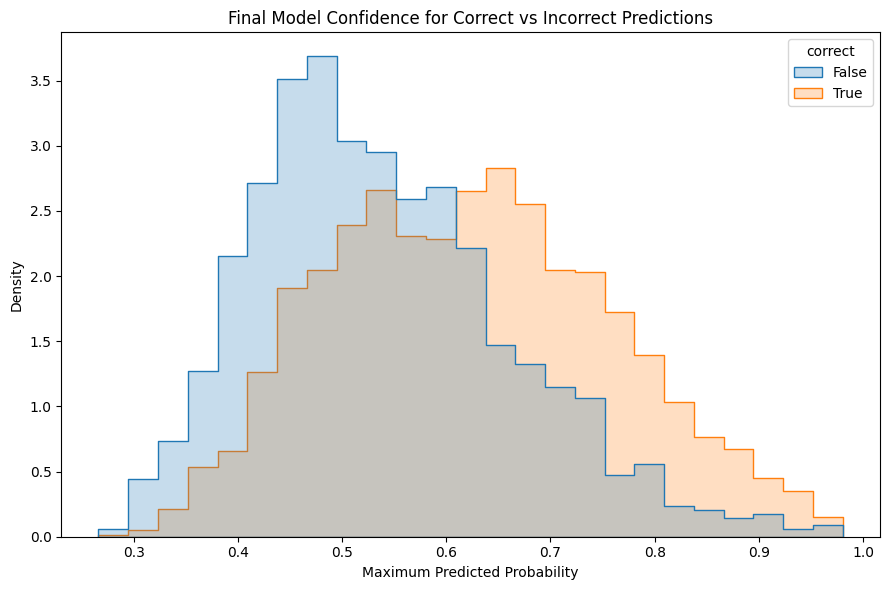

In [25]:
# Compare confidence for correct and incorrect predictions when class probabilities are available
if 'prediction_confidence' in test_prediction_audit_df.columns:
    confidence_summary_df = (
        test_prediction_audit_df
        .groupby('correct')['prediction_confidence']
        .agg(['count', 'mean', 'median', 'std'])
        .reset_index()
    )
    display(confidence_summary_df.round(4))

    plt.figure(figsize=(9, 6))
    sns.histplot(
        data=test_prediction_audit_df,
        x='prediction_confidence',
        hue='correct',
        bins=25,
        stat='density',
        common_norm=False,
        element='step'
    )
    plt.title('Final Model Confidence for Correct vs Incorrect Predictions')
    plt.xlabel('Maximum Predicted Probability')
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()
else:
    print('Probability-confidence plot skipped because the selected model does not expose predict_proba().')

# **21. Final Model Transparency Check**

In [26]:
# Inspect the largest final-model linear coefficients when the Phase 3 feature names are available in memory
coefficient_summary_df = pd.DataFrame()

feature_name_parts = []
if 'word_tfidf' in globals():
    feature_name_parts.append(
        np.array([f'word::{name}' for name in word_tfidf.get_feature_names_out()], dtype=object)
    )
if 'char_tfidf' in globals():
    feature_name_parts.append(
        np.array([f'char::{name}' for name in char_tfidf.get_feature_names_out()], dtype=object)
    )
if 'FINAL_NUMERIC_FEATURES' in globals():
    feature_name_parts.append(
        np.array([f'numeric::{name}' for name in FINAL_NUMERIC_FEATURES], dtype=object)
    )

if feature_name_parts:
    final_feature_names = np.concatenate(feature_name_parts)
    estimator_list = getattr(final_model, 'estimators_', None)

    if estimator_list is not None and len(estimator_list) == len(MODEL_CLASS_IDS):
        coefficient_records = []
        for class_id, binary_estimator in zip(MODEL_CLASS_IDS, estimator_list):
            if hasattr(binary_estimator, 'coef_'):
                coefficients = np.asarray(binary_estimator.coef_).ravel()
                if len(coefficients) == len(final_feature_names):
                    top_indices = np.argsort(coefficients)[-12:][::-1]
                    for rank, feature_index in enumerate(top_indices, start=1):
                        coefficient_records.append({
                            'class_label': id_to_label[class_id],
                            'rank': rank,
                            'feature': final_feature_names[feature_index],
                            'coefficient': coefficients[feature_index]
                        })
        coefficient_summary_df = pd.DataFrame(coefficient_records)

if not coefficient_summary_df.empty:
    display(coefficient_summary_df.head(60))
    print(
        'These coefficients are a model-transparency sanity check only; '
        'SHAP/LIME explanation should be performed separately in the dedicated explainability stage.'
    )
else:
    print(
        'Coefficient-name inspection is available when the full notebook is run top to bottom '
        'with the Phase 3 vectorizers and numeric feature names in memory.'
    )

Coefficient-name inspection is available when the full notebook is run top to bottom with the Phase 3 vectorizers and numeric feature names in memory.


# **22. Export Phase 4 Results and Reproducibility Validation**

In [27]:
# Save the selected model, comparison tables, final metrics, per-class results, and prediction audit for later phases
joblib.dump(final_model, PHASE4_MODEL_DIR / 'final_model.joblib')

dev_model_comparison_df.to_csv(
    PHASE4_REPORT_DIR / 'development_model_comparison.csv', index=False, encoding='utf-8-sig'
)
dev_per_class_recall_df.to_csv(
    PHASE4_REPORT_DIR / 'development_per_class_recall.csv', index=False, encoding='utf-8-sig'
)
final_test_metrics_df.to_csv(
    PHASE4_REPORT_DIR / 'final_test_metrics.csv', index=False, encoding='utf-8-sig'
)
final_per_class_df.to_csv(
    PHASE4_REPORT_DIR / 'final_test_per_class_metrics.csv', encoding='utf-8-sig'
)
final_cm_df.to_csv(
    PHASE4_REPORT_DIR / 'final_test_confusion_matrix.csv', encoding='utf-8-sig'
)
final_cm_normalized_df.to_csv(
    PHASE4_REPORT_DIR / 'final_test_confusion_matrix_normalized.csv', encoding='utf-8-sig'
)
top_confusion_pairs_df.to_csv(
    PHASE4_REPORT_DIR / 'top_test_confusion_pairs.csv', index=False, encoding='utf-8-sig'
)
test_prediction_audit_df.to_csv(
    PHASE4_REPORT_DIR / 'test_prediction_audit.csv', index=False, encoding='utf-8-sig'
)

if not final_roc_auc_df.empty:
    final_roc_auc_df.to_csv(
        PHASE4_REPORT_DIR / 'final_test_per_class_roc_auc.csv', index=False, encoding='utf-8-sig'
    )
if not final_average_precision_df.empty:
    final_average_precision_df.to_csv(
        PHASE4_REPORT_DIR / 'final_test_per_class_average_precision.csv', index=False, encoding='utf-8-sig'
    )

print('Phase 4 model and evaluation artifacts saved successfully.')

Phase 4 model and evaluation artifacts saved successfully.


In [28]:
# Create a machine-readable Phase 4 manifest documenting the selection rule, chosen model, features, and final metrics
phase4_manifest = {
    'project_title': globals().get(
        'PROJECT_TITLE',
        'Explainable and Imbalance-Aware Fine-Grained Bangla Hate Speech Type Classification Using Machine Learning'
    ),
    'random_seed': int(SEED),
    'task_type': 'imbalanced multi-class text classification',
    'selection_split': 'development',
    'primary_selection_metric': 'macro_f1',
    'selection_tie_breakers': ['minority_recall_mean', 'micro_f1'],
    'test_used_for_model_selection': False,
    'candidate_model_count': int(len(candidate_models)),
    'candidate_models': list(candidate_models.keys()),
    'observed_class_ids': [int(class_id) for class_id in MODEL_CLASS_IDS],
    'observed_class_labels': MODEL_CLASS_LABELS,
    'minority_class_labels': MINORITY_CLASS_LABELS,
    'selected_model': FINAL_MODEL_NAME,
    'selected_feature_set': FINAL_FEATURE_SET,
    'development_metrics': {
        key: float(best_row[key])
        for key in [
            'accuracy', 'balanced_accuracy', 'micro_f1', 'macro_f1',
            'weighted_f1', 'macro_precision', 'macro_recall',
            'minority_recall_mean', 'mcc', 'cohen_kappa'
        ]
    },
    'test_metrics': {
        key: float(value) if pd.notna(value) else None
        for key, value in final_test_metrics.items()
    }
}

with open(PHASE4_OUTPUT_DIR / 'phase4_manifest.json', 'w', encoding='utf-8') as file:
    json.dump(phase4_manifest, file, ensure_ascii=False, indent=2)

display(pd.DataFrame([{
    'selected_model': FINAL_MODEL_NAME,
    'feature_set': FINAL_FEATURE_SET,
    'dev_macro_f1': best_row['macro_f1'],
    'test_macro_f1': final_test_metrics['macro_f1'],
    'test_micro_f1': final_test_metrics['micro_f1'],
    'test_balanced_accuracy': final_test_metrics['balanced_accuracy'],
    'test_minority_recall': final_test_metrics['minority_recall_mean']
}]).round(4))

,selected_model,feature_set,dev_macro_f1,test_macro_f1,test_micro_f1,test_balanced_accuracy,test_minority_recall
0,Logistic Regression OVR - Balanced,text_numeric,0.6482,0.591,0.7332,0.6056,0.4316


In [29]:
# Run final Phase 4 assertions to verify fair selection, prediction alignment, metric validity, and artifact creation
assert FINAL_MODEL_NAME in fitted_models
assert FINAL_FEATURE_SET in feature_matrices['test']
assert len(final_test_pred) == len(y_test)
assert len(test_prediction_audit_df) == len(y_test)
assert set(np.unique(final_test_pred)).issubset(set(MODEL_CLASS_IDS))
assert 0.0 <= final_test_metrics['macro_f1'] <= 1.0
assert 0.0 <= final_test_metrics['micro_f1'] <= 1.0
assert 0.0 <= final_test_metrics['balanced_accuracy'] <= 1.0
assert selection_table_df.iloc[0]['model'] == FINAL_MODEL_NAME
assert (PHASE4_MODEL_DIR / 'final_model.joblib').exists()
assert (PHASE4_REPORT_DIR / 'development_model_comparison.csv').exists()
assert (PHASE4_REPORT_DIR / 'final_test_metrics.csv').exists()
assert (PHASE4_OUTPUT_DIR / 'phase4_manifest.json').exists()

phase4_checklist_df = pd.DataFrame([
    ('Baseline model included', True, 'Dummy most-frequent baseline establishes the minimum benchmark.'),
    ('Appropriate classification models compared', True, 'NB, Ridge, SGD logistic, SGD linear SVM, and OVR logistic regression are evaluated with matched feature ablations.'),
    ('Official data partition respected', True, 'Train fits models, dev selects the model, and test is used only after selection.'),
    ('Imbalance-aware evaluation used', True, 'Macro-F1, balanced accuracy, minority recall, and per-class metrics are reported.'),
    ('Multiple complementary metrics used', True, 'Micro/weighted F1, precision, recall, MCC, kappa, ROC-AUC, and average precision are included.'),
    ('Final model selection justified', True, 'Selection follows a predefined dev macro-F1 rule with explicit tie-breakers.'),
    ('Comparison tables included', True, 'Aggregate model comparison, class recall, ablation, per-class test metrics, and errors are tabulated.'),
    ('Diagnostic plots included', True, 'Metric comparison, recall heatmap, confusion matrices, ROC/PR curves, class metrics, and error plots are included.'),
    ('Artifacts exported', True, 'Final model, predictions, metrics, confusion matrices, and manifest are saved.'),
    ('Notebook remains reproducible', True, 'Fixed seed, train-only fitting, reusable Phase 3 matrices, deterministic selection, and final assertions are used.')
], columns=['criterion', 'satisfied', 'evidence'])

display(phase4_checklist_df)
assert phase4_checklist_df['satisfied'].all()
print('All Phase 4 validation checks passed.')

,criterion,satisfied,evidence
0,Baseline model included,True,Dummy most-frequent baseline establishes the m...
1,Appropriate classification models compared,True,"NB, Ridge, SGD logistic, SGD linear SVM, and O..."
2,Official data partition respected,True,"Train fits models, dev selects the model, and ..."
3,Imbalance-aware evaluation used,True,"Macro-F1, balanced accuracy, minority recall, ..."
4,Multiple complementary metrics used,True,"Micro/weighted F1, precision, recall, MCC, kap..."
5,Final model selection justified,True,Selection follows a predefined dev macro-F1 ru...
6,Comparison tables included,True,"Aggregate model comparison, class recall, abla..."
7,Diagnostic plots included,True,"Metric comparison, recall heatmap, confusion m..."
8,Artifacts exported,True,"Final model, predictions, metrics, confusion m..."
9,Notebook remains reproducible,True,"Fixed seed, train-only fitting, reusable Phase..."


All Phase 4 validation checks passed.
